### Cell 1 — setup + load the validated tract-year panel for the new cluster-time workflow


In [171]:
# Cell 1 — setup + load the validated tract-year panel for the new cluster-time workflow

from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# -----------------------------
# Paths / core settings
# -----------------------------
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "processed"

LOW_IGS_THRESHOLD = 45
ANALYSIS_YEARS = list(range(2017, 2025))   # ACS-aligned years only
PRE_COVID_YEARS = [2017, 2018, 2019]
COVID_YEARS = [2020, 2021]
RECOVERY_YEARS = [2022, 2023, 2024]

ECON_VARS = [
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

CLUSTER_CORE_VARS = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

DISPLAY_COLS = [
    "display_state",
    "display_county",
    "display_name",
]

REQUIRED_COLS = [
    "geoid",
    "year",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

PANEL_CANDIDATES = [
    OUT_DIR / "eda_panel_clean.parquet",
    OUT_DIR / "igs_x_acs_full.parquet",
]

def normalize_geoid_series(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_mask = numeric.notna()
    s = s.copy()
    s.loc[numeric_mask] = numeric.loc[numeric_mask].astype("Int64").astype("string")
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)
    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)

def add_display_fields(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "display_state" not in out.columns:
        if "State" in out.columns or "state" in out.columns:
            out["display_state"] = out.get("State", pd.Series(index=out.index)).fillna(
                out.get("state", pd.Series(index=out.index))
            )
        else:
            out["display_state"] = pd.NA

    if "display_county" not in out.columns:
        if "County" in out.columns or "county" in out.columns:
            out["display_county"] = out.get("County", pd.Series(index=out.index)).fillna(
                out.get("county", pd.Series(index=out.index))
            )
        else:
            out["display_county"] = pd.NA

    if "display_name" not in out.columns:
        if "NAME" in out.columns:
            out["display_name"] = out["NAME"].astype("string")
        elif "Census Tract FIPS code" in out.columns:
            out["display_name"] = "Census Tract " + out["Census Tract FIPS code"].astype("string")
        else:
            out["display_name"] = out["geoid"].astype("string")

    return out

def assign_period(year: int) -> str:
    if year in PRE_COVID_YEARS:
        return "pre_covid"
    if year in COVID_YEARS:
        return "covid"
    if year in RECOVERY_YEARS:
        return "recovery"
    return "outside_scope"

def load_analysis_panel() -> tuple[pd.DataFrame, str]:
    # Prefer in-memory validated objects if they already exist in the notebook.
    if "eda_df" in globals():
        df = eda_df.copy()
        source = "existing global: eda_df"
    elif "model_df_full" in globals():
        df = model_df_full.copy()
        source = "existing global: model_df_full"
    else:
        df = None
        source = None
        for p in PANEL_CANDIDATES:
            if p.exists():
                df = pd.read_parquet(p)
                source = f"file: {p}"
                break
        if df is None:
            searched = ", ".join(str(p) for p in PANEL_CANDIDATES)
            raise FileNotFoundError(
                "Could not find a processed merged panel. "
                f"Expected one of: {searched}"
            )

    # Standardize core keys
    df = df.copy()
    df["geoid"] = normalize_geoid_series(df["geoid"])
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # Restrict to ACS-aligned period only
    df = df[df["year"].isin(ANALYSIS_YEARS)].copy()
    df["year"] = df["year"].astype(int)

    # Add consistent display fields
    df = add_display_fields(df)

    # Remove duplicate tract-year rows if any slipped in
    df = (
        df.sort_values(["geoid", "year"])
          .drop_duplicates(["geoid", "year"])
          .reset_index(drop=True)
    )

    # Validate required columns
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for new workflow: {missing}")

    # Add time-period labels for the new method
    df["analysis_period"] = df["year"].map(assign_period)

    return df, source

panel_df, PANEL_SOURCE = load_analysis_panel()

analysis_cols = (
    ["geoid", "year", "analysis_period"] +
    DISPLAY_COLS +
    CLUSTER_CORE_VARS
)

analysis_panel = panel_df[analysis_cols].copy()

print("Loaded panel from:", PANEL_SOURCE)
print("Analysis panel shape:", analysis_panel.shape)
print("Unique tracts:", analysis_panel["geoid"].nunique())
print("Years:", sorted(analysis_panel["year"].unique().tolist()))
print("Periods:", analysis_panel["analysis_period"].value_counts(dropna=False).to_dict())
print()
print("Missingness in core vars:")
print(analysis_panel[CLUSTER_CORE_VARS].isna().mean().sort_values(ascending=False))
print()
print(analysis_panel.head())

Loaded panel from: file: data\processed\eda_panel_clean.parquet
Analysis panel shape: (680256, 13)
Unique tracts: 85032
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Periods: {'pre_covid': 255096, 'recovery': 255096, 'covid': 170064}

Missingness in core vars:
median_household_income    0.116411
poverty_rate               0.111802
unemp_rate                 0.111357
lfpr_16p                   0.109857
pop_total                  0.104783
igs_total                  0.008863
igs_economy                0.001313
dtype: float64

         geoid  year analysis_period display_state  display_county                               display_name  igs_total  igs_economy  poverty_rate  unemp_rate  median_household_income  lfpr_16p  \
0  01001020100  2017       pre_covid       Alabama  Autauga County  Census Tract 201, Autauga County, Alabama       47.0         34.0      0.106775    0.045504                  67826.0  0.622387   
1  01001020100  2018       pre_covid       Alabama  Autauga Count

### Cell 2 — reuse or rebuild tract -> cluster mapping from the validated adjacency work

In [172]:
# Cell 2 — broadened rebuild of tract -> cluster mapping
# Goal:
# 1) keep the same vulnerability logic
# 2) broaden the actual candidate universe upstream
# 3) prevent the seed-county stage from collapsing into only one geography
# 4) keep adjacency clustering as the foundation

from pathlib import Path
from collections import defaultdict, deque
import zipfile
import requests
import geopandas as gpd
import numpy as np
import pandas as pd

# --------------------------------------------------
# Settings
# --------------------------------------------------
MIN_CLUSTER_TRACTS = 3
MIN_CLUSTER_POP = 5000

# Larger national pool used only to identify where strong signals exist
COUNTY_SIGNAL_POOL_N = 1500

# Diversified county selection
TARGET_SEED_COUNTIES_N = 40
PER_STATE_BASE_COUNTIES = 1
PER_STATE_MAX_COUNTIES = 3
MIN_SIGNAL_TRACTS_PER_COUNTY = 2

# County expansion after seed selection
BROADER_MAX_PER_COUNTY = 35

# Add one-hop tract connectors so communities do not fragment
CONNECTOR_HOPS = 1

TRACT_BASE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/TRACT/"
TRACT_ROOT_DIR = RAW_DIR / "tl_2024_state_tracts"
TRACT_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def load_state_tract_geometry(state_fips_list):
    tract_gdf_list = []

    for st in state_fips_list:
        zip_name = f"tl_2024_{st}_tract.zip"
        shp_name = f"tl_2024_{st}_tract.shp"
        zip_path = TRACT_ROOT_DIR / zip_name
        extract_dir = TRACT_ROOT_DIR / f"tl_2024_{st}_tract"
        shp_path = extract_dir / shp_name

        if not shp_path.exists():
            extract_dir.mkdir(parents=True, exist_ok=True)

            if not zip_path.exists():
                url = f"{TRACT_BASE_URL}{zip_name}"
                print(f"Downloading {url}")
                r = requests.get(url, timeout=120)
                r.raise_for_status()
                with open(zip_path, "wb") as f:
                    f.write(r.content)

            print(f"Extracting {zip_name}")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

        if not shp_path.exists():
            raise FileNotFoundError(f"Missing shapefile after extraction: {shp_path}")

        gdf_state = gpd.read_file(shp_path)
        tract_gdf_list.append(gdf_state)

    tract_gdf = pd.concat(tract_gdf_list, ignore_index=True)
    tract_gdf = gpd.GeoDataFrame(
        tract_gdf,
        geometry="geometry",
        crs=tract_gdf_list[0].crs if tract_gdf_list else None
    )

    tract_gdf["geoid"] = normalize_geoid_series(tract_gdf["GEOID"])
    tract_gdf = tract_gdf.dropna(subset=["geoid", "geometry"]).copy()
    tract_gdf = tract_gdf[tract_gdf.geometry.notna()].copy()
    tract_gdf = tract_gdf[~tract_gdf.geometry.is_empty].copy()
    tract_gdf = tract_gdf.drop_duplicates(subset=["geoid"]).copy()

    return tract_gdf

def build_adjacency_edges_fast(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Build tract-touching edges within each county.
    """
    edge_frames = []

    for (state_name, county_name), grp in gdf.groupby(
        ["display_state", "display_county"],
        dropna=False
    ):
        grp = grp[["geoid", "display_state", "display_county", "geometry"]].copy()
        grp = grp.dropna(subset=["geoid", "geometry"]).copy()

        if len(grp) < 2:
            continue

        left = grp[["geoid", "geometry"]].copy()
        right = grp[["geoid", "geometry"]].copy()

        joined = gpd.sjoin(left, right, how="inner", predicate="touches")
        if joined.empty:
            continue

        joined = joined.reset_index(drop=True)
        joined = joined.rename(columns={"geoid_left": "geoid_1", "geoid_right": "geoid_2"})
        joined = joined[joined["geoid_1"] != joined["geoid_2"]].copy()
        if joined.empty:
            continue

        joined["a"] = joined[["geoid_1", "geoid_2"]].min(axis=1)
        joined["b"] = joined[["geoid_1", "geoid_2"]].max(axis=1)
        joined = joined.drop_duplicates(subset=["a", "b"]).copy()

        out = joined[["a", "b"]].rename(columns={"a": "geoid_1", "b": "geoid_2"})
        out["display_state"] = state_name
        out["display_county"] = county_name
        edge_frames.append(out)

    if not edge_frames:
        return pd.DataFrame(columns=["display_state", "display_county", "geoid_1", "geoid_2"])

    return pd.concat(edge_frames, ignore_index=True)

def connected_components_from_edges(nodes, edges_df):
    neighbors = defaultdict(set)

    for n in nodes:
        neighbors[n] = set()

    if edges_df is not None and len(edges_df) > 0:
        for _, row in edges_df.iterrows():
            a = str(row["geoid_1"])
            b = str(row["geoid_2"])
            neighbors[a].add(b)
            neighbors[b].add(a)

    visited = set()
    node_to_cluster_num = {}
    cluster_num = 0

    for n in nodes:
        if n in visited:
            continue

        cluster_num += 1
        q = deque([n])
        visited.add(n)

        while q:
            cur = q.popleft()
            node_to_cluster_num[cur] = cluster_num

            for nxt in neighbors[cur]:
                if nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)

    return node_to_cluster_num

def diversified_seed_counties(
    county_signal_df: pd.DataFrame,
    target_n: int,
    per_state_base: int,
    per_state_max: int,
) -> pd.DataFrame:
    """
    Step 1: take a base number of strong counties per state/territory.
    Step 2: backfill nationally until target_n, while respecting state caps.
    """
    county_signal_df = county_signal_df.copy()

    county_signal_df = county_signal_df.sort_values(
        ["display_state", "county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[True, False, False, False, True]
    ).reset_index(drop=True)

    county_signal_df["state_rank"] = (
        county_signal_df.groupby("display_state").cumcount() + 1
    )

    base = county_signal_df.loc[county_signal_df["state_rank"] <= per_state_base].copy()

    selected = base[
        ["display_state", "display_county"]
    ].drop_duplicates()

    selected_state_counts = (
        selected.groupby("display_state").size().to_dict()
        if len(selected) > 0 else {}
    )

    remaining = county_signal_df.merge(
        selected,
        on=["display_state", "display_county"],
        how="left",
        indicator=True
    )
    remaining = remaining.loc[remaining["_merge"] == "left_only"].drop(columns="_merge")
    remaining = remaining.sort_values(
        ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    chosen_rows = [selected.copy()] if len(selected) > 0 else []

    for _, row in remaining.iterrows():
        state_name = row["display_state"]

        current_ct = selected_state_counts.get(state_name, 0)
        if current_ct >= per_state_max:
            continue

        candidate = pd.DataFrame([{
            "display_state": row["display_state"],
            "display_county": row["display_county"]
        }])

        chosen_rows.append(candidate)
        selected_state_counts[state_name] = current_ct + 1

        total_selected = sum(selected_state_counts.values())
        if total_selected >= target_n:
            break

    if len(chosen_rows) == 0:
        return pd.DataFrame(columns=["display_state", "display_county"])

    out = (
        pd.concat(chosen_rows, ignore_index=True)
        .drop_duplicates(subset=["display_state", "display_county"])
        .reset_index(drop=True)
    )

    return out

# --------------------------------------------------
# A. Build recovery-period tract scoring base
# --------------------------------------------------
tract_recovery = (
    analysis_panel.loc[analysis_panel["analysis_period"] == "recovery"]
    .groupby(
        ["geoid", "display_state", "display_county", "display_name"],
        as_index=False
    )
    .agg({
        "igs_total": "mean",
        "igs_economy": "mean",
        "poverty_rate": "mean",
        "unemp_rate": "mean",
        "median_household_income": "mean",
        "lfpr_16p": "mean",
        "pop_total": "mean",
    })
    .copy()
)

tract_recovery["score_low_igs"] = (
    bad_when_low(tract_recovery["igs_total"]) +
    bad_when_low(tract_recovery["igs_economy"])
) / 2

tract_recovery["score_econ_vulnerability"] = (
    bad_when_low(tract_recovery["igs_economy"]) +
    bad_when_high(tract_recovery["poverty_rate"]) +
    bad_when_high(tract_recovery["unemp_rate"]) +
    bad_when_low(tract_recovery["median_household_income"]) +
    bad_when_low(tract_recovery["lfpr_16p"])
) / 5

tract_recovery["scope_score"] = 100 * (
    0.50 * tract_recovery["score_low_igs"] +
    0.50 * tract_recovery["score_econ_vulnerability"]
)

tract_recovery = tract_recovery.sort_values(
    ["scope_score", "igs_total"],
    ascending=[False, True]
).reset_index(drop=True)

# --------------------------------------------------
# B. Use a much larger signal pool to identify strong counties
# --------------------------------------------------
signal_pool = tract_recovery.head(COUNTY_SIGNAL_POOL_N).copy()

county_signal = (
    signal_pool
    .groupby(["display_state", "display_county"], as_index=False)
    .agg(
        n_signal_tracts=("geoid", "nunique"),
        mean_scope_score=("scope_score", "mean"),
        median_scope_score=("scope_score", "median"),
        mean_igs_total=("igs_total", "mean"),
        min_igs_total=("igs_total", "min"),
        total_signal_pop=("pop_total", "sum"),
    )
    .copy()
)

county_signal = county_signal.loc[
    county_signal["n_signal_tracts"] >= MIN_SIGNAL_TRACTS_PER_COUNTY
].copy()

county_signal["county_seed_score"] = (
    0.40 * bad_when_high(county_signal["n_signal_tracts"]) +
    0.35 * bad_when_high(county_signal["mean_scope_score"]) +
    0.15 * bad_when_low(county_signal["mean_igs_total"]) +
    0.10 * bad_when_low(county_signal["min_igs_total"])
)

county_signal = county_signal.sort_values(
    ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

seed_counties = diversified_seed_counties(
    county_signal_df=county_signal,
    target_n=TARGET_SEED_COUNTIES_N,
    per_state_base=PER_STATE_BASE_COUNTIES,
    per_state_max=PER_STATE_MAX_COUNTIES,
)

seed_counties = (
    seed_counties
    .merge(
        county_signal[
            ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
        ],
        on=["display_state", "display_county"],
        how="left",
        validate="1:1"
    )
    .sort_values(["county_seed_score", "n_signal_tracts", "mean_scope_score"], ascending=[False, False, False])
    .reset_index(drop=True)
)

# --------------------------------------------------
# C. Expand within selected counties
# --------------------------------------------------
broader_county_pool = (
    tract_recovery
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner"
    )
    .copy()
)

broader_county_pool["county_rank_by_score"] = (
    broader_county_pool
    .groupby(["display_state", "display_county"])["scope_score"]
    .rank(method="first", ascending=False)
)

core_scope_df = (
    broader_county_pool
    .loc[broader_county_pool["county_rank_by_score"] <= BROADER_MAX_PER_COUNTY]
    .drop(columns=["county_rank_by_score"])
    .drop_duplicates(subset=["geoid"])
    .sort_values(["display_state", "display_county", "scope_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

# --------------------------------------------------
# D. Load geometry only for selected states
# --------------------------------------------------
needed_state_fips = sorted(
    core_scope_df["geoid"].astype(str).str[:2].dropna().unique().tolist()
)

tract_gdf = load_state_tract_geometry(needed_state_fips)

tract_geo_scored = tract_gdf.merge(
    tract_recovery,
    on="geoid",
    how="inner",
    validate="1:1"
)

seed_county_gdf = (
    tract_geo_scored
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner"
    )
    .copy()
)

seed_county_gdf = seed_county_gdf[seed_county_gdf.geometry.notna()].copy()
seed_county_gdf = seed_county_gdf[~seed_county_gdf.geometry.is_empty].copy()

# --------------------------------------------------
# E. Add one-hop geographic connector tracts
# --------------------------------------------------
full_seed_edges = build_adjacency_edges_fast(seed_county_gdf)

core_nodes = set(core_scope_df["geoid"].astype(str).tolist())
expanded_nodes = set(core_nodes)

for _ in range(CONNECTOR_HOPS):
    if full_seed_edges.empty:
        break

    touching_core = full_seed_edges[
        full_seed_edges["geoid_1"].astype(str).isin(expanded_nodes) |
        full_seed_edges["geoid_2"].astype(str).isin(expanded_nodes)
    ].copy()

    neighbor_nodes = set(touching_core["geoid_1"].astype(str).tolist()) | set(
        touching_core["geoid_2"].astype(str).tolist()
    )

    expanded_nodes = expanded_nodes | neighbor_nodes

CLUSTER_SCOPE_DF = (
    seed_county_gdf.loc[seed_county_gdf["geoid"].astype(str).isin(expanded_nodes)]
    .drop_duplicates(subset=["geoid"])
    .sort_values(["display_state", "display_county", "scope_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

adjacency_gdf = CLUSTER_SCOPE_DF.copy()

adjacency_edges = full_seed_edges.loc[
    full_seed_edges["geoid_1"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str))) &
    full_seed_edges["geoid_2"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str)))
].copy()

# --------------------------------------------------
# F. Connected components on broadened scope
# --------------------------------------------------
all_candidate_nodes = adjacency_gdf["geoid"].astype(str).unique().tolist()
node_to_cluster_num = connected_components_from_edges(all_candidate_nodes, adjacency_edges)

adjacency_gdf["cluster_id_num"] = adjacency_gdf["geoid"].astype(str).map(node_to_cluster_num)
adjacency_gdf["cluster_id"] = (
    adjacency_gdf["display_state"].astype(str)
    + " | "
    + adjacency_gdf["display_county"].astype(str)
    + " | cluster_"
    + adjacency_gdf["cluster_id_num"].astype(str)
)

tract_cluster_map = (
    adjacency_gdf[
        ["geoid", "cluster_id", "display_state", "display_county", "display_name"]
    ]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

tract_cluster_map["n_cluster_tracts"] = (
    tract_cluster_map.groupby("cluster_id")["geoid"].transform("nunique")
)

# --------------------------------------------------
# G. Save outputs
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

tract_cluster_map.to_parquet(OUT_DIR / "tract_cluster_map.parquet", index=False)
CLUSTER_SCOPE_DF.drop(columns="geometry").to_parquet(OUT_DIR / "cluster_scope_df.parquet", index=False)
adjacency_gdf.drop(columns="geometry").to_parquet(OUT_DIR / "adjacency_cluster_scope.parquet", index=False)
seed_counties.to_parquet(OUT_DIR / "seed_counties.parquet", index=False)
county_signal.to_parquet(OUT_DIR / "county_signal.parquet", index=False)

# --------------------------------------------------
# H. Diagnostics
# --------------------------------------------------
print("Recovery tract universe:", tract_recovery.shape)
print("Signal pool shape:", signal_pool.shape)
print("County signal shape:", county_signal.shape)
print("Seed counties selected:", seed_counties.shape[0])
print("Needed state FIPS:", needed_state_fips)
print()

print("Seed counties by state:")
print(seed_counties["display_state"].value_counts(dropna=False).sort_values(ascending=False))
print()

print("County-expanded core scope:", core_scope_df.shape)
print("Seed-county tract universe:", seed_county_gdf.shape)
print("Connector hops:", CONNECTOR_HOPS)
print("Final CLUSTER_SCOPE_DF shape:", CLUSTER_SCOPE_DF.shape)
print("Connector tracts added:", len(set(CLUSTER_SCOPE_DF["geoid"]) - set(core_scope_df["geoid"])))
print()

print("Adjacency merge shape:", adjacency_gdf.shape)
print("Adjacency edges shape:", adjacency_edges.shape)
print()

print("tract_cluster_map shape:", tract_cluster_map.shape)
print("Unique tracts mapped:", tract_cluster_map["geoid"].nunique())
print("Unique clusters:", tract_cluster_map["cluster_id"].nunique())
print("Unique states in cluster universe:", tract_cluster_map["display_state"].nunique())
print("Unique counties in cluster universe:", tract_cluster_map["display_county"].nunique())
print()

print("Top 25 seed counties:")
print(
    seed_counties[
        ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
    ].head(25)
)

print()
print("Top 25 clusters by size:")
print(
    tract_cluster_map.groupby(["cluster_id", "display_state", "display_county"], as_index=False)
    .agg(n_cluster_tracts=("geoid", "nunique"))
    .sort_values(["n_cluster_tracts", "cluster_id"], ascending=[False, True])
    .head(25)
)

Recovery tract universe: (84153, 14)
Signal pool shape: (1500, 14)
County signal shape: (190, 9)
Seed counties selected: 40
Needed state FIPS: ['01', '04', '05', '06', '11', '12', '13', '17', '18', '20', '21', '22', '24', '25', '26', '28', '29', '32', '34', '35', '36', '37', '39', '40', '42', '45', '47', '48', '51', '54', '55', '72']

Seed counties by state:
display_state
Puerto Rico             3
Arizona                 3
New Mexico              2
Ohio                    2
Michigan                2
New York                2
Georgia                 1
Indiana                 1
Pennsylvania            1
Illinois                1
Tennessee               1
Wisconsin               1
California              1
Maryland                1
Louisiana               1
Alabama                 1
Missouri                1
Kentucky                1
West Virginia           1
Mississippi             1
New Jersey              1
District of Columbia    1
South Carolina          1
Florida                 1
N

### Cell 3 — join tract panel to clusters and build a cluster-year panel

In [173]:
# Cell 3 — join tract panel to clusters and build a cluster-year panel

def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")

    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return values.loc[valid].mean()

    return np.average(values.loc[mask], weights=weights.loc[mask])

clustered_panel = (
    analysis_panel
    .merge(
        tract_cluster_map[
            ["geoid", "cluster_id", "display_state", "display_county", "n_cluster_tracts"]
        ],
        on="geoid",
        how="inner",
        validate="many_to_one",
        suffixes=("", "_cluster")
    )
    .copy()
)

# Prefer cluster metadata from the tract_cluster_map
clustered_panel["cluster_display_state"] = clustered_panel["display_state_cluster"]
clustered_panel["cluster_display_county"] = clustered_panel["display_county_cluster"]

# Keep only true cluster aggregation vars here
cluster_core_vars = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

cluster_year_rows = []

for (cluster_id, year, period), grp in clustered_panel.groupby(
    ["cluster_id", "year", "analysis_period"],
    dropna=False
):
    igs_vals = pd.to_numeric(grp["igs_total"], errors="coerce")
    valid_igs = igs_vals.notna()

    row = {
        "cluster_id": cluster_id,
        "year": int(year),
        "analysis_period": period,
        "display_state": grp["cluster_display_state"].dropna().iloc[0] if grp["cluster_display_state"].notna().any() else pd.NA,
        "display_county": grp["cluster_display_county"].dropna().iloc[0] if grp["cluster_display_county"].notna().any() else pd.NA,
        "n_cluster_tracts": grp["n_cluster_tracts"].dropna().iloc[0] if grp["n_cluster_tracts"].notna().any() else grp["geoid"].nunique(),
        "n_observed_tracts_year": grp["geoid"].nunique(),
        "cluster_pop_total": pd.to_numeric(grp["pop_total"], errors="coerce").sum(min_count=1),
        "low_igs_tract_share": (
            igs_vals.loc[valid_igs].lt(LOW_IGS_THRESHOLD).mean()
            if valid_igs.any() else np.nan
        ),
    }

    weights = pd.to_numeric(grp["pop_total"], errors="coerce")

    for col in cluster_core_vars:
        row[col] = safe_weighted_mean(grp[col], weights)

    cluster_year_rows.append(row)

cluster_year_panel = (
    pd.DataFrame(cluster_year_rows)
    .sort_values(["cluster_id", "year"])
    .reset_index(drop=True)
)

print("clustered_panel shape:", clustered_panel.shape)
print("cluster_year_panel shape:", cluster_year_panel.shape)
print("Unique clusters in panel:", cluster_year_panel["cluster_id"].nunique())
print("Years in cluster panel:", sorted(cluster_year_panel["year"].unique().tolist()))
print()
print(cluster_year_panel.head(15))

clustered_panel shape: (23536, 19)
cluster_year_panel shape: (688, 15)
Unique clusters in panel: 86
Years in cluster panel: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

                             cluster_id  year analysis_period display_state display_county  n_cluster_tracts  n_observed_tracts_year  cluster_pop_total  low_igs_tract_share  igs_total  igs_economy  \
0   Alabama | Mobile County | cluster_1  2017       pre_covid       Alabama  Mobile County                81                      81           174074.0             0.777778  38.670840    40.815976   
1   Alabama | Mobile County | cluster_1  2018       pre_covid       Alabama  Mobile County                81                      81           171909.0             0.753086  37.426682    39.276507   
2   Alabama | Mobile County | cluster_1  2019       pre_covid       Alabama  Mobile County                81                      81           171726.0             0.814815  38.016493    40.396335   
3   Alabama | Mobile Count

### Cell 4 — build period-level summaries and transparent trajectory features

In [174]:
# Cell 4 — build period-level summaries and transparent trajectory features

PERIOD_ORDER = ["pre_covid", "covid", "recovery"]

# -----------------------------
# Period-level aggregation
# -----------------------------
period_metric_cols = [
    "cluster_pop_total",
    "low_igs_tract_share",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

agg_dict = {
    "display_state": "first",
    "display_county": "first",
    "n_cluster_tracts": "max",
    "cluster_pop_total": "mean",
    "low_igs_tract_share": "mean",
    "igs_total": "mean",
    "igs_economy": "mean",
    "poverty_rate": "mean",
    "unemp_rate": "mean",
    "median_household_income": "mean",
    "lfpr_16p": "mean",
}

# optional diagnostic if Cell 3 includes this column
if "n_observed_tracts_year" in cluster_year_panel.columns:
    agg_dict["n_observed_tracts_year"] = "min"

cluster_period_panel = (
    cluster_year_panel
    .groupby(["cluster_id", "analysis_period"], as_index=False)
    .agg(agg_dict)
    .copy()
)

cluster_period_panel["analysis_period"] = pd.Categorical(
    cluster_period_panel["analysis_period"],
    categories=PERIOD_ORDER,
    ordered=True
)

cluster_period_panel = cluster_period_panel.sort_values(
    ["cluster_id", "analysis_period"]
).reset_index(drop=True)

# -----------------------------
# Stable cluster metadata
# -----------------------------
latest_cluster_meta = (
    cluster_year_panel
    .sort_values(["cluster_id", "year"])
    .groupby("cluster_id", as_index=False)
    .tail(1)[["cluster_id", "display_state", "display_county", "n_cluster_tracts", "cluster_pop_total"]]
    .rename(columns={"cluster_pop_total": "latest_cluster_pop_total"})
    .copy()
)

# -----------------------------
# Wide period summary
# Only pivot true period-varying metrics
# -----------------------------
cluster_period_wide = (
    cluster_period_panel
    .pivot(index="cluster_id", columns="analysis_period", values=period_metric_cols)
)

expected_cols = pd.MultiIndex.from_product(
    [period_metric_cols, PERIOD_ORDER],
    names=["metric", "analysis_period"]
)
cluster_period_wide = cluster_period_wide.reindex(columns=expected_cols)

cluster_period_wide.columns = [
    f"{metric}_{period}" for metric, period in cluster_period_wide.columns
]
cluster_period_wide = cluster_period_wide.reset_index()

cluster_period_summary = (
    latest_cluster_meta
    .merge(cluster_period_wide, on="cluster_id", how="left", validate="1:1")
    .copy()
)

# -----------------------------
# Period completeness diagnostics
# -----------------------------
cluster_period_summary["has_pre_covid"] = cluster_period_summary["igs_total_pre_covid"].notna()
cluster_period_summary["has_covid"] = cluster_period_summary["igs_total_covid"].notna()
cluster_period_summary["has_recovery"] = cluster_period_summary["igs_total_recovery"].notna()

cluster_period_summary["complete_periods_flag"] = (
    cluster_period_summary["has_pre_covid"] &
    cluster_period_summary["has_covid"] &
    cluster_period_summary["has_recovery"]
)

# -----------------------------
# Trajectory deltas
# Positive shock metrics = worse COVID hit
# Positive rebound metrics = stronger recovery
# -----------------------------

# Lower is worse: igs_total, igs_economy
cluster_period_summary["igs_total_drop_pre_to_covid"] = (
    cluster_period_summary["igs_total_pre_covid"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_drop_pre_to_covid"] = (
    cluster_period_summary["igs_economy_pre_covid"] - cluster_period_summary["igs_economy_covid"]
)
cluster_period_summary["igs_total_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_total_recovery"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_economy_recovery"] - cluster_period_summary["igs_economy_covid"]
)

# Higher is worse: poverty_rate, unemp_rate
cluster_period_summary["poverty_increase_pre_to_covid"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_pre_covid"]
)
cluster_period_summary["unemp_increase_pre_to_covid"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_pre_covid"]
)
cluster_period_summary["poverty_improve_covid_to_recovery"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_recovery"]
)
cluster_period_summary["unemp_improve_covid_to_recovery"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_recovery"]
)

# Higher is better: income, labor-force participation
cluster_period_summary["income_drop_pre_to_covid"] = (
    cluster_period_summary["median_household_income_pre_covid"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_drop_pre_to_covid"] = (
    cluster_period_summary["lfpr_16p_pre_covid"] - cluster_period_summary["lfpr_16p_covid"]
)
cluster_period_summary["income_rebound_covid_to_recovery"] = (
    cluster_period_summary["median_household_income_recovery"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_rebound_covid_to_recovery"] = (
    cluster_period_summary["lfpr_16p_recovery"] - cluster_period_summary["lfpr_16p_covid"]
)

# -----------------------------
# Structural filters
# -----------------------------
cluster_period_summary["serious_cluster_flag"] = (
    cluster_period_summary["complete_periods_flag"] &
    (cluster_period_summary["n_cluster_tracts"] >= MIN_CLUSTER_TRACTS) &
    (cluster_period_summary["latest_cluster_pop_total"] >= MIN_CLUSTER_POP)
)

cluster_period_summary["low_igs_recovery_flag"] = (
    cluster_period_summary["igs_total_recovery"] < LOW_IGS_THRESHOLD
)

cluster_period_summary["low_igs_economy_recovery_flag"] = (
    cluster_period_summary["igs_economy_recovery"] < LOW_IGS_THRESHOLD
)

# -----------------------------
# Diagnostics
# -----------------------------
print("cluster_period_panel shape:", cluster_period_panel.shape)
print("cluster_period_summary shape:", cluster_period_summary.shape)
print()
print("Complete-period cluster count:", int(cluster_period_summary["complete_periods_flag"].sum()))
print("Serious cluster count:", int(cluster_period_summary["serious_cluster_flag"].sum()))
print("Recovery low-IGS cluster count:", int(cluster_period_summary["low_igs_recovery_flag"].sum()))
print()
print(
    cluster_period_summary[
        [
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_pre_covid",
            "igs_total_covid",
            "igs_total_recovery",
            "poverty_rate_pre_covid",
            "poverty_rate_covid",
            "poverty_rate_recovery",
            "complete_periods_flag",
            "serious_cluster_flag",
            "low_igs_recovery_flag",
        ]
    ].head(15)
)

cluster_period_panel shape: (258, 14)
cluster_period_summary shape: (86, 48)

Complete-period cluster count: 86
Serious cluster count: 86
Recovery low-IGS cluster count: 67

                                      cluster_id display_state      display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_pre_covid  igs_total_covid  igs_total_recovery  \
0            Alabama | Mobile County | cluster_1       Alabama       Mobile County                81                  210593.0            38.038005        40.705012           39.938532   
1            Alabama | Mobile County | cluster_2       Alabama       Mobile County                 6                   21037.0            45.178083        47.033454           44.644035   
2            Arizona | Apache County | cluster_3       Arizona       Apache County                18                   65341.0            31.620153        34.649302           34.156029   
3          Arizona | Coconino County | cluster_4       Arizona     Coconin

### Cell 5 — practical shortlist logic for the new method

In [175]:
# Cell 5 — practical shortlist logic for the new method

def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

cluster_scored = cluster_period_summary.copy()

# -----------------------------------
# Scoring universe
# Score only clusters that are structurally usable
# Then apply final low-IGS shortlist filter afterward
# -----------------------------------
cluster_scored["eligible_for_scoring"] = (
    cluster_scored["complete_periods_flag"].fillna(False) &
    cluster_scored["serious_cluster_flag"].fillna(False)
)

score_mask = cluster_scored["eligible_for_scoring"]
score_df = cluster_scored.loc[score_mask].copy()

# -----------------------------------
# Shock variables:
# Positive values = adverse COVID shock
# Negative values are clipped to 0 so they do not behave like "anti-shock"
# -----------------------------------
shock_cols = [
    "igs_total_drop_pre_to_covid",
    "igs_economy_drop_pre_to_covid",
    "poverty_increase_pre_to_covid",
    "unemp_increase_pre_to_covid",
    "income_drop_pre_to_covid",
    "lfpr_drop_pre_to_covid",
]

for col in shock_cols:
    score_df[f"{col}_shock_only"] = pd.to_numeric(score_df[col], errors="coerce").clip(lower=0)

# -----------------------------------
# Weak-recovery shortfall variables:
# Higher = weaker recovery
# -----------------------------------
score_df["weakrec_igs_total"] = -pd.to_numeric(score_df["igs_total_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_igs_economy"] = -pd.to_numeric(score_df["igs_economy_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_poverty"] = -pd.to_numeric(score_df["poverty_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_unemp"] = -pd.to_numeric(score_df["unemp_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_income"] = -pd.to_numeric(score_df["income_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_lfpr"] = -pd.to_numeric(score_df["lfpr_rebound_covid_to_recovery"], errors="coerce")

# -----------------------------------
# 1) Still low on IGS in recovery
# Use overall IGS + share of tracts below the IGS threshold
# This avoids double-counting igs_economy here
# -----------------------------------
score_df["score_low_igs_recovery"] = (
    bad_when_low(score_df["igs_total_recovery"]) +
    bad_when_high(score_df["low_igs_tract_share_recovery"])
) / 2

# -----------------------------------
# 2) Economically vulnerable in recovery
# Keep igs_economy only here, as the economy anchor + ACS support
# -----------------------------------
score_df["score_econ_vulnerability_recovery"] = (
    bad_when_low(score_df["igs_economy_recovery"]) +
    bad_when_high(score_df["poverty_rate_recovery"]) +
    bad_when_high(score_df["unemp_rate_recovery"]) +
    bad_when_low(score_df["median_household_income_recovery"]) +
    bad_when_low(score_df["lfpr_16p_recovery"])
) / 5

# -----------------------------------
# 3) Harder COVID shock relative to pre-COVID baseline
# -----------------------------------
score_df["score_covid_shock"] = (
    bad_when_high(score_df["igs_total_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["igs_economy_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["poverty_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["unemp_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["income_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["lfpr_drop_pre_to_covid_shock_only"])
) / 6

# -----------------------------------
# 4) Weak recovery since COVID
# -----------------------------------
score_df["score_weak_recovery"] = (
    bad_when_high(score_df["weakrec_igs_total"]) +
    bad_when_high(score_df["weakrec_igs_economy"]) +
    bad_when_high(score_df["weakrec_poverty"]) +
    bad_when_high(score_df["weakrec_unemp"]) +
    bad_when_high(score_df["weakrec_income"]) +
    bad_when_high(score_df["weakrec_lfpr"])
) / 6

# -----------------------------------
# Transparent final score
# Recovery status + recovery vulnerability remain the foundation
# -----------------------------------
score_df["cluster_shortlist_score"] = (
    0.35 * score_df["score_low_igs_recovery"] +
    0.35 * score_df["score_econ_vulnerability_recovery"] +
    0.15 * score_df["score_covid_shock"] +
    0.15 * score_df["score_weak_recovery"]
)

# Write scores back into the full cluster frame
score_cols = [
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]
cluster_scored = cluster_scored.merge(
    score_df[["cluster_id"] + score_cols],
    on="cluster_id",
    how="left",
    validate="1:1",
)

# -----------------------------------
# Final practical screen for enrichment candidates
# -----------------------------------
cluster_shortlist = (
    cluster_scored
    .loc[
        cluster_scored["eligible_for_scoring"] &
        cluster_scored["low_igs_recovery_flag"]
    ]
    .sort_values(
        [
            "cluster_shortlist_score",
            "igs_total_recovery",
            "igs_economy_recovery",
            "latest_cluster_pop_total",
        ],
        ascending=[False, True, True, False]
    )
    .reset_index(drop=True)
)

cluster_shortlist["rank"] = np.arange(1, len(cluster_shortlist) + 1)

shortlist_view_cols = [
    "rank",
    "cluster_id",
    "display_state",
    "display_county",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "igs_total_pre_covid",
    "igs_total_covid",
    "igs_total_recovery",
    "low_igs_tract_share_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]

print("Scoring universe shape:", score_df.shape)
print("Final shortlist shape:", cluster_shortlist.shape)
print()
print(cluster_shortlist[shortlist_view_cols].head(20))

# Optional: persist key outputs for later healthcare + business enrichment
OUT_DIR.mkdir(parents=True, exist_ok=True)
cluster_year_panel.to_parquet(OUT_DIR / "cluster_year_panel.parquet", index=False)
cluster_period_summary.to_parquet(OUT_DIR / "cluster_period_summary.parquet", index=False)
cluster_shortlist.to_parquet(OUT_DIR / "cluster_shortlist.parquet", index=False)

print()
print("Saved:")
print("-", OUT_DIR / "cluster_year_panel.parquet")
print("-", OUT_DIR / "cluster_period_summary.parquet")
print("-", OUT_DIR / "cluster_shortlist.parquet")

Scoring universe shape: (86, 66)
Final shortlist shape: (67, 55)

    rank                                       cluster_id   display_state        display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_pre_covid  igs_total_covid  igs_total_recovery  \
0      1      Puerto Rico | Utuado Municipio | cluster_75     Puerto Rico      Utuado Municipio                 8                   27621.0            27.537654        28.321111           25.035923   
1      2    Puerto Rico | Mayagüez Municipio | cluster_73     Puerto Rico    Mayagüez Municipio                25                   70828.0            32.572527        33.746456           31.136263   
2      3  Puerto Rico | Río Grande Municipio | cluster_74     Puerto Rico  Río Grande Municipio                12                   46051.0            27.542052        25.692985           25.284481   
3      4              Ohio | Cuyahoga County | cluster_64            Ohio       Cuyahoga County                13                 

### Cell 6 — prepare enrichment-ready outputs for healthcare + business data


In [176]:
# Cell 6 — prepare enrichment-ready outputs from the main shortlist
# IMPORTANT:
# This cell stays source-agnostic.
# It packages the shortlist for later healthcare + business enrichment only.

ENRICHMENT_TOP_K = min(15, len(cluster_shortlist))

# -----------------------------
# A. pick the top clusters to enrich next
# -----------------------------
enrichment_clusters = (
    cluster_shortlist
    .head(ENRICHMENT_TOP_K)
    .copy()
    .reset_index(drop=True)
)

enrichment_clusters["enrichment_rank"] = np.arange(1, len(enrichment_clusters) + 1)
enrichment_cluster_ids = enrichment_clusters["cluster_id"].astype(str).tolist()

print(f"Selected top {len(enrichment_clusters)} clusters for next-step enrichment.")
print(
    enrichment_clusters[
        [
            "enrichment_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_recovery",
            "igs_economy_recovery",
            "poverty_rate_recovery",
            "unemp_rate_recovery",
            "median_household_income_recovery",
            "lfpr_16p_recovery",
            "cluster_shortlist_score",
        ]
    ].head(15)
)

# useful lookup for downstream merges
enrichment_rank_lookup = enrichment_clusters[
    ["cluster_id", "enrichment_rank", "rank", "cluster_shortlist_score"]
].drop_duplicates().copy()

# -----------------------------
# B. tract-level lookup table for external joins
# -----------------------------
enrichment_cluster_tracts = (
    tract_cluster_map
    .loc[tract_cluster_map["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
)

enrichment_cluster_tracts["geoid"] = normalize_geoid_series(enrichment_cluster_tracts["geoid"])
enrichment_cluster_tracts = enrichment_cluster_tracts.dropna(subset=["geoid"]).copy()

enrichment_cluster_tracts["state_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:2]
enrichment_cluster_tracts["county_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:5]
enrichment_cluster_tracts["tract_code"] = enrichment_cluster_tracts["geoid"].astype(str).str[5:]

enrichment_cluster_tracts = (
    enrichment_cluster_tracts
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "geoid"])
    .drop_duplicates(subset=["cluster_id", "geoid"])
    .reset_index(drop=True)
)

# -----------------------------
# C. county-level lookup table for external county joins
# -----------------------------
enrichment_cluster_counties = (
    enrichment_cluster_tracts
    .groupby(
        ["cluster_id", "enrichment_rank", "display_state", "display_county", "county_fips"],
        as_index=False
    )
    .agg(
        n_cluster_tracts_in_county=("geoid", "nunique"),
        tract_list=("geoid", lambda s: sorted(set(s.astype(str))))
    )
    .sort_values(["enrichment_rank", "cluster_id", "county_fips"])
    .reset_index(drop=True)
)

cluster_county_counts = (
    enrichment_cluster_counties
    .groupby("cluster_id", as_index=False)
    .agg(n_cluster_counties=("county_fips", "nunique"))
)

# -----------------------------
# D. keep the full year-by-year history for shortlisted clusters
# -----------------------------
enrichment_cluster_year_panel = (
    cluster_year_panel
    .loc[cluster_year_panel["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "year"])
    .reset_index(drop=True)
)

# -----------------------------
# E. tract-year panel for later tract/county joins
# -----------------------------
enrichment_tract_year_panel = (
    clustered_panel
    .loc[clustered_panel["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
)

enrichment_tract_year_panel["geoid"] = normalize_geoid_series(enrichment_tract_year_panel["geoid"])
enrichment_tract_year_panel = enrichment_tract_year_panel.dropna(subset=["geoid"]).copy()

enrichment_tract_year_panel["state_fips"] = enrichment_tract_year_panel["geoid"].astype(str).str[:2]
enrichment_tract_year_panel["county_fips"] = enrichment_tract_year_panel["geoid"].astype(str).str[:5]
enrichment_tract_year_panel["tract_code"] = enrichment_tract_year_panel["geoid"].astype(str).str[5:]

enrichment_tract_year_panel = (
    enrichment_tract_year_panel
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "geoid", "year"])
    .drop_duplicates(subset=["cluster_id", "geoid", "year"])
    .reset_index(drop=True)
)

# -----------------------------
# F. profile table
# -----------------------------
enrichment_cluster_profiles = (
    enrichment_clusters[
        [
            "enrichment_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_pre_covid",
            "igs_total_covid",
            "igs_total_recovery",
            "low_igs_tract_share_recovery",
            "igs_economy_recovery",
            "poverty_rate_recovery",
            "unemp_rate_recovery",
            "median_household_income_recovery",
            "lfpr_16p_recovery",
            "score_low_igs_recovery",
            "score_econ_vulnerability_recovery",
            "score_covid_shock",
            "score_weak_recovery",
            "cluster_shortlist_score",
        ]
    ]
    .merge(cluster_county_counts, on="cluster_id", how="left", validate="1:1")
    .copy()
)

# -----------------------------
# G. validation checks
# -----------------------------
expected_cluster_ids = set(enrichment_cluster_ids)
tract_cluster_ids = set(enrichment_cluster_tracts["cluster_id"].astype(str).unique())
county_cluster_ids = set(enrichment_cluster_counties["cluster_id"].astype(str).unique())
year_cluster_ids = set(enrichment_cluster_year_panel["cluster_id"].astype(str).unique())
tract_year_cluster_ids = set(enrichment_tract_year_panel["cluster_id"].astype(str).unique())
profile_cluster_ids = set(enrichment_cluster_profiles["cluster_id"].astype(str).unique())

assert tract_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_tracts"
assert county_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_counties"
assert year_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_year_panel"
assert tract_year_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_tract_year_panel"
assert profile_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_profiles"

expected_cluster_year_rows = len(expected_cluster_ids) * len(sorted(cluster_year_panel["year"].dropna().unique()))
if len(enrichment_cluster_year_panel) != expected_cluster_year_rows:
    print(
        f"Warning: enrichment_cluster_year_panel has {len(enrichment_cluster_year_panel)} rows; "
        f"expected about {expected_cluster_year_rows} if all selected clusters have all years."
    )

# optional tract-year completeness check
tract_counts = enrichment_cluster_tracts.groupby("cluster_id")["geoid"].nunique()
tract_year_counts = enrichment_tract_year_panel.groupby("cluster_id").size()
expected_years = len(sorted(enrichment_tract_year_panel["year"].dropna().unique()))
tract_year_check = pd.DataFrame({
    "n_cluster_tracts_lookup": tract_counts,
    "tract_year_rows": tract_year_counts
}).reset_index()
tract_year_check["expected_rows_if_full"] = tract_year_check["n_cluster_tracts_lookup"] * expected_years
tract_year_check["full_8yr_panel_flag"] = (
    tract_year_check["tract_year_rows"] == tract_year_check["expected_rows_if_full"]
)

# -----------------------------
# H. save outputs
# -----------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

enrichment_clusters.to_parquet(OUT_DIR / "enrichment_clusters.parquet", index=False)
enrichment_cluster_profiles.to_parquet(OUT_DIR / "enrichment_cluster_profiles.parquet", index=False)
enrichment_cluster_tracts.to_parquet(OUT_DIR / "enrichment_cluster_tracts.parquet", index=False)
enrichment_cluster_counties.to_parquet(OUT_DIR / "enrichment_cluster_counties.parquet", index=False)
enrichment_cluster_year_panel.to_parquet(OUT_DIR / "enrichment_cluster_year_panel.parquet", index=False)
enrichment_tract_year_panel.to_parquet(OUT_DIR / "enrichment_tract_year_panel.parquet", index=False)
tract_year_check.to_parquet(OUT_DIR / "enrichment_tract_year_completeness.parquet", index=False)

enrichment_cluster_profiles.to_csv(OUT_DIR / "enrichment_cluster_profiles.csv", index=False)
enrichment_cluster_tracts.to_csv(OUT_DIR / "enrichment_cluster_tracts.csv", index=False)
enrichment_cluster_counties.to_csv(OUT_DIR / "enrichment_cluster_counties.csv", index=False)
tract_year_check.to_csv(OUT_DIR / "enrichment_tract_year_completeness.csv", index=False)

print("\nSaved enrichment package.")
print("enrichment_clusters shape:", enrichment_clusters.shape)
print("enrichment_cluster_profiles shape:", enrichment_cluster_profiles.shape)
print("enrichment_cluster_tracts shape:", enrichment_cluster_tracts.shape)
print("enrichment_cluster_counties shape:", enrichment_cluster_counties.shape)
print("enrichment_cluster_year_panel shape:", enrichment_cluster_year_panel.shape)
print("enrichment_tract_year_panel shape:", enrichment_tract_year_panel.shape)
print("tract_year_check shape:", tract_year_check.shape)
print()
print("Tract-year completeness check:")
print(
    tract_year_check.sort_values(["full_8yr_panel_flag", "cluster_id"], ascending=[True, True]).head(20)
)

Selected top 15 clusters for next-step enrichment.
    enrichment_rank  rank                                       cluster_id display_state        display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_recovery  igs_economy_recovery  \
0                 1     1      Puerto Rico | Utuado Municipio | cluster_75   Puerto Rico      Utuado Municipio                 8                   27621.0           25.035923             15.289723   
1                 2     2    Puerto Rico | Mayagüez Municipio | cluster_73   Puerto Rico    Mayagüez Municipio                25                   70828.0           31.136263             19.475426   
2                 3     3  Puerto Rico | Río Grande Municipio | cluster_74   Puerto Rico  Río Grande Municipio                12                   46051.0           25.284481             17.443243   
3                 4     4              Ohio | Cuyahoga County | cluster_64          Ohio       Cuyahoga County                13                   31

### Cell 7A — fetch CDC PLACES tract-level data for Shelby County

In [177]:
# ============================================================
# Cell 7A — fetch CDC PLACES tract-level data for Shelby County
# NOTE:
# - We use PLACES as a tract-level local snapshot, not a time-trend source.
# - We keep all returned years because some concepts may be carried from
#   an earlier release year.
# ============================================================

import requests
import pandas as pd
import numpy as np
import re

PLACES_TRACT_RESOURCE = "cwsq-ngmh"   # CDC PLACES census tract dataset
PLACES_TRACT_URL = f"https://data.cdc.gov/resource/{PLACES_TRACT_RESOURCE}.json"

TARGET_STATE_ABBR = "TN"
TARGET_COUNTY_FIPS = "47157"   # Shelby County, TN
PLACES_LIMIT = 50000

# Fallback helper in case your notebook session lost it
if "normalize_geoid_series" not in globals():
    def normalize_geoid_series(s):
        s = pd.Series(s, copy=False)
        out = (
            s.astype("string")
             .str.extract(r"(\d{11})", expand=False)
        )
        return out

def fetch_places_tract_rows(state_abbr: str, county_fips: str, limit: int = 50000) -> pd.DataFrame:
    session = requests.Session()
    rows = []
    offset = 0

    while True:
        params = {
            "$where": f"stateabbr='{state_abbr}' AND countyfips='{county_fips}'",
            "$limit": limit,
            "$offset": offset,
        }
        r = session.get(PLACES_TRACT_URL, params=params, timeout=120)
        r.raise_for_status()
        chunk = r.json()

        if not chunk:
            break

        rows.extend(chunk)

        if len(chunk) < limit:
            break

        offset += limit

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(
            f"No CDC PLACES tract rows returned for stateabbr={state_abbr}, countyfips={county_fips}."
        )

    df.columns = [str(c).strip().lower() for c in df.columns]

    # Ensure expected columns exist
    expected_cols = [
        "year", "stateabbr", "statedesc", "countyname", "countyfips",
        "locationname", "measure", "measureid", "short_question_text",
        "category", "data_value_type", "datavaluetypeid", "data_value",
        "data_value_unit", "low_confidence_limit", "high_confidence_limit",
        "totalpopulation"
    ]
    for c in expected_cols:
        if c not in df.columns:
            df[c] = pd.NA

    # Robust tract GEOID extraction
    geo_candidates = []
    for c in ["tractfips", "locationname", "geoid", "tract", "tract_fips"]:
        if c in df.columns:
            norm = normalize_geoid_series(df[c])
            geo_candidates.append((c, int(norm.notna().sum()), norm))

    if not geo_candidates:
        raise ValueError(f"No usable tract geography column found. Columns: {list(df.columns)}")

    geo_candidates = sorted(geo_candidates, key=lambda x: x[1], reverse=True)
    best_geo_col, best_nonnull, best_norm = geo_candidates[0]
    df["tractfips"] = best_norm

    for c in ["data_value", "low_confidence_limit", "high_confidence_limit", "totalpopulation"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    print("Best geography column used:", best_geo_col)
    print("Valid normalized tract GEOIDs:", best_nonnull)
    print("Rows pulled:", df.shape)
    print("Unique tract GEOIDs:", df["tractfips"].nunique())
    print("Years present:", sorted(df["year"].dropna().unique().tolist()))
    print("Data value types:", sorted(df["data_value_type"].dropna().astype(str).unique().tolist())[:10])

    return df


places_shelby_long = fetch_places_tract_rows(
    state_abbr=TARGET_STATE_ABBR,
    county_fips=TARGET_COUNTY_FIPS,
    limit=PLACES_LIMIT
)

display(
    places_shelby_long[
        ["year", "tractfips", "measure", "short_question_text", "data_value_type", "data_value"]
    ].head(15)
)


Best geography column used: locationname
Valid normalized tract GEOIDs: 8085
Rows pulled: (8085, 23)
Unique tract GEOIDs: 245
Years present: [2022, 2023]
Data value types: ['Crude prevalence']


,year,tractfips,measure,short_question_text,data_value_type,data_value
0,2023,47157000400,Obesity among adults,Obesity,Crude prevalence,54.2
1,2023,47157002500,Diagnosed diabetes among adults,Diabetes,Crude prevalence,14.7
2,2023,47157005000,Obesity among adults,Obesity,Crude prevalence,56.7
3,2023,47157007000,Stroke among adults,Stroke,Crude prevalence,6.4
4,2023,47157007300,Obesity among adults,Obesity,Crude prevalence,31.0
5,2023,47157008700,Stroke among adults,Stroke,Crude prevalence,4.5
6,2023,47157009100,Obesity among adults,Obesity,Crude prevalence,46.0
7,2023,47157010122,Obesity among adults,Obesity,Crude prevalence,54.1
8,2023,47157011020,Stroke among adults,Stroke,Crude prevalence,5.7
9,2023,47157011300,Stroke among adults,Stroke,Crude prevalence,5.0


### Cell 7B — build tract-level healthcare proxies, not exact equivalents

In [178]:
# ============================================================
# Cell 7B — define tract-level healthcare proxy panels
# Panel A = care access / prevention proxies
# Panel B = broader health burden / need
# Panel C = barriers / risk
# ============================================================

# Keep crude prevalence rows when present, but do NOT force one single year.
places_work = places_shelby_long.copy()

dvt = places_work["data_value_type"].astype("string").str.lower().str.strip()
crude_mask = dvt.eq("crude prevalence") | dvt.str.contains(r"\bcrude\b", na=False)

if crude_mask.any():
    places_work = places_work.loc[crude_mask].copy()

print("Years present after crude filter:", sorted(places_work["year"].dropna().unique().tolist()))
print("Rows after crude filter:", places_work.shape)
print("Unique tract GEOIDs after crude filter:", places_work["tractfips"].nunique())

# Broader panel design:
# A = access / prevention
# B = burden / need
# C = barriers / risk
MEASURE_CONFIG = {
    # -------------------------
    # Panel A — access / prevention
    # -------------------------
    "uninsured_adults_pct": {
        "panel": "A",
        "label": "Uninsured Adults",
        "patterns": [
            r"current lack of health insurance",
            r"lack of health insurance among adults aged 18.?64 years",
            r"lack of health insurance"
        ],
        "higher_is_worse": True,
        "required": True,
    },
    "routine_checkup_pct": {
        "panel": "A",
        "label": "Routine Checkup Gap",
        "patterns": [
            r"visits? to doctor for routine checkup within the past year",
            r"routine checkup within the past year",
            r"routine checkup"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": True,
    },
    "dental_visit_pct": {
        "panel": "A",
        "label": "Dental Visit Gap",
        "patterns": [
            r"visits? to dentist or dental clinic",
            r"dentist or dental clinic",
            r"dental clinic",
            r"dental visit"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": False,
    },
    "mammography_pct": {
        "panel": "A",
        "label": "Mammography Gap",
        "patterns": [
            r"mammography use among women aged 50.?74 years",
            r"mammography use",
            r"mammography"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": False,
    },
    "flu_vax_pct": {
        "panel": "A",
        "label": "Influenza Vaccination Gap",
        "patterns": [
            r"influenza vaccination",
            r"flu vaccination",
            r"flu shot"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": False,
    },

    # -------------------------
    # Panel B — broader health burden / need
    # -------------------------
    "fair_poor_health_pct": {
        "panel": "B",
        "label": "Poor/Fair Health",
        "patterns": [
            r"fair or poor health",
            r"poor or fair health"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "poor_physical_health_pct": {
        "panel": "B",
        "label": "Poor Physical Health",
        "patterns": [
            r"physical health not good",
            r"poor physical health",
            r"frequent physical distress"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "poor_mental_health_pct": {
        "panel": "B",
        "label": "Poor Mental Health",
        "patterns": [
            r"mental health not good",
            r"poor mental health",
            r"frequent mental distress"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "depression_pct": {
        "panel": "B",
        "label": "Depression",
        "patterns": [
            r"depression"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "diabetes_pct": {
        "panel": "B",
        "label": "Diabetes",
        "patterns": [
            r"diabetes"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "obesity_pct": {
        "panel": "B",
        "label": "Obesity",
        "patterns": [
            r"obesity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "current_asthma_pct": {
        "panel": "B",
        "label": "Current Asthma",
        "patterns": [
            r"current asthma",
            r"\basthma\b"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "coronary_heart_disease_pct": {
        "panel": "B",
        "label": "Coronary Heart Disease",
        "patterns": [
            r"coronary heart disease"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "stroke_pct": {
        "panel": "B",
        "label": "Stroke",
        "patterns": [
            r"\bstroke\b"
        ],
        "higher_is_worse": True,
        "required": False,
    },

    # -------------------------
    # Panel C — barriers / risk
    # -------------------------
    "smoking_pct": {
        "panel": "C",
        "label": "Current Smoking",
        "patterns": [
            r"current smoking",
            r"\bsmoking\b"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "physical_inactivity_pct": {
        "panel": "C",
        "label": "Physical Inactivity",
        "patterns": [
            r"no leisure[- ]time physical activity",
            r"physical inactivity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "binge_drinking_pct": {
        "panel": "C",
        "label": "Binge Drinking",
        "patterns": [
            r"binge drinking"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "sleep_lt7_pct": {
        "panel": "C",
        "label": "Sleeping <7 Hours",
        "patterns": [
            r"sleep.*less than 7 hours",
            r"sleep.*under 7 hours"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "food_insecurity_pct": {
        "panel": "C",
        "label": "Food Insecurity",
        "patterns": [
            r"food insecurity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "housing_insecurity_pct": {
        "panel": "C",
        "label": "Housing Insecurity",
        "patterns": [
            r"housing insecurity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "transportation_barriers_pct": {
        "panel": "C",
        "label": "Transportation Barriers",
        "patterns": [
            r"transportation barriers"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "social_isolation_pct": {
        "panel": "C",
        "label": "Social Isolation",
        "patterns": [
            r"social isolation"
        ],
        "higher_is_worse": True,
        "required": False,
    },
}

def extract_places_metric(long_df: pd.DataFrame, new_col: str, patterns: list[str]):
    text = (
        long_df["measure"].fillna("").astype(str).str.lower() + " " +
        long_df["short_question_text"].fillna("").astype(str).str.lower()
    )

    mask = pd.Series(False, index=long_df.index)
    for pat in patterns:
        mask = mask | text.str.contains(pat, regex=True, na=False)

    out = long_df.loc[mask].copy()
    matched_measure_names = sorted(out["measure"].dropna().astype(str).unique().tolist())

    if out.empty:
        return pd.DataFrame(columns=["geoid", new_col]), matched_measure_names, pd.NA

    # Latest available year FOR THIS concept
    concept_year = out["year"].dropna().max()
    if pd.notna(concept_year):
        out = out.loc[out["year"] == concept_year].copy()

    out = (
        out.sort_values(["tractfips", "measure"])
           .drop_duplicates(subset=["tractfips"], keep="first")
           [["tractfips", "data_value"]]
           .rename(columns={"tractfips": "geoid", "data_value": new_col})
           .copy()
    )

    out["geoid"] = normalize_geoid_series(out["geoid"])
    out[new_col] = pd.to_numeric(out[new_col], errors="coerce")
    return out, matched_measure_names, concept_year

metric_tables = []
audit_rows = []

for metric, cfg in MEASURE_CONFIG.items():
    metric_df, matched_names, concept_year = extract_places_metric(
        places_work,
        new_col=metric,
        patterns=cfg["patterns"]
    )
    metric_tables.append(metric_df)

    audit_rows.append({
        "metric": metric,
        "panel": cfg["panel"],
        "label": cfg["label"],
        "required": cfg["required"],
        "concept_year_used": concept_year,
        "matched_measure_names": " | ".join(matched_names) if matched_names else "NO MATCH FOUND",
        "matched_tract_rows": int(len(metric_df))
    })

places_measure_audit = pd.DataFrame(audit_rows).sort_values(["panel", "metric"]).reset_index(drop=True)

display(places_measure_audit)

# Helpful debug list of available measures in Shelby pull
available_measure_catalog = (
    places_work[["year", "measure", "short_question_text"]]
    .drop_duplicates()
    .sort_values(["measure", "year"])
    .reset_index(drop=True)
)

print("Sample of available PLACES measures in this Shelby pull:")
display(available_measure_catalog.head(60))


Years present after crude filter: [2022, 2023]
Rows after crude filter: (8085, 23)
Unique tract GEOIDs after crude filter: 245


,metric,panel,label,required,concept_year_used,matched_measure_names,matched_tract_rows
0,dental_visit_pct,A,Dental Visit Gap,False,2022,Visited dentist or dental clinic in the past y...,245
1,flu_vax_pct,A,Influenza Vaccination Gap,False,<NA>,NO MATCH FOUND,0
2,mammography_pct,A,Mammography Gap,False,2022,Mammography use among women aged 50-74 years,245
3,routine_checkup_pct,A,Routine Checkup Gap,True,2023,Visits to doctor for routine checkup within th...,245
4,uninsured_adults_pct,A,Uninsured Adults,True,2023,Current lack of health insurance among adults ...,245
5,coronary_heart_disease_pct,B,Coronary Heart Disease,False,2023,Coronary heart disease among adults,245
6,current_asthma_pct,B,Current Asthma,False,2023,Current asthma among adults,245
7,depression_pct,B,Depression,False,2023,Depression among adults,245
8,diabetes_pct,B,Diabetes,False,2023,Diagnosed diabetes among adults,245
9,fair_poor_health_pct,B,Poor/Fair Health,False,<NA>,NO MATCH FOUND,0


Sample of available PLACES measures in this Shelby pull:


,year,measure,short_question_text
0,2022,All teeth lost among adults aged >=65 years,All Teeth Lost
1,2023,Any disability among adults,Any Disability
2,2023,Arthritis among adults,Arthritis
3,2023,Binge drinking among adults,Binge Drinking
4,2023,Cancer (non-skin) or melanoma among adults,Cancer (non-skin) or Melanoma
5,2023,Cholesterol screening among adults,Cholesterol Screening
6,2023,Chronic obstructive pulmonary disease among ad...,COPD
7,2023,Cognitive disability among adults,Cognitive Disability
8,2022,Colorectal cancer screening among adults aged ...,Colorectal Cancer Screening
9,2023,Coronary heart disease among adults,Coronary Heart Disease


### Cell 7C — proxy visual only, no preventable stays claim

In [179]:
# ============================================================
# Cell 7C — selected Shelby community vs rest of Shelby County
# using tract-level PLACES measures
# ============================================================

FINAL_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"
PANEL_YEAR = 2023   # population weights from your tract panel

# Get selected tract list
if "tract_cluster_map" in globals():
    selected_geoids = set(
        normalize_geoid_series(
            tract_cluster_map.loc[
                tract_cluster_map["cluster_id"].astype(str) == FINAL_CLUSTER_ID,
                "geoid"
            ]
        ).dropna().tolist()
    )
else:
    selected_geoids = set()

if not selected_geoids and "TARGET_GEOIDS" in globals():
    selected_geoids = set(normalize_geoid_series(pd.Series(TARGET_GEOIDS)).dropna().tolist())

if not selected_geoids:
    raise ValueError("Could not determine selected Shelby community GEOIDs.")

# Wide merge of all extracted metric tables
places_proxy_wide = None
for part in metric_tables:
    if places_proxy_wide is None:
        places_proxy_wide = part.copy()
    else:
        places_proxy_wide = places_proxy_wide.merge(part, on="geoid", how="outer")

if places_proxy_wide is None:
    raise ValueError("No CDC PLACES metrics were extracted.")

# Shelby tract base from your analysis panel
shelby_pop = (
    analysis_panel.loc[
        (analysis_panel["display_state"].astype(str) == "Tennessee") &
        (analysis_panel["display_county"].astype(str) == "Shelby County") &
        (analysis_panel["year"] == PANEL_YEAR),
        ["geoid", "pop_total", "display_state", "display_county", "display_name"]
    ]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

if shelby_pop.empty:
    raise ValueError(f"No Shelby County tracts found in analysis_panel for year {PANEL_YEAR}.")

shelby_places_base = (
    shelby_pop
    .merge(places_proxy_wide, on="geoid", how="left", validate="1:1")
    .copy()
)

shelby_places_base["is_selected_community"] = shelby_places_base["geoid"].isin(selected_geoids)

selected_base = shelby_places_base.loc[shelby_places_base["is_selected_community"]].copy()
rest_base = shelby_places_base.loc[~shelby_places_base["is_selected_community"]].copy()

print("Selected community tracts:", selected_base["geoid"].nunique())
print("Rest-of-county tracts:", rest_base["geoid"].nunique())
print("Total Shelby tracts:", shelby_places_base["geoid"].nunique())

def weighted_mean_safe(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

# Build compare table for all matched metrics
matched_metrics = places_measure_audit.loc[
    places_measure_audit["matched_measure_names"] != "NO MATCH FOUND", "metric"
].tolist()

compare_rows = []
for grp_name, grp in [
    ("Selected Shelby community", selected_base),
    ("Rest of Shelby County (excluding selected community)", rest_base),
]:
    row = {
        "group": grp_name,
        "n_tracts": int(grp["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(grp["pop_total"], errors="coerce").fillna(0).sum()),
    }
    for metric in matched_metrics:
        row[metric] = weighted_mean_safe(grp[metric], grp["pop_total"])
    compare_rows.append(row)

shelby_places_compare = pd.DataFrame(compare_rows)

# Convert "good" measures to gaps so higher = worse
positive_use_metrics = {
    "routine_checkup_pct": "routine_checkup_gap_pct",
    "dental_visit_pct": "dental_visit_gap_pct",
    "mammography_pct": "mammography_gap_pct",
    "flu_vax_pct": "flu_vax_gap_pct",
}

for src, dst in positive_use_metrics.items():
    if src in shelby_places_compare.columns:
        shelby_places_compare[dst] = 100 - shelby_places_compare[src]

# Proxy composites for Panel A
if "uninsured_adults_pct" in shelby_places_compare.columns:
    shelby_places_compare["uninsured_burden_proxy_pct"] = shelby_places_compare["uninsured_adults_pct"]

provider_inputs = [c for c in ["routine_checkup_gap_pct", "dental_visit_gap_pct"] if c in shelby_places_compare.columns]
if provider_inputs:
    shelby_places_compare["provider_access_proxy_gap_pct"] = shelby_places_compare[provider_inputs].mean(axis=1, skipna=True)

preventive_inputs = [c for c in ["mammography_gap_pct", "flu_vax_gap_pct"] if c in shelby_places_compare.columns]
if preventive_inputs:
    shelby_places_compare["preventive_care_proxy_gap_pct"] = shelby_places_compare[preventive_inputs].mean(axis=1, skipna=True)

shelby_places_compare["provider_inputs_used"] = ", ".join(provider_inputs) if provider_inputs else "none"
shelby_places_compare["preventive_inputs_used"] = ", ".join(preventive_inputs) if preventive_inputs else "none"

display(shelby_places_compare.round(2))

# Long summary table for easier analysis
summary_rows = []

left = shelby_places_compare.loc[shelby_places_compare["group"] == "Selected Shelby community"].iloc[0]
right = shelby_places_compare.loc[
    shelby_places_compare["group"] == "Rest of Shelby County (excluding selected community)"
].iloc[0]

for metric, cfg in MEASURE_CONFIG.items():
    if metric not in shelby_places_compare.columns:
        continue

    sel_val = left.get(metric, np.nan)
    rest_val = right.get(metric, np.nan)

    summary_rows.append({
        "panel": cfg["panel"],
        "metric": metric,
        "label": cfg["label"],
        "selected_value": sel_val,
        "rest_value": rest_val,
        "selected_minus_rest": sel_val - rest_val if pd.notna(sel_val) and pd.notna(rest_val) else np.nan,
        "higher_is_worse_raw": cfg["higher_is_worse"]
    })

# Add panel A composites
for metric, label in [
    ("uninsured_burden_proxy_pct", "Uninsured Burden Proxy"),
    ("provider_access_proxy_gap_pct", "Provider Access Proxy Gap"),
    ("preventive_care_proxy_gap_pct", "Preventive Care Proxy Gap"),
]:
    if metric in shelby_places_compare.columns:
        summary_rows.append({
            "panel": "A",
            "metric": metric,
            "label": label,
            "selected_value": left.get(metric, np.nan),
            "rest_value": right.get(metric, np.nan),
            "selected_minus_rest": left.get(metric, np.nan) - right.get(metric, np.nan)
                if pd.notna(left.get(metric, np.nan)) and pd.notna(right.get(metric, np.nan)) else np.nan,
            "higher_is_worse_raw": True
        })

shelby_places_summary = pd.DataFrame(summary_rows).sort_values(["panel", "label"]).reset_index(drop=True)
display(shelby_places_summary.round(2))

# Save
OUT_DIR.mkdir(parents=True, exist_ok=True)
places_measure_audit.to_csv(OUT_DIR / "cdc_places_measure_audit_expanded.csv", index=False)
shelby_places_base.to_parquet(OUT_DIR / "shelby_places_tract_base_expanded.parquet", index=False)
shelby_places_compare.to_csv(OUT_DIR / "shelby_places_compare_expanded.csv", index=False)
shelby_places_summary.to_csv(OUT_DIR / "shelby_places_summary_expanded.csv", index=False)

print("Saved:")
print("-", OUT_DIR / "cdc_places_measure_audit_expanded.csv")
print("-", OUT_DIR / "shelby_places_tract_base_expanded.parquet")
print("-", OUT_DIR / "shelby_places_compare_expanded.csv")
print("-", OUT_DIR / "shelby_places_summary_expanded.csv")


Selected community tracts: 96
Rest-of-county tracts: 153
Total Shelby tracts: 249


,group,n_tracts,population_sum,dental_visit_pct,mammography_pct,routine_checkup_pct,uninsured_adults_pct,coronary_heart_disease_pct,current_asthma_pct,depression_pct,diabetes_pct,obesity_pct,poor_mental_health_pct,poor_physical_health_pct,stroke_pct,binge_drinking_pct,physical_inactivity_pct,smoking_pct,routine_checkup_gap_pct,dental_visit_gap_pct,mammography_gap_pct,uninsured_burden_proxy_pct,provider_access_proxy_gap_pct,preventive_care_proxy_gap_pct,provider_inputs_used,preventive_inputs_used
0,Selected Shelby community,96,272665.0,44.16,77.14,82.03,15.94,8.13,13.05,24.96,21.55,46.13,21.92,17.62,6.09,11.87,36.13,23.21,17.97,55.84,22.86,15.94,36.91,22.86,"routine_checkup_gap_pct, dental_visit_gap_pct",mammography_gap_pct
1,Rest of Shelby County (excluding selected comm...,153,649530.0,58.59,78.68,80.34,11.82,5.76,11.28,25.28,13.88,37.11,18.64,13.38,3.60,14.91,24.99,15.93,19.66,41.41,21.32,11.82,30.53,21.32,"routine_checkup_gap_pct, dental_visit_gap_pct",mammography_gap_pct


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,A,dental_visit_pct,Dental Visit Gap,44.16,58.59,-14.44,False
1,A,mammography_pct,Mammography Gap,77.14,78.68,-1.54,False
2,A,preventive_care_proxy_gap_pct,Preventive Care Proxy Gap,22.86,21.32,1.54,True
3,A,provider_access_proxy_gap_pct,Provider Access Proxy Gap,36.91,30.53,6.38,True
4,A,routine_checkup_pct,Routine Checkup Gap,82.03,80.34,1.68,False
5,A,uninsured_adults_pct,Uninsured Adults,15.94,11.82,4.11,True
6,A,uninsured_burden_proxy_pct,Uninsured Burden Proxy,15.94,11.82,4.11,True
7,B,coronary_heart_disease_pct,Coronary Heart Disease,8.13,5.76,2.37,True
8,B,current_asthma_pct,Current Asthma,13.05,11.28,1.77,True
9,B,depression_pct,Depression,24.96,25.28,-0.32,True


Saved:
- data\processed\cdc_places_measure_audit_expanded.csv
- data\processed\shelby_places_tract_base_expanded.parquet
- data\processed\shelby_places_compare_expanded.csv
- data\processed\shelby_places_summary_expanded.csv


### Cell 7D — optional transparent raw-measure visual

In [180]:
# ============================================================
# Cell 7D — reusable panel plot helper
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_places_panel(
    summary_df,
    panel_code,
    title,
    outfile_name,
    extra_footer="",
    show_bar_labels=False
):
    panel_df = summary_df.loc[summary_df["panel"] == panel_code].copy()

    # Keep only rows with actual comparison values
    panel_df = panel_df.loc[
        panel_df["selected_value"].notna() & panel_df["rest_value"].notna()
    ].copy()

    if panel_df.empty:
        print(f"No matched metrics available for Panel {panel_code}.")
        return None

    # Sort by size of selected-minus-rest to make the story clearer
    panel_df = panel_df.sort_values("selected_minus_rest", ascending=False).reset_index(drop=True)

    x = np.arange(len(panel_df))
    bar_w = 0.36

    fig, ax = plt.subplots(figsize=(14, 7))

    bars1 = ax.bar(
        x - bar_w / 2,
        panel_df["selected_value"].values,
        width=bar_w,
        label="Selected Shelby community"
    )
    bars2 = ax.bar(
        x + bar_w / 2,
        panel_df["rest_value"].values,
        width=bar_w,
        label="Rest of Shelby County\n(excluding selected community)"
    )

    # Add percentage labels above bars if requested
    if show_bar_labels:
        y_max = max(
            panel_df["selected_value"].max(),
            panel_df["rest_value"].max()
        )
        label_pad = max(0.4, y_max * 0.015)

        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if pd.notna(height):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + label_pad,
                        f"{height:.1f}%",
                        ha="center",
                        va="bottom",
                        fontsize=9
                    )

    ax.set_xticks(x)
    ax.set_xticklabels(panel_df["label"], rotation=20, ha="right")
    ax.set_ylabel("Percent / gap percent (higher = worse)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=True)

    # Give a little extra headroom when labels are on
    if show_bar_labels:
        current_top = max(
            panel_df["selected_value"].max(),
            panel_df["rest_value"].max()
        )
        ax.set_ylim(0, current_top * 1.14)

    footer = "CDC PLACES tract-level snapshot. Selected Shelby community vs rest of Shelby County."
    if extra_footer:
        footer += "\n" + extra_footer


    fig.text(0.02, 0.02, footer, fontsize=10)

    plt.tight_layout(rect=[0, 0.10, 1, 0.95])
    plt.show()

    outpath = OUT_DIR / outfile_name
    fig.savefig(outpath, bbox_inches="tight", dpi=220)
    print("Saved:", outpath)

    return panel_df


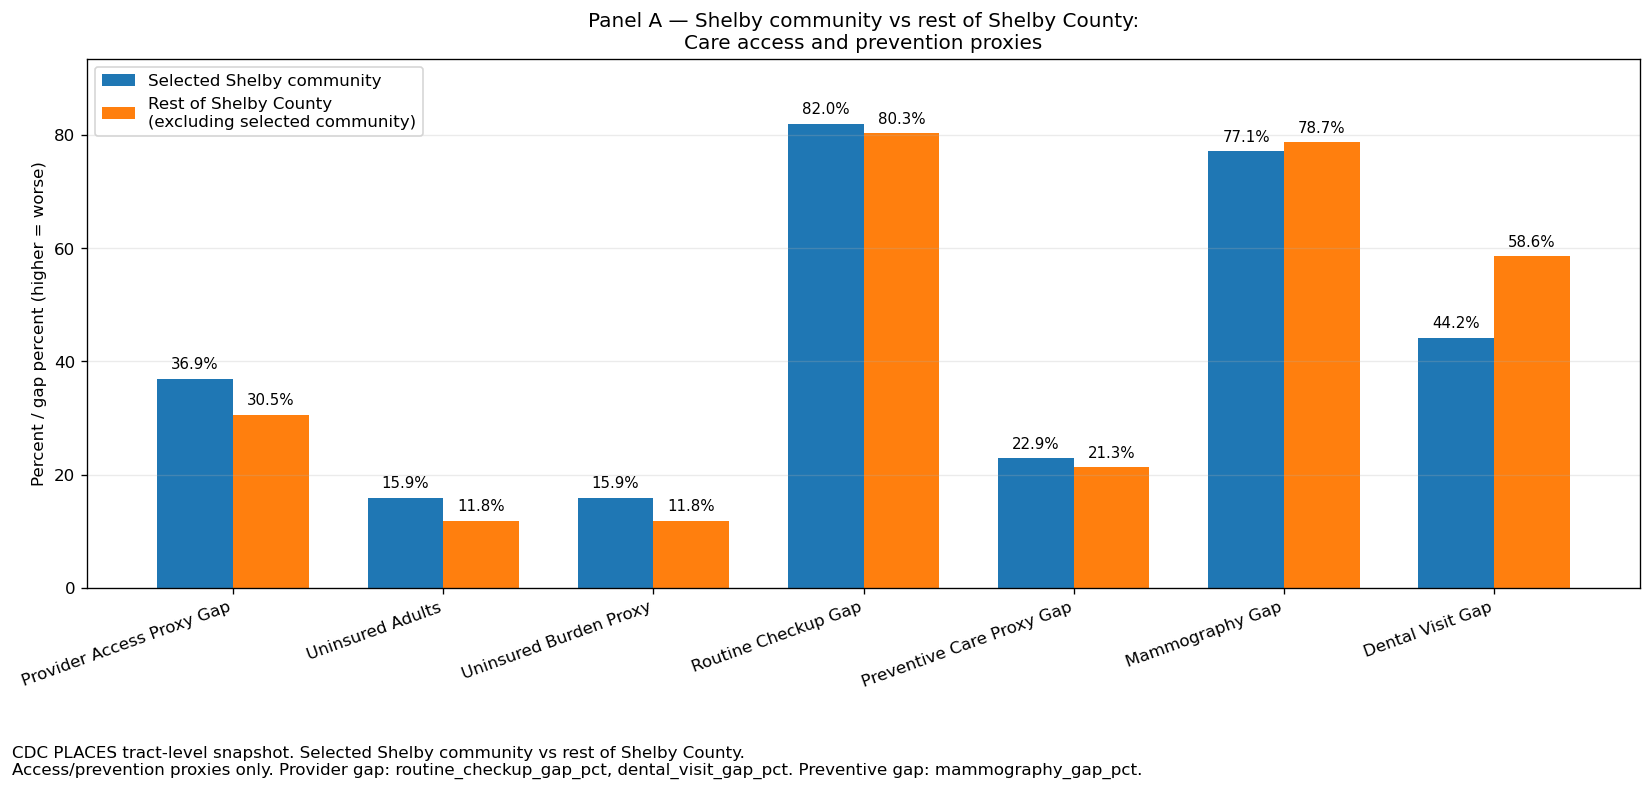

Saved: data\processed\shelby_places_panel_a_access_prevention.png


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,A,provider_access_proxy_gap_pct,Provider Access Proxy Gap,36.91,30.53,6.38,True
1,A,uninsured_adults_pct,Uninsured Adults,15.94,11.82,4.11,True
2,A,uninsured_burden_proxy_pct,Uninsured Burden Proxy,15.94,11.82,4.11,True
3,A,routine_checkup_pct,Routine Checkup Gap,82.03,80.34,1.68,False
4,A,preventive_care_proxy_gap_pct,Preventive Care Proxy Gap,22.86,21.32,1.54,True
5,A,mammography_pct,Mammography Gap,77.14,78.68,-1.54,False
6,A,dental_visit_pct,Dental Visit Gap,44.16,58.59,-14.44,False


In [181]:
# ============================================================
# Cell 7E — Panel A: care access / prevention proxies
# ============================================================

panel_a_extra = (
    "Access/prevention proxies only. "
    f"Provider gap: {shelby_places_compare['provider_inputs_used'].iloc[0]}. "
    f"Preventive gap: {shelby_places_compare['preventive_inputs_used'].iloc[0]}."
)


panel_a_df = plot_places_panel(
    summary_df=shelby_places_summary,
    panel_code="A",
    title="Panel A — Shelby community vs rest of Shelby County:\nCare access and prevention proxies",
    outfile_name="shelby_places_panel_a_access_prevention.png",
    extra_footer=panel_a_extra,
    show_bar_labels=True
)

display(panel_a_df.round(2) if panel_a_df is not None else pd.DataFrame())


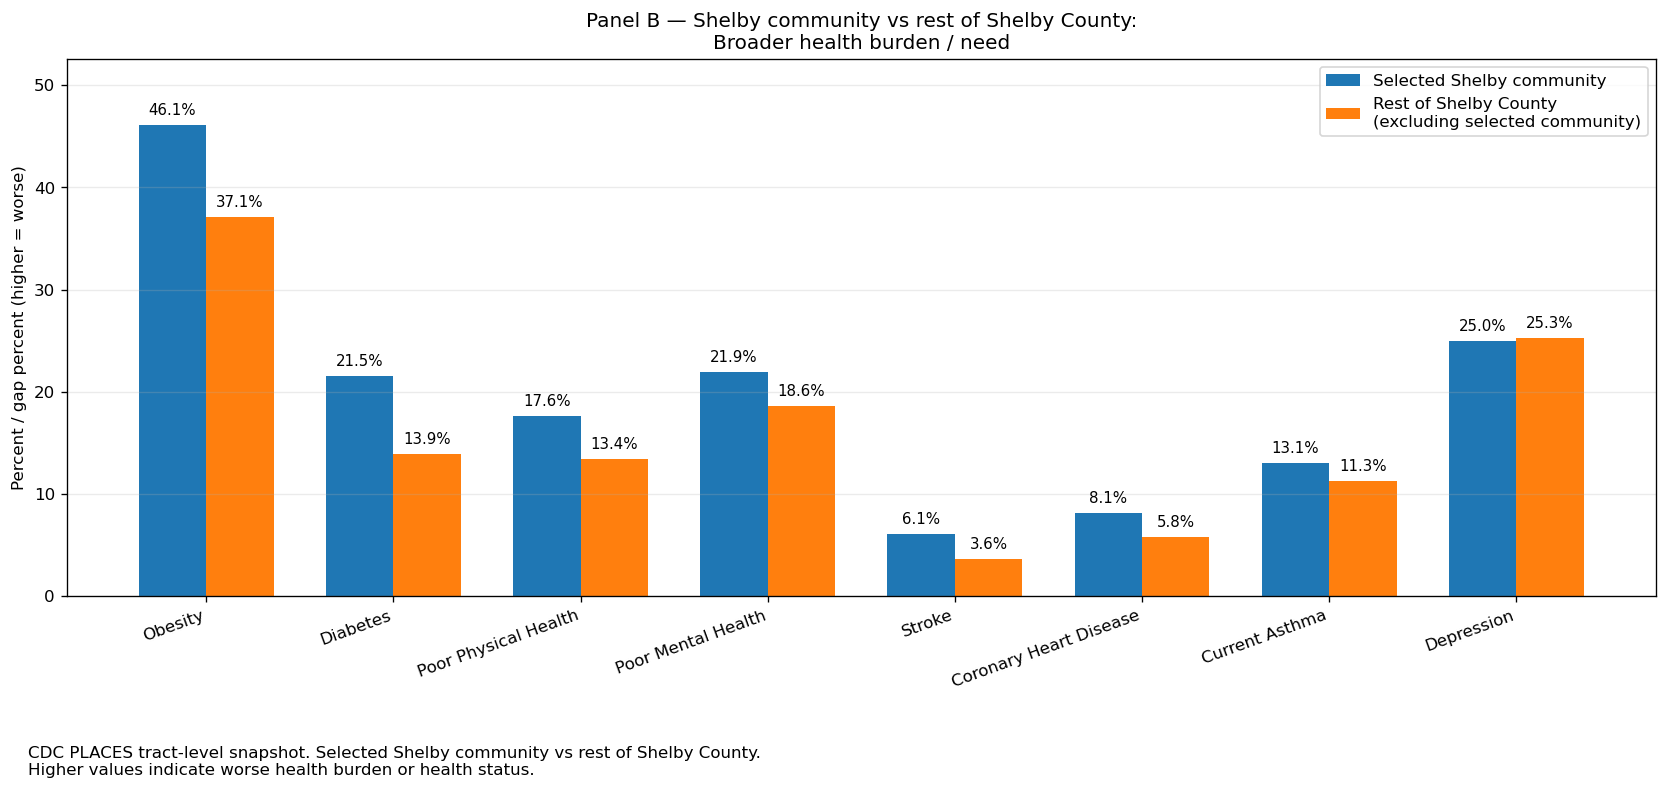

Saved: data\processed\shelby_places_panel_b_burden_need.png


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,B,obesity_pct,Obesity,46.13,37.11,9.02,True
1,B,diabetes_pct,Diabetes,21.55,13.88,7.67,True
2,B,poor_physical_health_pct,Poor Physical Health,17.62,13.38,4.23,True
3,B,poor_mental_health_pct,Poor Mental Health,21.92,18.64,3.27,True
4,B,stroke_pct,Stroke,6.09,3.60,2.49,True
5,B,coronary_heart_disease_pct,Coronary Heart Disease,8.13,5.76,2.37,True
6,B,current_asthma_pct,Current Asthma,13.05,11.28,1.77,True
7,B,depression_pct,Depression,24.96,25.28,-0.32,True


In [182]:
# ============================================================
# Cell 7F — Panel B: broader health burden / need
# ============================================================

panel_b_df = plot_places_panel(
    summary_df=shelby_places_summary,
    panel_code="B",
    title="Panel B — Shelby community vs rest of Shelby County:\nBroader health burden / need",
    outfile_name="shelby_places_panel_b_burden_need.png",
    extra_footer="Higher values indicate worse health burden or health status.",
    show_bar_labels=True
)

display(panel_b_df.round(2) if panel_b_df is not None else pd.DataFrame())


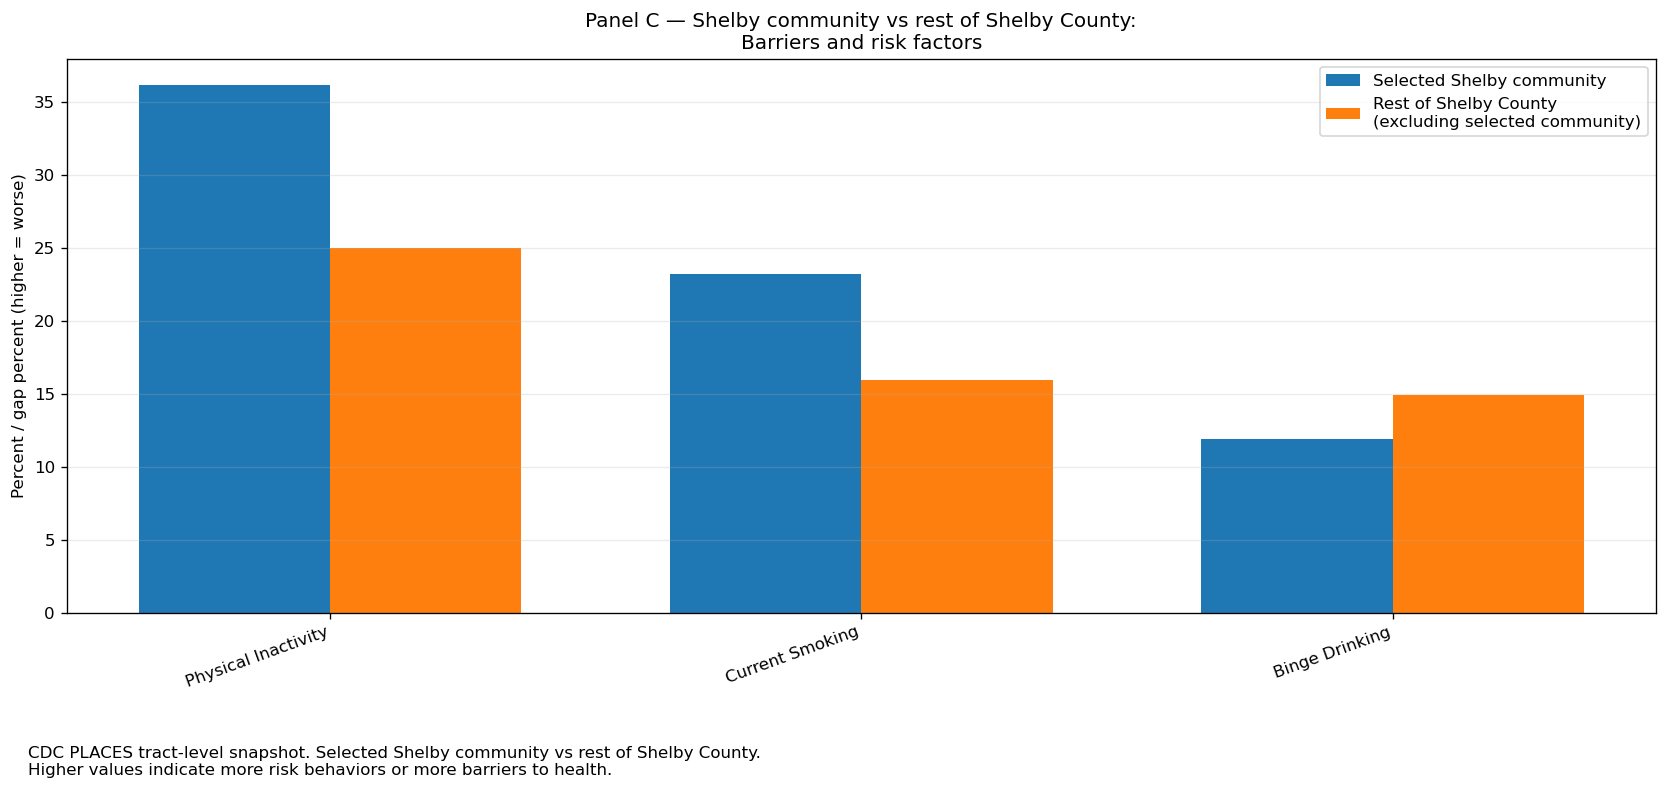

Saved: data\processed\shelby_places_panel_c_barriers_risk.png


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,C,physical_inactivity_pct,Physical Inactivity,36.13,24.99,11.14,True
1,C,smoking_pct,Current Smoking,23.21,15.93,7.28,True
2,C,binge_drinking_pct,Binge Drinking,11.87,14.91,-3.04,True


In [183]:
# ============================================================
# Cell 7G — Panel C: barriers / risk
# ============================================================

panel_c_df = plot_places_panel(
    summary_df=shelby_places_summary,
    panel_code="C",
    title="Panel C — Shelby community vs rest of Shelby County:\nBarriers and risk factors",
    outfile_name="shelby_places_panel_c_barriers_risk.png",
    extra_footer="Higher values indicate more risk behaviors or more barriers to health."
)

display(panel_c_df.round(2) if panel_c_df is not None else pd.DataFrame())


In [184]:
# ============================================================
# Cell 7H — ranked gap table
# ============================================================

ranked_gaps = (
    shelby_places_summary.loc[shelby_places_summary["selected_minus_rest"].notna()]
    .sort_values("selected_minus_rest", ascending=False)
    .reset_index(drop=True)
)

print("Top metrics where the selected Shelby community is worse than the rest of Shelby County:")
display(ranked_gaps.head(20).round(2))

ranked_gaps.to_csv(OUT_DIR / "shelby_places_ranked_gaps.csv", index=False)
print("Saved:", OUT_DIR / "shelby_places_ranked_gaps.csv")


Top metrics where the selected Shelby community is worse than the rest of Shelby County:


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,C,physical_inactivity_pct,Physical Inactivity,36.13,24.99,11.14,True
1,B,obesity_pct,Obesity,46.13,37.11,9.02,True
2,B,diabetes_pct,Diabetes,21.55,13.88,7.67,True
3,C,smoking_pct,Current Smoking,23.21,15.93,7.28,True
4,A,provider_access_proxy_gap_pct,Provider Access Proxy Gap,36.91,30.53,6.38,True
5,B,poor_physical_health_pct,Poor Physical Health,17.62,13.38,4.23,True
6,A,uninsured_burden_proxy_pct,Uninsured Burden Proxy,15.94,11.82,4.11,True
7,A,uninsured_adults_pct,Uninsured Adults,15.94,11.82,4.11,True
8,B,poor_mental_health_pct,Poor Mental Health,21.92,18.64,3.27,True
9,B,stroke_pct,Stroke,6.09,3.60,2.49,True


Saved: data\processed\shelby_places_ranked_gaps.csv


### Cell 8A — Shelby tract-level base for comparison-community search

In [185]:
# ============================================================
# Cell 8A — Shelby tract-level base for comparison-community search
# TRACT-LEVEL ONLY:
# - recovery economics from analysis_panel (tract-year -> tract average)
# - CDC PLACES from shelby_places_base (tract snapshot)
# ============================================================

import pandas as pd
import numpy as np

RECOVERY_YEARS = [2022, 2023, 2024]

# -----------------------------
# 1) tract-level recovery economics
# -----------------------------
shelby_recovery = (
    analysis_panel.loc[
        (analysis_panel["display_state"].astype(str) == "Tennessee") &
        (analysis_panel["display_county"].astype(str) == "Shelby County") &
        (analysis_panel["year"].isin(RECOVERY_YEARS)),
        [
            "geoid", "year", "pop_total",
            "igs_total", "igs_economy",
            "poverty_rate", "unemp_rate",
            "median_household_income", "lfpr_16p"
        ]
    ]
    .copy()
)

shelby_recovery["geoid"] = normalize_geoid_series(shelby_recovery["geoid"])

shelby_tract_recovery = (
    shelby_recovery
    .groupby("geoid", as_index=False)
    .agg(
        pop_total_recovery=("pop_total", "mean"),
        igs_total_recovery=("igs_total", "mean"),
        igs_economy_recovery=("igs_economy", "mean"),
        poverty_rate_recovery=("poverty_rate", "mean"),
        unemp_rate_recovery=("unemp_rate", "mean"),
        median_household_income_recovery=("median_household_income", "mean"),
        lfpr_16p_recovery=("lfpr_16p", "mean"),
    )
)

print("Shelby tract recovery rows:", shelby_tract_recovery.shape)
display(shelby_tract_recovery.head())

# -----------------------------
# 2) tract-level CDC PLACES features
# -----------------------------
shelby_cdc_tract = shelby_places_base.copy()
shelby_cdc_tract["geoid"] = normalize_geoid_series(shelby_cdc_tract["geoid"])

# Create tract-level gap versions where possible
positive_use_metrics = {
    "routine_checkup_pct": "routine_checkup_gap_pct",
    "dental_visit_pct": "dental_visit_gap_pct",
    "mammography_pct": "mammography_gap_pct",
    "flu_vax_pct": "flu_vax_gap_pct",
}

for src, dst in positive_use_metrics.items():
    if src in shelby_cdc_tract.columns:
        shelby_cdc_tract[dst] = 100 - pd.to_numeric(shelby_cdc_tract[src], errors="coerce")

cdc_metric_candidates = [
    # Panel A
    "uninsured_adults_pct",
    "routine_checkup_gap_pct",
    "dental_visit_gap_pct",
    "mammography_gap_pct",
    "flu_vax_gap_pct",

    # Panel B
    "fair_poor_health_pct",
    "poor_physical_health_pct",
    "poor_mental_health_pct",
    "depression_pct",
    "diabetes_pct",
    "obesity_pct",
    "current_asthma_pct",
    "coronary_heart_disease_pct",
    "stroke_pct",

    # Panel C
    "smoking_pct",
    "physical_inactivity_pct",
    "binge_drinking_pct",
    "sleep_lt7_pct",
    "food_insecurity_pct",
    "housing_insecurity_pct",
    "transportation_barriers_pct",
    "social_isolation_pct",
]

available_cdc_metrics = [
    c for c in cdc_metric_candidates
    if c in shelby_cdc_tract.columns and shelby_cdc_tract[c].notna().any()
]

shelby_cdc_tract = shelby_cdc_tract[["geoid"] + available_cdc_metrics].drop_duplicates(subset=["geoid"]).copy()

print("Available tract-level CDC metrics:", available_cdc_metrics)
print("Shelby CDC tract rows:", shelby_cdc_tract.shape)
display(shelby_cdc_tract.head())

# -----------------------------
# 3) full Shelby tract-level base
# -----------------------------
shelby_full_tract_base = (
    shelby_tract_recovery
    .merge(shelby_cdc_tract, on="geoid", how="left", validate="1:1")
    .copy()
)

print("Shelby full tract-level base:", shelby_full_tract_base.shape)
display(shelby_full_tract_base.head())


Shelby tract recovery rows: (249, 8)


,geoid,pop_total_recovery,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery
0,47157000100,5279.000000,54.633333,53.033333,0.112838,0.022596,74979.666667,0.742910
1,47157000200,1136.333333,36.000000,24.833333,0.426243,0.293063,26721.333333,0.468174
2,47157000300,633.333333,21.000000,22.333333,0.272600,0.094115,31292.666667,0.442642
3,47157000400,1402.333333,29.333333,21.833333,0.454500,0.069766,24896.666667,0.598070
4,47157000600,1526.333333,19.666667,21.333333,0.447769,0.097235,27738.666667,0.540581


Available tract-level CDC metrics: ['uninsured_adults_pct', 'routine_checkup_gap_pct', 'dental_visit_gap_pct', 'mammography_gap_pct', 'poor_physical_health_pct', 'poor_mental_health_pct', 'depression_pct', 'diabetes_pct', 'obesity_pct', 'current_asthma_pct', 'coronary_heart_disease_pct', 'stroke_pct', 'smoking_pct', 'physical_inactivity_pct', 'binge_drinking_pct']
Shelby CDC tract rows: (249, 16)


,geoid,uninsured_adults_pct,routine_checkup_gap_pct,dental_visit_gap_pct,mammography_gap_pct,poor_physical_health_pct,poor_mental_health_pct,depression_pct,diabetes_pct,obesity_pct,current_asthma_pct,coronary_heart_disease_pct,stroke_pct,smoking_pct,physical_inactivity_pct,binge_drinking_pct
0,47157000100,6.5,23.7,27.3,17.1,8.2,16.4,26.4,7.2,27.6,9.6,3.0,1.7,8.4,14.3,19.5
1,47157000200,18.5,16.1,69.9,26.1,22.6,25.7,26.7,29.1,55.3,15.1,10.5,8.5,32.5,46.6,9.3
2,47157000300,16.2,15.9,63.6,25.6,19.3,21.4,21.8,26.8,49.8,13.0,10.1,7.8,26.1,41.5,10.1
3,47157000400,18.1,15.5,64.5,25.6,22.5,24.1,24.8,30.3,54.2,14.5,11.6,9.1,31.0,46.2,9.1
4,47157000600,15.5,14.3,70.6,23.6,21.1,21.2,23.0,30.8,52.4,13.6,12.2,9.2,26.6,42.6,9.0


Shelby full tract-level base: (249, 23)


,geoid,pop_total_recovery,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery,uninsured_adults_pct,routine_checkup_gap_pct,dental_visit_gap_pct,mammography_gap_pct,poor_physical_health_pct,poor_mental_health_pct,depression_pct,diabetes_pct,obesity_pct,current_asthma_pct,coronary_heart_disease_pct,stroke_pct,smoking_pct,physical_inactivity_pct,binge_drinking_pct
0,47157000100,5279.000000,54.633333,53.033333,0.112838,0.022596,74979.666667,0.742910,6.5,23.7,27.3,17.1,8.2,16.4,26.4,7.2,27.6,9.6,3.0,1.7,8.4,14.3,19.5
1,47157000200,1136.333333,36.000000,24.833333,0.426243,0.293063,26721.333333,0.468174,18.5,16.1,69.9,26.1,22.6,25.7,26.7,29.1,55.3,15.1,10.5,8.5,32.5,46.6,9.3
2,47157000300,633.333333,21.000000,22.333333,0.272600,0.094115,31292.666667,0.442642,16.2,15.9,63.6,25.6,19.3,21.4,21.8,26.8,49.8,13.0,10.1,7.8,26.1,41.5,10.1
3,47157000400,1402.333333,29.333333,21.833333,0.454500,0.069766,24896.666667,0.598070,18.1,15.5,64.5,25.6,22.5,24.1,24.8,30.3,54.2,14.5,11.6,9.1,31.0,46.2,9.1
4,47157000600,1526.333333,19.666667,21.333333,0.447769,0.097235,27738.666667,0.540581,15.5,14.3,70.6,23.6,21.1,21.2,23.0,30.8,52.4,13.6,12.2,9.2,26.6,42.6,9.0


### Cell 8B — load all Shelby tract geometries + tract adjacency


In [186]:
# ============================================================
# Cell 8B — load all Shelby tract geometries + tract adjacency
# ============================================================

import geopandas as gpd
from pathlib import Path

# Reuse repo path discovery pattern
ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "src",
    Path.cwd().parent,
]

RAW_DIR = None
PROCESSED_DIR = None

for root in ROOT_CANDIDATES:
    if (root / "src/data/raw").exists():
        RAW_DIR = root / "src/data/raw"
        PROCESSED_DIR = root / "src/data/processed"
        break
    if (root / "data/raw").exists():
        RAW_DIR = root / "data/raw"
        PROCESSED_DIR = root / "data/processed"
        break

if RAW_DIR is None:
    raise FileNotFoundError("Could not find data/raw or src/data/raw.")

OUT_DIR = PROCESSED_DIR / "presentation_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Find Tennessee tract shapefile
shp_candidates = list(RAW_DIR.rglob("*47*tract*.shp")) + list(RAW_DIR.rglob("*tract*.shp"))

tract_shp = None
for p in shp_candidates:
    name = p.name.lower()
    parent = str(p.parent).lower()
    if "tract" in name and ("47" in name or "tennessee" in name or "state_tract" in parent):
        tract_shp = p
        break

if tract_shp is None:
    raise FileNotFoundError("Could not find a Tennessee tract shapefile in data/raw.")

print("Using tract shapefile:", tract_shp)

tracts = gpd.read_file(tract_shp).copy()

# Standardize GEOID
possible_geoid_cols = ["GEOID", "geoid", "GEOIDFQ", "TRACTCE"]
geoid_col = None
for c in possible_geoid_cols:
    if c in tracts.columns:
        geoid_col = c
        break

if geoid_col is None:
    raise ValueError(f"Could not find a GEOID-like column. Columns: {list(tracts.columns)}")

if geoid_col == "TRACTCE":
    if not all(c in tracts.columns for c in ["STATEFP", "COUNTYFP", "TRACTCE"]):
        raise ValueError("TRACTCE found, but STATEFP/COUNTYFP/TRACTCE not all present.")
    tracts["geoid"] = (
        tracts["STATEFP"].astype(str).str.zfill(2)
        + tracts["COUNTYFP"].astype(str).str.zfill(3)
        + tracts["TRACTCE"].astype(str).str.zfill(6)
    )
else:
    tracts["geoid"] = tracts[geoid_col].astype(str).str.extract(r"(\d{11})", expand=False)
    if tracts["geoid"].isna().all():
        tracts["geoid"] = tracts[geoid_col].astype(str).str.zfill(11)

# Keep Shelby County only
if "STATEFP" in tracts.columns and "COUNTYFP" in tracts.columns:
    shelby_geo = tracts.loc[
        (tracts["STATEFP"].astype(str).str.zfill(2) == "47") &
        (tracts["COUNTYFP"].astype(str).str.zfill(3) == "157")
    ].copy()
else:
    shelby_geo = tracts.loc[tracts["geoid"].str[:5] == "47157"].copy()

# Keep only tracts that exist in the tract-level base
shelby_geo["geoid"] = normalize_geoid_series(shelby_geo["geoid"])
shelby_geo = shelby_geo.loc[shelby_geo["geoid"].isin(shelby_full_tract_base["geoid"])].copy()

print("Shelby geometry rows kept:", shelby_geo.shape)

# Build adjacency from touching polygons
left = shelby_geo[["geoid", "geometry"]].rename(columns={"geoid": "geoid_left"})
right = shelby_geo[["geoid", "geometry"]].rename(columns={"geoid": "geoid_right"})

adj = gpd.sjoin(left, right, how="inner", predicate="touches")
adj = adj.loc[adj["geoid_left"] != adj["geoid_right"], ["geoid_left", "geoid_right"]].drop_duplicates()

print("Shelby adjacency edges:", adj.shape)
display(adj.head())


Using tract shapefile: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\raw\tl_2024_state_tracts\tl_2024_47_tract\tl_2024_47_tract.shp
Shelby geometry rows kept: (249, 15)
Shelby adjacency edges: (1568, 2)


,geoid_left,geoid_right
5,47157003100,47157006700
5,47157003100,47157006600
5,47157003100,47157006300
5,47157003100,47157007100
5,47157003100,47157003300


### Cell 8C — full-county Shelby community map

In [187]:
# ============================================================
# Cell 8C — full-county Shelby community map
# IMPORTANT:
# We do NOT use connected components alone, because Shelby is contiguous.
# We use spatially constrained clustering:
# - adjacency enforces contiguity
# - tract-level recovery + CDC metrics define similarity
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.sparse import coo_matrix

# Number of Shelby communities to create
# You can tune this later. 6 is a good first pass.
N_SHELBY_COMMUNITIES = 6

# Merge tract base with geometry
shelby_cluster_input = (
    shelby_geo[["geoid", "geometry"]]
    .merge(shelby_full_tract_base, on="geoid", how="inner", validate="1:1")
    .copy()
)

# Tract-level features only
feature_candidates = [
    # Recovery economics
    "igs_total_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",

    # Panel A
    "uninsured_adults_pct",
    "routine_checkup_gap_pct",
    "dental_visit_gap_pct",
    "mammography_gap_pct",
    "flu_vax_gap_pct",

    # Panel B
    "fair_poor_health_pct",
    "poor_physical_health_pct",
    "poor_mental_health_pct",
    "depression_pct",
    "diabetes_pct",
    "obesity_pct",
    "current_asthma_pct",
    "coronary_heart_disease_pct",
    "stroke_pct",

    # Panel C
    "smoking_pct",
    "physical_inactivity_pct",
    "binge_drinking_pct",
    "sleep_lt7_pct",
    "food_insecurity_pct",
    "housing_insecurity_pct",
    "transportation_barriers_pct",
    "social_isolation_pct",
]

available_features = [
    c for c in feature_candidates
    if c in shelby_cluster_input.columns and shelby_cluster_input[c].notna().any()
]

if not available_features:
    raise ValueError("No tract-level features available for Shelby clustering.")

print("Features used for Shelby community map:")
print(available_features)

X = shelby_cluster_input[available_features].copy()

# Flip higher-is-better economics so higher values consistently mean "more vulnerable"
for col in ["igs_total_recovery", "igs_economy_recovery", "median_household_income_recovery", "lfpr_16p_recovery"]:
    if col in X.columns:
        X[col] = -pd.to_numeric(X[col], errors="coerce")

# Impute + scale
X = SimpleImputer(strategy="median").fit_transform(X)
X = StandardScaler().fit_transform(X)

# Sparse adjacency matrix
geoid_order = shelby_cluster_input["geoid"].tolist()
idx_map = {g: i for i, g in enumerate(geoid_order)}

edge_df = adj.loc[
    adj["geoid_left"].isin(idx_map) & adj["geoid_right"].isin(idx_map)
].copy()

rows = edge_df["geoid_left"].map(idx_map).to_numpy()
cols = edge_df["geoid_right"].map(idx_map).to_numpy()
data = np.ones(len(edge_df), dtype=int)

connectivity = coo_matrix((data, (rows, cols)), shape=(len(geoid_order), len(geoid_order)))
connectivity = connectivity.maximum(connectivity.T)

# Spatially constrained clustering
try:
    cluster_model = AgglomerativeClustering(
        n_clusters=N_SHELBY_COMMUNITIES,
        linkage="ward",
        metric="euclidean",
        connectivity=connectivity
    )
except TypeError:
    cluster_model = AgglomerativeClustering(
        n_clusters=N_SHELBY_COMMUNITIES,
        linkage="ward",
        affinity="euclidean",
        connectivity=connectivity
    )

labels = cluster_model.fit_predict(X)

shelby_cluster_input["shelby_full_cluster_label"] = labels
shelby_cluster_input["shelby_full_cluster_id"] = [
    f"Shelby County full community {int(x)+1}"
    for x in labels
]

print("Shelby full-community tract counts:")
display(
    shelby_cluster_input["shelby_full_cluster_id"]
    .value_counts()
    .rename_axis("community")
    .reset_index(name="tract_count")
)

# Save tract-level community map
shelby_full_tract_cluster_map = shelby_cluster_input[["geoid", "geometry", "shelby_full_cluster_id"]].copy()
shelby_full_tract_cluster_map.to_file(
    OUT_DIR / "shelby_full_tract_cluster_map.geojson",
    driver="GeoJSON"
)

print("Saved:", OUT_DIR / "shelby_full_tract_cluster_map.geojson")


Features used for Shelby community map:
['igs_total_recovery', 'igs_economy_recovery', 'poverty_rate_recovery', 'unemp_rate_recovery', 'median_household_income_recovery', 'lfpr_16p_recovery', 'uninsured_adults_pct', 'routine_checkup_gap_pct', 'dental_visit_gap_pct', 'mammography_gap_pct', 'poor_physical_health_pct', 'poor_mental_health_pct', 'depression_pct', 'diabetes_pct', 'obesity_pct', 'current_asthma_pct', 'coronary_heart_disease_pct', 'stroke_pct', 'smoking_pct', 'physical_inactivity_pct', 'binge_drinking_pct']
Shelby full-community tract counts:


,community,tract_count
0,Shelby County full community 1,72
1,Shelby County full community 4,63
2,Shelby County full community 3,53
3,Shelby County full community 2,52
4,Shelby County full community 5,7
5,Shelby County full community 6,2


Saved: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\shelby_full_tract_cluster_map.geojson


### Cell 8D — aggregate Shelby full communities

In [188]:
# ============================================================
# Cell 8D — aggregate Shelby full communities
# TRACT-LEVEL ONLY aggregation
# ============================================================

def weighted_mean_safe(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

community_metric_cols = [c for c in available_features if c in shelby_cluster_input.columns]

community_rows = []
for community_id, grp in shelby_cluster_input.groupby("shelby_full_cluster_id", dropna=False):
    weights = grp["pop_total_recovery"] if "pop_total_recovery" in grp.columns else pd.Series(np.ones(len(grp)), index=grp.index)

    row = {
        "community_id": community_id,
        "n_tracts": int(grp["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(grp["pop_total_recovery"], errors="coerce").fillna(0).sum()),
    }

    for col in community_metric_cols:
        row[col] = weighted_mean_safe(grp[col], weights)

    community_rows.append(row)

shelby_full_community_compare = pd.DataFrame(community_rows)

# Useful tract-level proxy summaries
access_cols = [
    c for c in [
        "uninsured_adults_pct",
        "routine_checkup_gap_pct",
        "dental_visit_gap_pct",
        "mammography_gap_pct",
        "flu_vax_gap_pct",
    ] if c in shelby_full_community_compare.columns
]

burden_cols = [
    c for c in [
        "fair_poor_health_pct",
        "poor_physical_health_pct",
        "poor_mental_health_pct",
        "depression_pct",
        "diabetes_pct",
        "obesity_pct",
        "current_asthma_pct",
        "coronary_heart_disease_pct",
        "stroke_pct",
    ] if c in shelby_full_community_compare.columns
]

barrier_cols = [
    c for c in [
        "smoking_pct",
        "physical_inactivity_pct",
        "binge_drinking_pct",
        "sleep_lt7_pct",
        "food_insecurity_pct",
        "housing_insecurity_pct",
        "transportation_barriers_pct",
        "social_isolation_pct",
    ] if c in shelby_full_community_compare.columns
]

if access_cols:
    shelby_full_community_compare["access_proxy_mean_pct"] = shelby_full_community_compare[access_cols].mean(axis=1, skipna=True)
if burden_cols:
    shelby_full_community_compare["burden_proxy_mean_pct"] = shelby_full_community_compare[burden_cols].mean(axis=1, skipna=True)
if barrier_cols:
    shelby_full_community_compare["barrier_proxy_mean_pct"] = shelby_full_community_compare[barrier_cols].mean(axis=1, skipna=True)

display_cols = [
    "community_id", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in shelby_full_community_compare.columns]

display(
    shelby_full_community_compare[display_cols]
    .sort_values(["igs_total_recovery", "igs_economy_recovery"], ascending=[False, False])
    .round(2)
)

shelby_full_community_compare.to_csv(OUT_DIR / "shelby_full_community_compare.csv", index=False)
print("Saved:", OUT_DIR / "shelby_full_community_compare.csv")


,community_id,n_tracts,population_sum,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery,access_proxy_mean_pct,burden_proxy_mean_pct,barrier_proxy_mean_pct
3,Shelby County full community 4,63,296279.00,55.67,56.53,0.05,0.04,119392.31,0.67,19.64,14.11,15.37
1,Shelby County full community 2,52,197913.00,47.43,50.15,0.13,0.05,65910.97,0.70,23.82,15.98,18.39
2,Shelby County full community 3,53,204688.33,41.32,40.30,0.20,0.10,57473.31,0.67,25.87,18.37,21.34
4,Shelby County full community 5,7,31176.33,38.74,39.90,0.28,0.06,42031.74,0.63,36.68,20.04,27.36
0,Shelby County full community 1,72,189213.33,32.73,31.75,0.38,0.14,32579.75,0.55,31.01,21.77,26.69
5,Shelby County full community 6,2,3332.67,NaN,35.71,NaN,NaN,NaN,0.00,35.81,16.63,26.19


Saved: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\shelby_full_community_compare.csv


### Cell 8E — selected Shelby community benchmark

In [189]:
# ============================================================
# Cell 8E — selected Shelby community benchmark
# Uses the SAME tract-level base as the full-county communities
# ============================================================

SELECTED_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"

selected_geoids = set()

if "tract_cluster_map" in globals():
    tmp = tract_cluster_map.copy()
    if "geoid" in tmp.columns and "cluster_id" in tmp.columns:
        tmp["geoid"] = normalize_geoid_series(tmp["geoid"])
        selected_geoids = set(
            tmp.loc[tmp["cluster_id"].astype(str) == SELECTED_CLUSTER_ID, "geoid"]
            .dropna()
            .tolist()
        )

if not selected_geoids and "TARGET_GEOIDS" in globals():
    selected_geoids = set(normalize_geoid_series(pd.Series(TARGET_GEOIDS)).dropna().tolist())

if not selected_geoids:
    raise ValueError("Could not recover the selected Shelby community GEOIDs.")

selected_benchmark_tracts = shelby_cluster_input.loc[
    shelby_cluster_input["geoid"].isin(selected_geoids)
].copy()

if selected_benchmark_tracts.empty:
    raise ValueError("Selected Shelby community has no overlap with the Shelby tract-level base.")

weights = selected_benchmark_tracts["pop_total_recovery"]

selected_benchmark = {
    "community_id": "Selected Shelby community",
    "n_tracts": int(selected_benchmark_tracts["geoid"].nunique()),
    "population_sum": float(pd.to_numeric(selected_benchmark_tracts["pop_total_recovery"], errors="coerce").fillna(0).sum()),
}

for col in community_metric_cols:
    selected_benchmark[col] = weighted_mean_safe(selected_benchmark_tracts[col], weights)

selected_benchmark = pd.Series(selected_benchmark)

# proxy summaries
if access_cols:
    selected_benchmark["access_proxy_mean_pct"] = np.nanmean([selected_benchmark.get(c, np.nan) for c in access_cols])
if burden_cols:
    selected_benchmark["burden_proxy_mean_pct"] = np.nanmean([selected_benchmark.get(c, np.nan) for c in burden_cols])
if barrier_cols:
    selected_benchmark["barrier_proxy_mean_pct"] = np.nanmean([selected_benchmark.get(c, np.nan) for c in barrier_cols])

display(pd.DataFrame([selected_benchmark]).round(2))


,community_id,n_tracts,population_sum,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery,uninsured_adults_pct,routine_checkup_gap_pct,dental_visit_gap_pct,mammography_gap_pct,poor_physical_health_pct,poor_mental_health_pct,depression_pct,diabetes_pct,obesity_pct,current_asthma_pct,coronary_heart_disease_pct,stroke_pct,smoking_pct,physical_inactivity_pct,binge_drinking_pct,access_proxy_mean_pct,burden_proxy_mean_pct,barrier_proxy_mean_pct
0,Selected Shelby community,96,273280.67,35.81,35.12,0.3,0.12,43421.37,0.58,15.94,17.95,55.91,22.87,17.63,21.92,24.95,21.59,46.17,13.06,8.14,6.1,23.24,36.17,11.85,28.17,19.95,23.76


### Cell 8F — identify a better Shelby comparison community

In [190]:
# ============================================================
# Cell 8F — identify a better Shelby comparison community
# Rules:
# - same county
# - no overlap with selected Shelby community
# - tract-level recovery IGS > 45
# - stronger recovery economics
# - lower access/burden/barrier proxy means where available
# ============================================================

# Count overlap with selected community
selected_geoid_set = set(selected_benchmark_tracts["geoid"].tolist())

overlap_rows = []
for community_id, grp in shelby_cluster_input.groupby("shelby_full_cluster_id", dropna=False):
    overlap_rows.append({
        "community_id": community_id,
        "selected_overlap_tracts": int(grp["geoid"].isin(selected_geoid_set).sum())
    })

overlap_df = pd.DataFrame(overlap_rows)

candidate_df = (
    shelby_full_community_compare
    .merge(overlap_df, on="community_id", how="left", validate="1:1")
    .copy()
)

# Hard filters
eligibility = pd.Series(True, index=candidate_df.index)

# Must not overlap selected cluster
eligibility &= candidate_df["selected_overlap_tracts"].fillna(0).eq(0)

# Avoid tiny communities
eligibility &= candidate_df["n_tracts"] >= 5
eligibility &= candidate_df["population_sum"] >= 10000

# Must be clearly less vulnerable on tract-level recovery IGS
if "igs_total_recovery" in candidate_df.columns and pd.notna(selected_benchmark.get("igs_total_recovery", np.nan)):
    eligibility &= candidate_df["igs_total_recovery"] > 45
    eligibility &= candidate_df["igs_total_recovery"] > selected_benchmark["igs_total_recovery"]

# Better tract-level economics
for col, op in [
    ("igs_economy_recovery", "gt"),
    ("poverty_rate_recovery", "lt"),
    ("unemp_rate_recovery", "lt"),
    ("median_household_income_recovery", "gt"),
    ("lfpr_16p_recovery", "gt"),
]:
    if col in candidate_df.columns and pd.notna(selected_benchmark.get(col, np.nan)):
        if op == "gt":
            eligibility &= candidate_df[col] > selected_benchmark[col]
        else:
            eligibility &= candidate_df[col] < selected_benchmark[col]

# Better tract-level access / burden / barriers where available
for col in ["access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct"]:
    if col in candidate_df.columns and pd.notna(selected_benchmark.get(col, np.nan)):
        eligibility &= candidate_df[col] < selected_benchmark[col]

eligible_candidates = candidate_df.loc[eligibility].copy()

print("Eligible better Shelby communities found:", len(eligible_candidates))

display_cols = [
    "community_id", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in eligible_candidates.columns]

display(
    eligible_candidates[display_cols]
    .sort_values(["igs_total_recovery", "igs_economy_recovery"], ascending=[False, False])
    .round(2)
)

if eligible_candidates.empty:
    print("No community passed the strict screen. Relax one filter and rerun.")


Eligible better Shelby communities found: 1


,community_id,n_tracts,population_sum,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery,access_proxy_mean_pct,burden_proxy_mean_pct,barrier_proxy_mean_pct
3,Shelby County full community 4,63,296279.0,55.67,56.53,0.05,0.04,119392.31,0.67,19.64,14.11,15.37


### Cell 8G — rank the eligible candidates

In [191]:
# ============================================================
# Cell 8G — rank the eligible candidates
# ============================================================

rank_df = eligible_candidates.copy()

if rank_df.empty:
    raise ValueError("No eligible candidates to rank. Relax the rules in Cell 8F.")

score_cols = []

def add_rank_component(df, col, ascending, new_col):
    if col in df.columns:
        df[new_col] = df[col].rank(pct=True, ascending=ascending)
        score_cols.append(new_col)

# better if larger
add_rank_component(rank_df, "igs_total_recovery", ascending=True, new_col="rank_igs_total")
add_rank_component(rank_df, "igs_economy_recovery", ascending=True, new_col="rank_igs_economy")
add_rank_component(rank_df, "median_household_income_recovery", ascending=True, new_col="rank_income")
add_rank_component(rank_df, "lfpr_16p_recovery", ascending=True, new_col="rank_lfpr")

# better if smaller
add_rank_component(rank_df, "poverty_rate_recovery", ascending=False, new_col="rank_poverty")
add_rank_component(rank_df, "unemp_rate_recovery", ascending=False, new_col="rank_unemp")
add_rank_component(rank_df, "access_proxy_mean_pct", ascending=False, new_col="rank_access")
add_rank_component(rank_df, "burden_proxy_mean_pct", ascending=False, new_col="rank_burden")
add_rank_component(rank_df, "barrier_proxy_mean_pct", ascending=False, new_col="rank_barrier")

rank_df["comparison_rank_score"] = rank_df[score_cols].mean(axis=1, skipna=True)

rank_df = rank_df.sort_values(
    ["comparison_rank_score", "igs_total_recovery", "igs_economy_recovery"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(
    rank_df[
        [c for c in [
            "community_id", "comparison_rank_score",
            "n_tracts", "population_sum",
            "igs_total_recovery", "igs_economy_recovery",
            "poverty_rate_recovery", "unemp_rate_recovery",
            "median_household_income_recovery", "lfpr_16p_recovery",
            "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct"
        ] if c in rank_df.columns]
    ].head(10).round(3)
)

BEST_SHELBY_COMPARATOR_ID = rank_df.iloc[0]["community_id"]
print("Best Shelby comparator selected:", BEST_SHELBY_COMPARATOR_ID)

rank_df.to_csv(OUT_DIR / "shelby_better_community_candidates_ranked.csv", index=False)
print("Saved:", OUT_DIR / "shelby_better_community_candidates_ranked.csv")


,community_id,comparison_rank_score,n_tracts,population_sum,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery,access_proxy_mean_pct,burden_proxy_mean_pct,barrier_proxy_mean_pct
0,Shelby County full community 4,1.0,63,296279.0,55.667,56.527,0.054,0.035,119392.308,0.669,19.643,14.11,15.37


Best Shelby comparator selected: Shelby County full community 4
Saved: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\shelby_better_community_candidates_ranked.csv


### Cell 8H — selected vs better Shelby comparison table

In [192]:
# ============================================================
# Cell 8H — selected vs better Shelby comparison table
# ============================================================

best_row = rank_df.loc[rank_df["community_id"] == BEST_SHELBY_COMPARATOR_ID].iloc[0]

selected_vs_better = pd.DataFrame([
    selected_benchmark.to_dict(),
    best_row.to_dict()
])

display_cols = [
    "community_id", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in selected_vs_better.columns]

display(selected_vs_better[display_cols].round(2))

selected_vs_better.to_csv(OUT_DIR / "selected_vs_better_shelby_community.csv", index=False)
print("Saved:", OUT_DIR / "selected_vs_better_shelby_community.csv")


,community_id,n_tracts,population_sum,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery,access_proxy_mean_pct,burden_proxy_mean_pct,barrier_proxy_mean_pct
0,Selected Shelby community,96,273280.67,35.81,35.12,0.30,0.12,43421.37,0.58,28.17,19.95,23.76
1,Shelby County full community 4,63,296279.00,55.67,56.53,0.05,0.04,119392.31,0.67,19.64,14.11,15.37


Saved: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\selected_vs_better_shelby_community.csv


### Cell 8I — map the 6 Shelby full communities

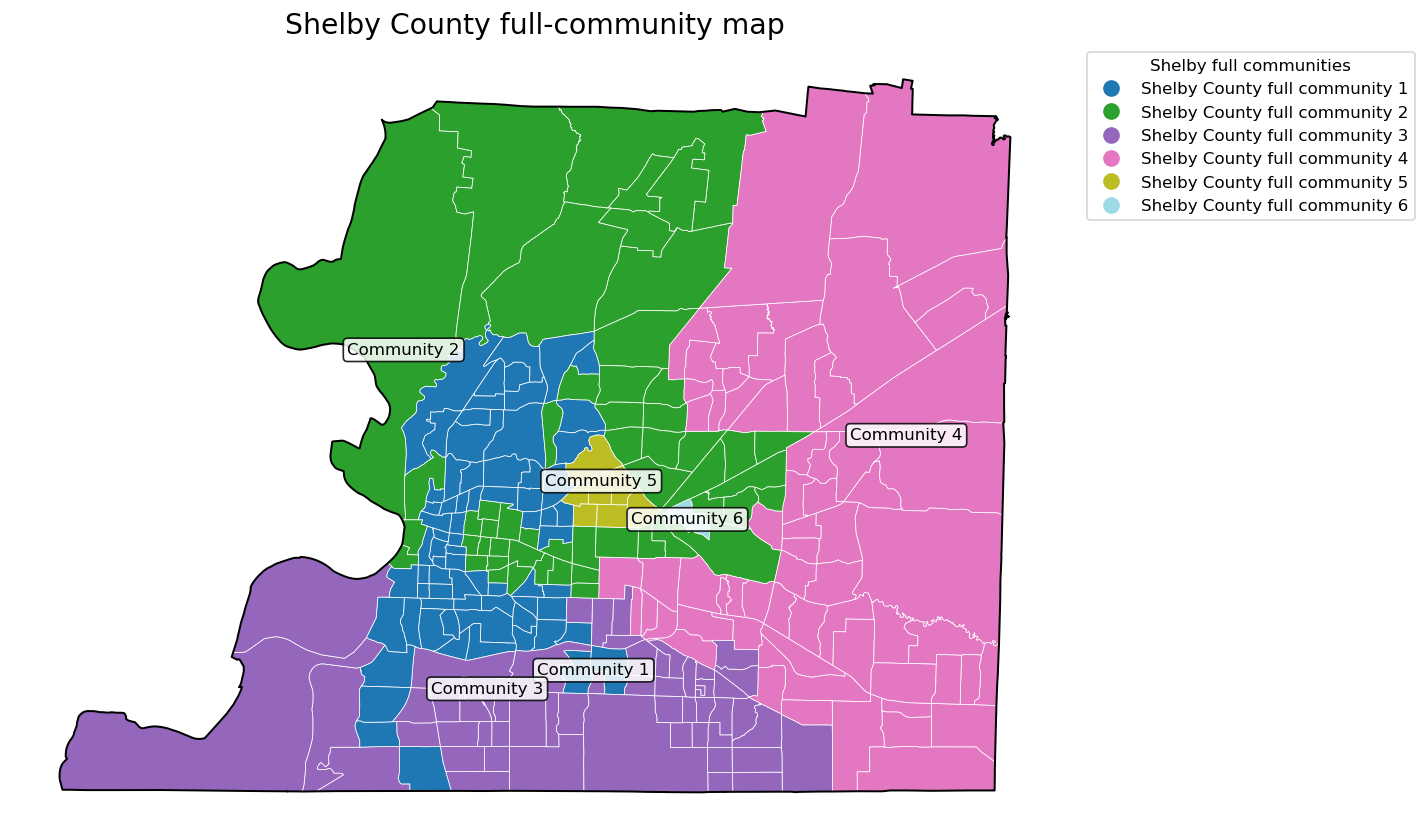

Saved: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\shelby_full_communities_map.png


In [193]:
# ============================================================
# Cell 8I — map the 6 Shelby full communities
# ============================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import re

# --------------------------------------------------
# 1) Recover community geometry table
# --------------------------------------------------
if "shelby_full_tract_cluster_map" in globals():
    map_gdf = shelby_full_tract_cluster_map.copy()
elif "shelby_cluster_input" in globals():
    map_gdf = shelby_cluster_input[["geoid", "geometry", "shelby_full_cluster_id"]].copy()
else:
    raise ValueError(
        "Could not find shelby_full_tract_cluster_map or shelby_cluster_input. "
        "Run Cells 8B–8C first."
    )

if "shelby_full_cluster_id" not in map_gdf.columns:
    raise ValueError("Expected column 'shelby_full_cluster_id' not found.")

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=getattr(map_gdf, "crs", None))
map_gdf["geoid"] = normalize_geoid_series(map_gdf["geoid"])

# Use Shelby geometry CRS if available
if "shelby_geo" in globals():
    county_base = shelby_geo.copy()
else:
    county_base = map_gdf.copy()

# Reproject for cleaner plotting
if map_gdf.crs is not None:
    map_gdf = map_gdf.to_crs(3857)
    county_base = county_base.to_crs(3857)

county_outline = county_base.dissolve()

# --------------------------------------------------
# 2) Sort community IDs in numeric order
# --------------------------------------------------
def extract_num(s):
    m = re.search(r"(\d+)$", str(s))
    return int(m.group(1)) if m else 9999

community_order = sorted(map_gdf["shelby_full_cluster_id"].dropna().unique().tolist(), key=extract_num)
map_gdf["shelby_full_cluster_id"] = pd.Categorical(
    map_gdf["shelby_full_cluster_id"],
    categories=community_order,
    ordered=True
)

# --------------------------------------------------
# 3) Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Fill tracts by community
map_gdf.plot(
    ax=ax,
    column="shelby_full_cluster_id",
    categorical=True,
    cmap="tab20",
    edgecolor="white",
    linewidth=0.45,
    legend=True,
    legend_kwds={
        "title": "Shelby full communities",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 1.0)
    }
)

# County outline
county_outline.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    zorder=3
)

# --------------------------------------------------
# 4) Add labels at representative points
# --------------------------------------------------
community_shapes = map_gdf.dissolve(by="shelby_full_cluster_id").reset_index()
community_shapes["label_pt"] = community_shapes.representative_point()

for _, row in community_shapes.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    label = str(row["shelby_full_cluster_id"]).replace("Shelby County full community ", "Community ")
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.85),
        zorder=4
    )

ax.set_title("Shelby County full-community map", fontsize=17)
ax.set_axis_off()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5) Save
# --------------------------------------------------
map_path = OUT_DIR / "shelby_full_communities_map.png"
fig.savefig(map_path, bbox_inches="tight", dpi=220)
print("Saved:", map_path)


### Cell 8I — final 3-group tract-level comparison

In [194]:
# ============================================================
# Cell 8I — final 3-group tract-level comparison
# Groups:
# 1) Selected low-growth Shelby community (original 96-tract community)
# 2) Selected high-growth Shelby comparator (chosen from full-county partition)
# 3) Rest of Shelby County excluding both selected communities
# TRACT-LEVEL ONLY
# ============================================================

import pandas as pd
import numpy as np

required_objs = [
    "shelby_cluster_input",
    "selected_benchmark_tracts",
    "BEST_SHELBY_COMPARATOR_ID",
    "community_metric_cols"
]
for obj in required_objs:
    if obj not in globals():
        raise ValueError(f"Missing required object: {obj}")

# --------------------------------------------------
# 1) tract sets
# --------------------------------------------------
all_shelby_geoids = set(shelby_cluster_input["geoid"].dropna().tolist())

low_growth_geoids = set(selected_benchmark_tracts["geoid"].dropna().tolist())

high_growth_geoids = set(
    shelby_cluster_input.loc[
        shelby_cluster_input["shelby_full_cluster_id"].astype(str) == str(BEST_SHELBY_COMPARATOR_ID),
        "geoid"
    ].dropna().tolist()
)

# Remove any accidental overlap
high_growth_geoids = high_growth_geoids - low_growth_geoids

rest_geoids = all_shelby_geoids - low_growth_geoids - high_growth_geoids

print("Low-growth selected community tracts:", len(low_growth_geoids))
print("High-growth selected comparator tracts:", len(high_growth_geoids))
print("Rest of Shelby County tracts:", len(rest_geoids))
print("All Shelby tracts:", len(all_shelby_geoids))
print("Check sum:", len(low_growth_geoids) + len(high_growth_geoids) + len(rest_geoids))

assert len(low_growth_geoids) + len(high_growth_geoids) + len(rest_geoids) == len(all_shelby_geoids), \
    "The 3-group partition does not sum to all Shelby tracts."

# --------------------------------------------------
# 2) assign final 3-group labels
# --------------------------------------------------
three_group_base = shelby_cluster_input.copy()

def assign_group(g):
    if g in low_growth_geoids:
        return "Selected low-growth community"
    elif g in high_growth_geoids:
        return "Selected high-growth comparator"
    else:
        return "Rest of Shelby County (excluding both selected communities)"

three_group_base["final_compare_group"] = three_group_base["geoid"].map(assign_group)

print(three_group_base["final_compare_group"].value_counts(dropna=False))

# --------------------------------------------------
# 3) weighted aggregation helper
# --------------------------------------------------
def weighted_mean_safe(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

# --------------------------------------------------
# 4) aggregate tract-level metrics into the 3 groups
# --------------------------------------------------
three_group_rows = []

for grp_name, grp in three_group_base.groupby("final_compare_group", dropna=False):
    weights = grp["pop_total_recovery"] if "pop_total_recovery" in grp.columns else pd.Series(np.ones(len(grp)), index=grp.index)

    row = {
        "group": grp_name,
        "n_tracts": int(grp["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(grp["pop_total_recovery"], errors="coerce").fillna(0).sum()),
    }

    for col in community_metric_cols:
        if col in grp.columns:
            row[col] = weighted_mean_safe(grp[col], weights)

    three_group_rows.append(row)

three_group_compare = pd.DataFrame(three_group_rows)

# --------------------------------------------------
# 5) tract-level proxy summaries
# --------------------------------------------------
access_cols = [
    c for c in [
        "uninsured_adults_pct",
        "routine_checkup_gap_pct",
        "dental_visit_gap_pct",
        "mammography_gap_pct",
        "flu_vax_gap_pct",
    ] if c in three_group_compare.columns
]

burden_cols = [
    c for c in [
        "fair_poor_health_pct",
        "poor_physical_health_pct",
        "poor_mental_health_pct",
        "depression_pct",
        "diabetes_pct",
        "obesity_pct",
        "current_asthma_pct",
        "coronary_heart_disease_pct",
        "stroke_pct",
    ] if c in three_group_compare.columns
]

barrier_cols = [
    c for c in [
        "smoking_pct",
        "physical_inactivity_pct",
        "binge_drinking_pct",
        "sleep_lt7_pct",
        "food_insecurity_pct",
        "housing_insecurity_pct",
        "transportation_barriers_pct",
        "social_isolation_pct",
    ] if c in three_group_compare.columns
]

if access_cols:
    three_group_compare["access_proxy_mean_pct"] = three_group_compare[access_cols].mean(axis=1, skipna=True)
if burden_cols:
    three_group_compare["burden_proxy_mean_pct"] = three_group_compare[burden_cols].mean(axis=1, skipna=True)
if barrier_cols:
    three_group_compare["barrier_proxy_mean_pct"] = three_group_compare[barrier_cols].mean(axis=1, skipna=True)

display_cols = [
    "group", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in three_group_compare.columns]

display(three_group_compare[display_cols].round(2))

three_group_compare.to_csv(OUT_DIR / "three_group_selected_vs_comparator_vs_rest.csv", index=False)
print("Saved:", OUT_DIR / "three_group_selected_vs_comparator_vs_rest.csv")


Low-growth selected community tracts: 96
High-growth selected comparator tracts: 63
Rest of Shelby County tracts: 90
All Shelby tracts: 249
Check sum: 249
final_compare_group
Selected low-growth community                                  96
Rest of Shelby County (excluding both selected communities)    90
Selected high-growth comparator                                63
Name: count, dtype: int64


,group,n_tracts,population_sum,igs_total_recovery,igs_economy_recovery,poverty_rate_recovery,unemp_rate_recovery,median_household_income_recovery,lfpr_16p_recovery,access_proxy_mean_pct,burden_proxy_mean_pct,barrier_proxy_mean_pct
0,Rest of Shelby County (excluding both selected...,90,353043.00,44.21,45.17,0.19,0.08,58383.89,0.68,26.75,17.76,21.26
1,Selected high-growth comparator,63,296279.00,55.67,56.53,0.05,0.04,119392.31,0.67,19.64,14.11,15.37
2,Selected low-growth community,96,273280.67,35.81,35.12,0.30,0.12,43421.37,0.58,28.17,19.95,23.76


Saved: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\three_group_selected_vs_comparator_vs_rest.csv


### Cell 8J— 3-group Shelby map

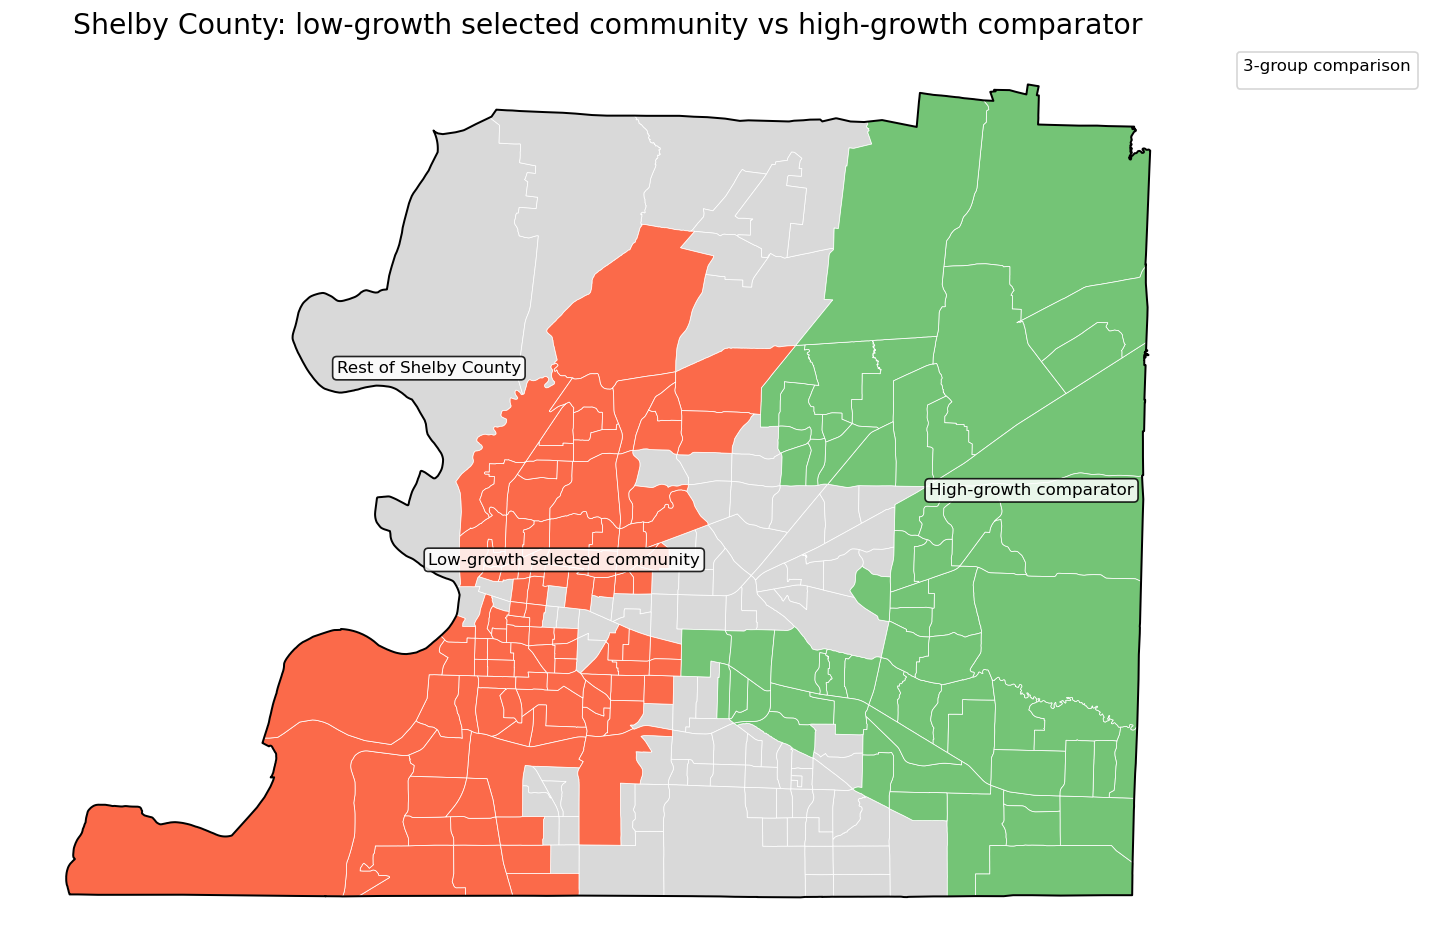

Saved: C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\shelby_three_group_map.png


In [195]:
# ============================================================
# Cell 8J — 3-group Shelby map
# Groups:
# 1) Selected low-growth community
# 2) Selected high-growth comparator
# 3) Rest of Shelby County excluding both
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

if "three_group_base" not in globals():
    raise ValueError("Run Cell 8I first so three_group_base exists.")

map_gdf = gpd.GeoDataFrame(three_group_base.copy(), geometry="geometry", crs=getattr(three_group_base, "crs", None))

if map_gdf.crs is not None:
    map_gdf = map_gdf.to_crs(3857)

group_order = [
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
    "Selected low-growth community",
]

color_map = {
    "Rest of Shelby County (excluding both selected communities)": "#d9d9d9",  # light gray
    "Selected high-growth comparator": "#74c476",  # green
    "Selected low-growth community": "#fb6a4a",    # red-orange
}

map_gdf["final_compare_group"] = pd.Categorical(
    map_gdf["final_compare_group"],
    categories=group_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot each group separately so colors stay controlled
for grp in group_order:
    sub = map_gdf.loc[map_gdf["final_compare_group"] == grp].copy()
    if not sub.empty:
        sub.plot(
            ax=ax,
            color=color_map[grp],
            edgecolor="white",
            linewidth=0.45,
            label=grp,
            zorder=2
        )

# Outer county outline
county_outline = map_gdf.dissolve()
county_outline.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)

# Add labels
label_shapes = map_gdf.dissolve(by="final_compare_group").reset_index()
label_shapes["label_pt"] = label_shapes.representative_point()

label_text_map = {
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-growth comparator",
    "Selected low-growth community": "Low-growth selected community",
}

for _, row in label_shapes.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    label = label_text_map.get(row["final_compare_group"], row["final_compare_group"])
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.85),
        zorder=4
    )

ax.set_title("Shelby County: low-growth selected community vs high-growth comparator", fontsize=17)
ax.set_axis_off()
ax.legend(title="3-group comparison", loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)

plt.tight_layout()
plt.show()

map_path = OUT_DIR / "shelby_three_group_map.png"
fig.savefig(map_path, bbox_inches="tight", dpi=220)
print("Saved:", map_path)


### Cell 8K — 3-group bar chart for IGS / economic metrics

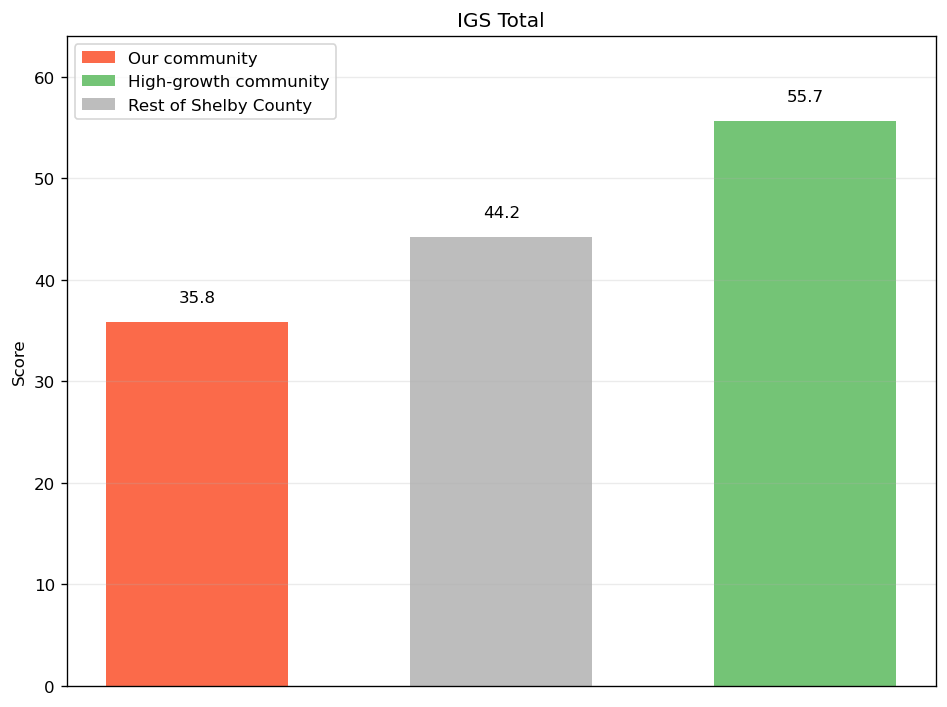

Saved: data\processed\presentation_ready\shelby_three_group_igs_total_recovery_individual.png


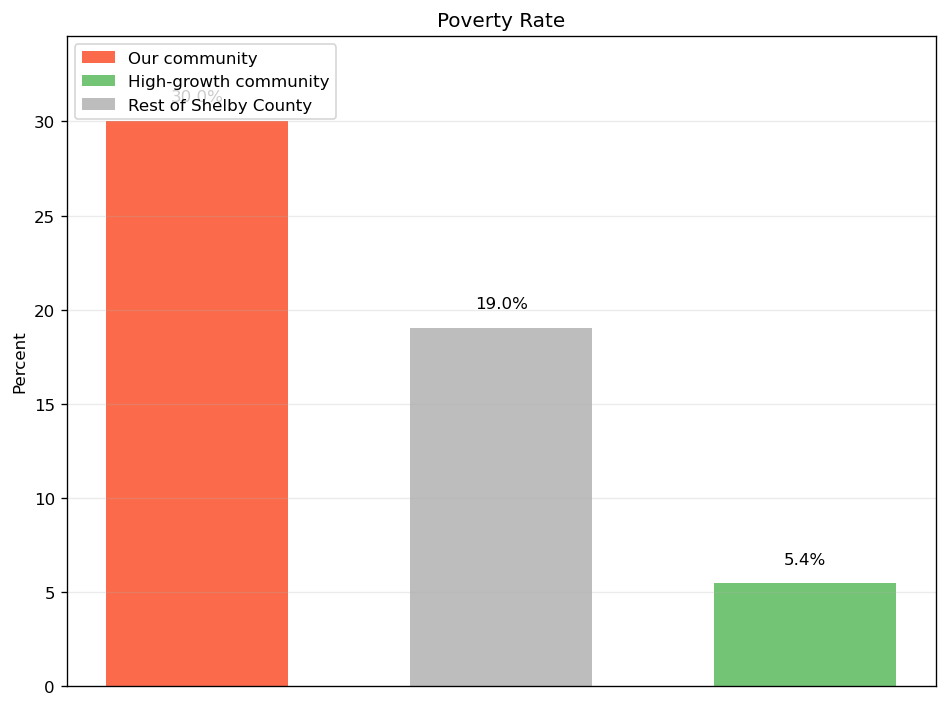

Saved: data\processed\presentation_ready\shelby_three_group_poverty_rate_recovery_individual.png


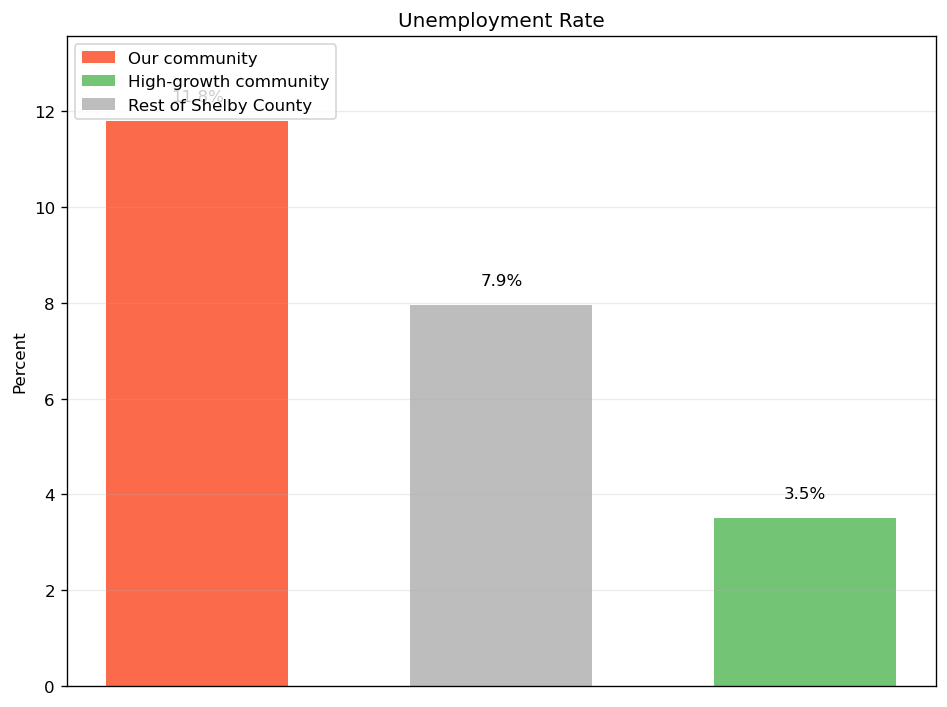

Saved: data\processed\presentation_ready\shelby_three_group_unemp_rate_recovery_individual.png


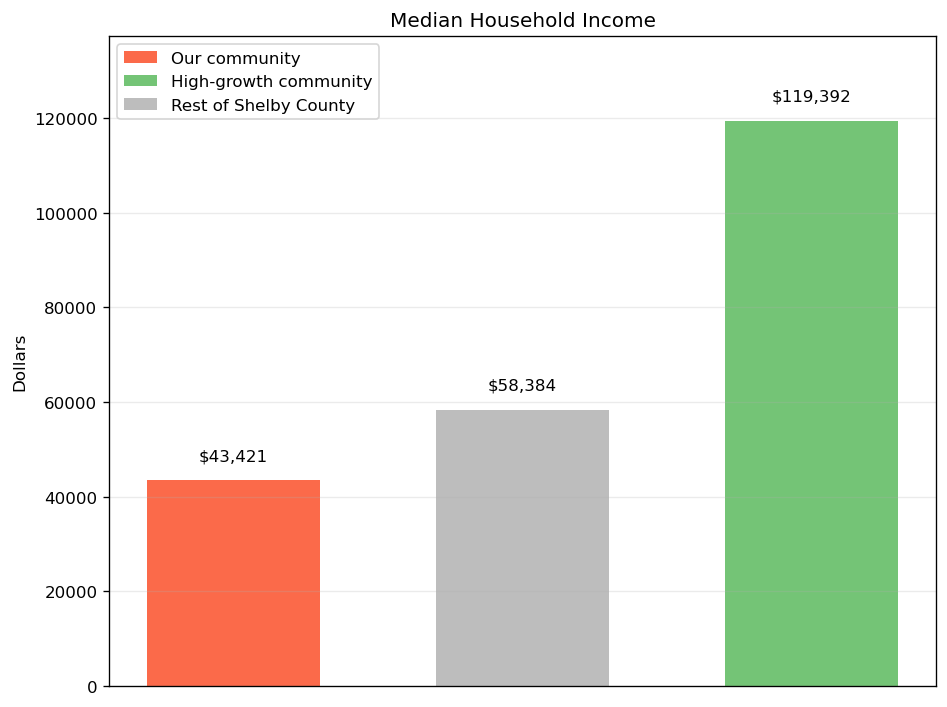

Saved: data\processed\presentation_ready\shelby_three_group_median_household_income_recovery_individual.png


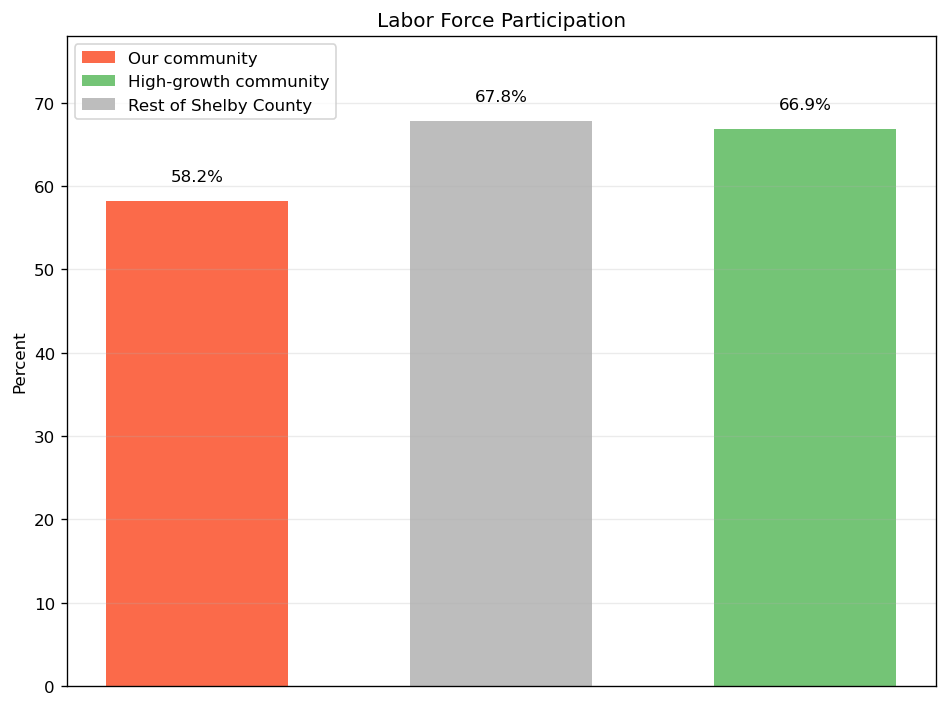

Saved: data\processed\presentation_ready\shelby_three_group_lfpr_16p_recovery_individual.png


In [216]:
# ============================================================
# Cell 8K — individual 3-group comparison charts for IGS/economic metrics
# Updated:
# - one chart per metric
# - removes x-axis labels/ticks
# - keeps legend/key
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

if "three_group_compare" not in globals():
    raise ValueError("Run Cell 8I first so three_group_compare exists.")

plot_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

colors = {
    "Selected low-growth community": "#fb6a4a",
    "Rest of Shelby County (excluding both selected communities)": "#bdbdbd",
    "Selected high-growth comparator": "#74c476",
}

metric_specs = {
    "igs_total_recovery": {
        "label": "IGS Total",
        "mult": 1,
        "fmt": lambda v: f"{v:.1f}",
        "ylabel": "Score"
    },
    "poverty_rate_recovery": {
        "label": "Poverty Rate",
        "mult": 100,
        "fmt": lambda v: f"{v:.1f}%",
        "ylabel": "Percent"
    },
    "unemp_rate_recovery": {
        "label": "Unemployment Rate",
        "mult": 100,
        "fmt": lambda v: f"{v:.1f}%",
        "ylabel": "Percent"
    },
    "median_household_income_recovery": {
        "label": "Median Household Income",
        "mult": 1,
        "fmt": lambda v: f"${v:,.0f}",
        "ylabel": "Dollars"
    },
    "lfpr_16p_recovery": {
        "label": "Labor Force Participation",
        "mult": 100,
        "fmt": lambda v: f"{v:.1f}%",
        "ylabel": "Percent"
    },
}

legend_handles = [
    Patch(facecolor=colors["Selected low-growth community"], label="Our community"),
    Patch(facecolor=colors["Selected high-growth comparator"], label="High-growth community"),
    Patch(facecolor=colors["Rest of Shelby County (excluding both selected communities)"], label="Rest of Shelby County"),
]

for metric, spec in metric_specs.items():
    if metric not in three_group_compare.columns:
        continue

    plot_df = (
        three_group_compare
        .set_index("group")
        .loc[plot_order, [metric]]
        .copy()
    )

    vals = plot_df[metric].astype(float) * spec["mult"]
    x = np.arange(len(plot_order))

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(
        x,
        vals.values,
        color=[colors[g] for g in plot_order],
        width=0.6
    )

    ymax = np.nanmax(vals.values)
    pad = max(ymax * 0.03, 0.3)

    for bar, val in zip(bars, vals.values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad,
                spec["fmt"](val),
                ha="center",
                va="bottom",
                fontsize=10
            )

    # Remove x-axis completely
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(axis="x", length=0)

    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["label"])
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

    ax.legend(handles=legend_handles, frameon=True, loc="upper left")

    plt.tight_layout()
    plt.show()

    out_path = OUT_DIR / f"shelby_three_group_{metric}_individual.png"
    fig.savefig(out_path, bbox_inches="tight", dpi=220)
    print("Saved:", out_path)


### Cell 8L — helper for 3-group health charts

In [222]:
# ============================================================
# Cell 8L — helper for individual 3-group health charts
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

if "three_group_compare" not in globals():
    raise ValueError("Run Cell 8I first so three_group_compare exists.")

plot_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

health_colors = {
    "Selected low-growth community": "#fb6a4a",
    "Rest of Shelby County (excluding both selected communities)": "#bdbdbd",
    "Selected high-growth comparator": "#74c476",
}

health_legend_handles = [
    Patch(facecolor=health_colors["Selected low-growth community"], label="Our community"),
    Patch(facecolor=health_colors["Selected high-growth comparator"], label="High-growth community"),
    Patch(facecolor=health_colors["Rest of Shelby County (excluding both selected communities)"], label="Rest of Shelby County"),
]

def plot_three_group_metric(
    df,
    metric,
    title,
    ylabel="Percent",
    fmt_func=None,
    filename=None,
    footnote=None
):
    if metric not in df.columns:
        print(f"Skipping {metric}: not found in three_group_compare.")
        return

    plot_df = (
        df.set_index("group")
          .loc[plot_order, [metric]]
          .copy()
    )

    vals = pd.to_numeric(plot_df[metric], errors="coerce")
    x = np.arange(len(plot_order))

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(
        x,
        vals.values,
        color=[health_colors[g] for g in plot_order],
        width=0.6
    )

    ymax = np.nanmax(vals.values)
    if not np.isfinite(ymax):
        ymax = 1.0
    pad = max(ymax * 0.03, 0.3)

    if fmt_func is None:
        fmt_func = lambda v: f"{v:.1f}%"

    for bar, val in zip(bars, vals.values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad,
                fmt_func(val),
                ha="center",
                va="bottom",
                fontsize=10
            )

    # remove x-axis labels/ticks
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(axis="x", length=0)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

    ax.legend(handles=health_legend_handles, frameon=True, loc="upper left")

    if footnote:
        fig.text(0.02, 0.02, footnote, fontsize=9)

    plt.tight_layout(rect=[0, 0.04 if footnote else 0, 1, 1])
    plt.show()

    if filename:
        out_path = OUT_DIR / filename
        fig.savefig(out_path, bbox_inches="tight", dpi=220)
        print("Saved:", out_path)


### Cell 8M — summary health proxy visuals

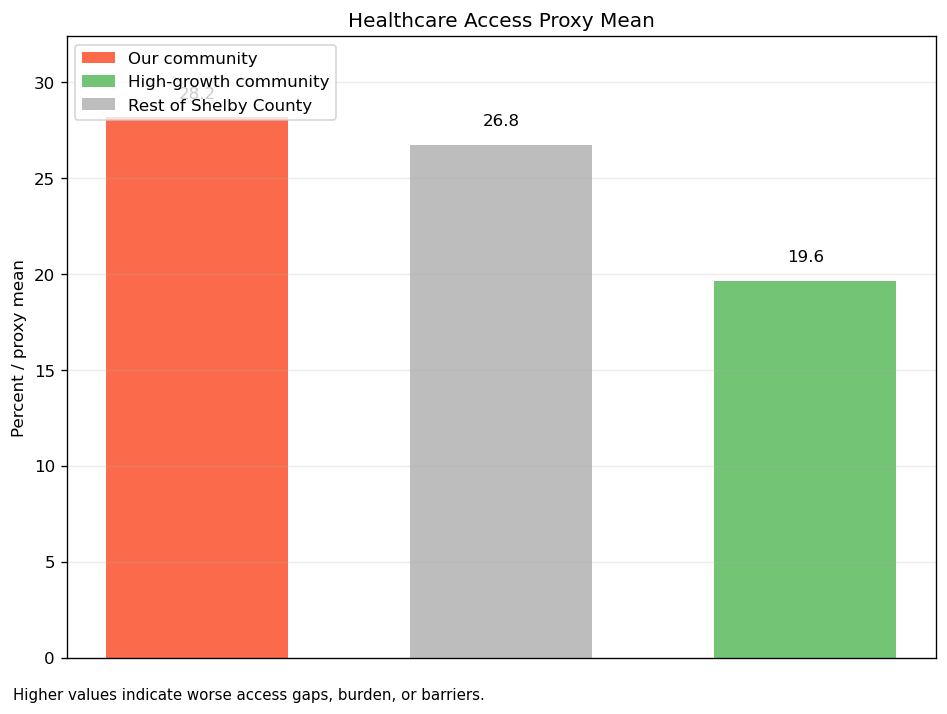

Saved: data\processed\presentation_ready\three_group_access_proxy_mean_pct.png


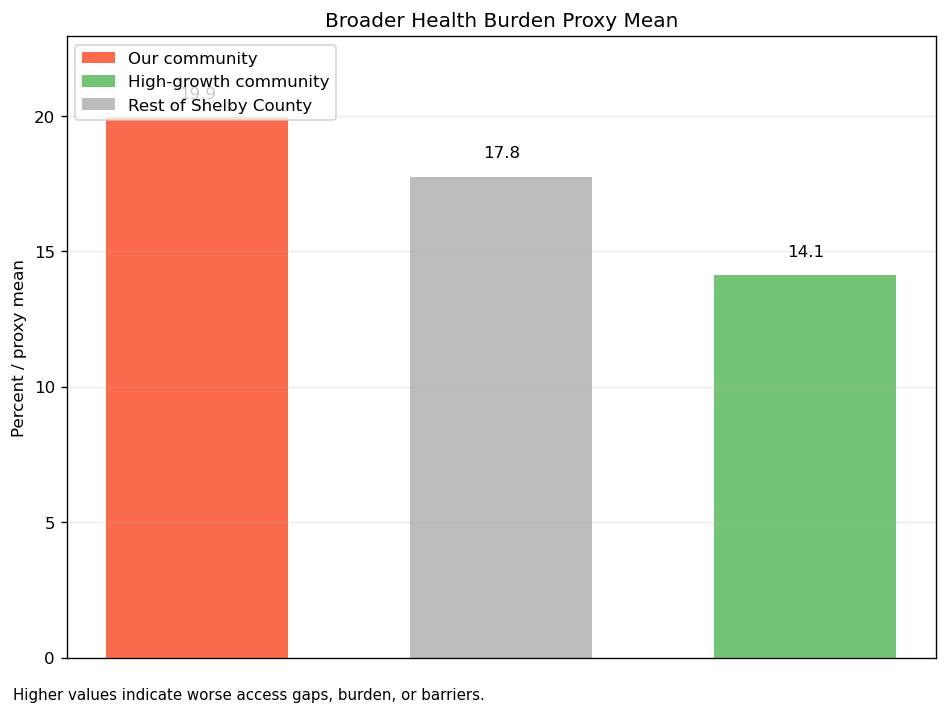

Saved: data\processed\presentation_ready\three_group_burden_proxy_mean_pct.png


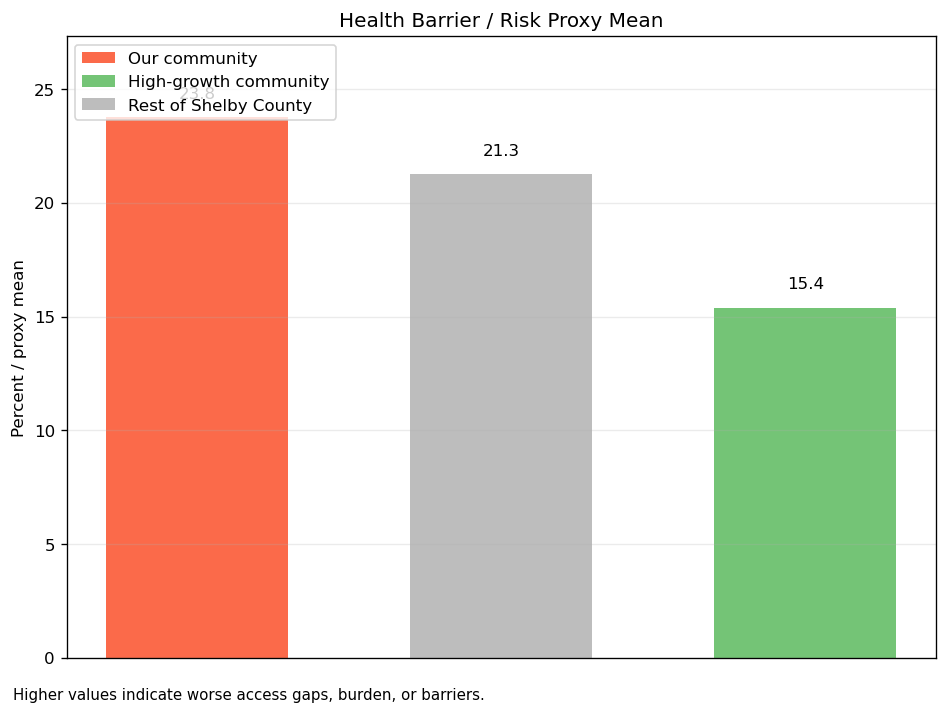

Saved: data\processed\presentation_ready\three_group_barrier_proxy_mean_pct.png


In [223]:
# ============================================================
# Cell 8M — 3-group summary health proxy visuals
# Higher = worse
# ============================================================

summary_health_specs = {
    "access_proxy_mean_pct": {
        "title": "Healthcare Access Proxy Mean",
        "ylabel": "Percent / proxy mean"
    },
    "burden_proxy_mean_pct": {
        "title": "Broader Health Burden Proxy Mean",
        "ylabel": "Percent / proxy mean"
    },
    "barrier_proxy_mean_pct": {
        "title": "Health Barrier / Risk Proxy Mean",
        "ylabel": "Percent / proxy mean"
    },
}

for metric, spec in summary_health_specs.items():
    if metric in three_group_compare.columns:
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=spec["title"],
            ylabel=spec["ylabel"],
            fmt_func=lambda v: f"{v:.1f}",
            filename=f"three_group_{metric}.png",
            footnote="Higher values indicate worse access gaps, burden, or barriers."
        )


### Cell 8N — detailed healthcare access / prevention visuals

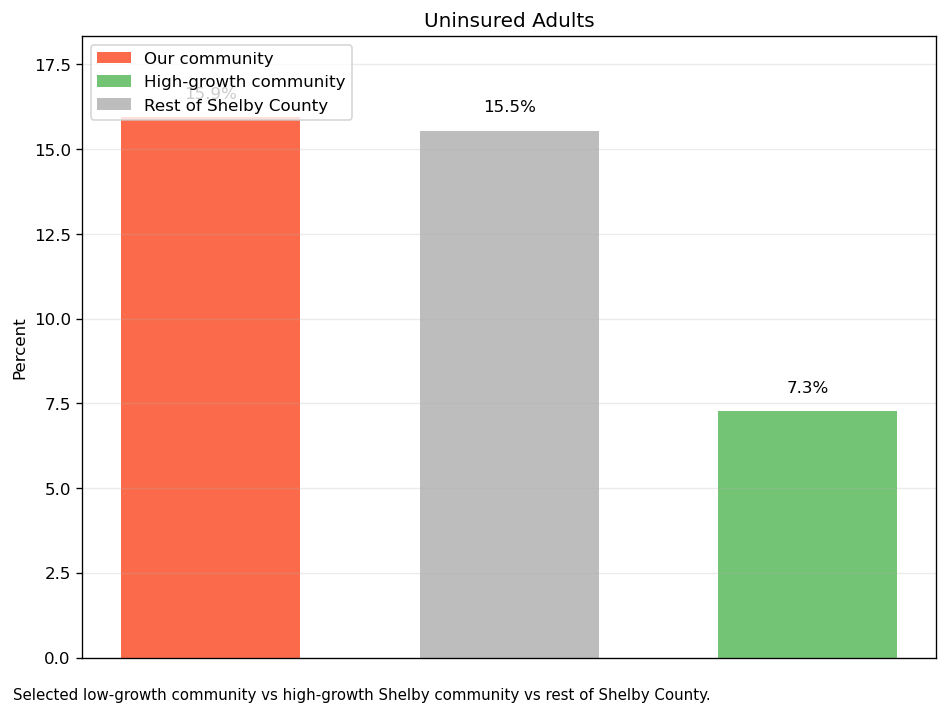

Saved: data\processed\presentation_ready\three_group_uninsured_adults_pct.png


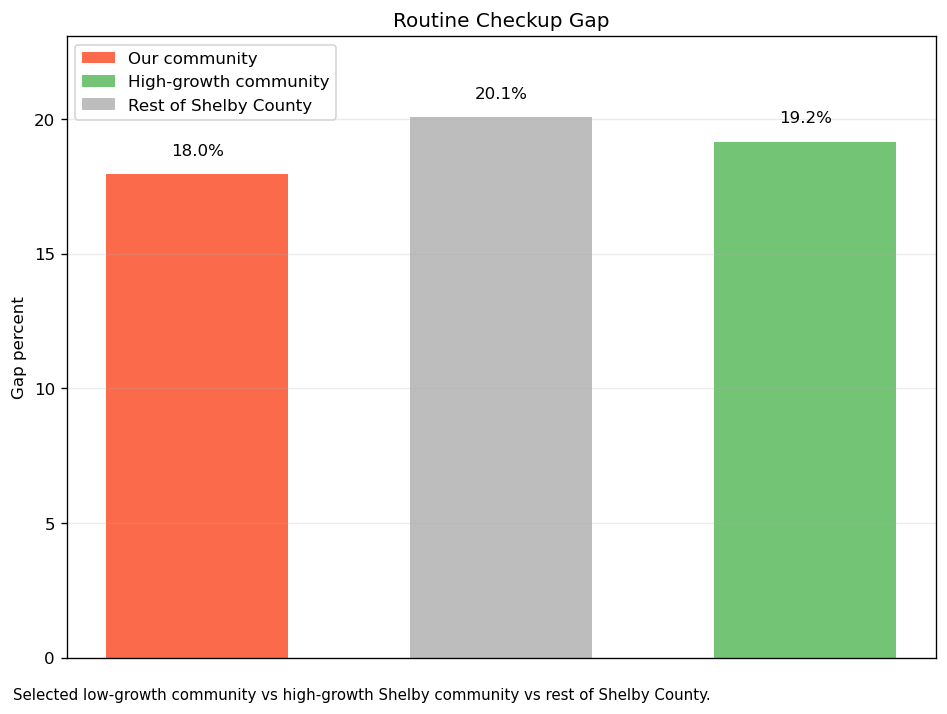

Saved: data\processed\presentation_ready\three_group_routine_checkup_gap_pct.png


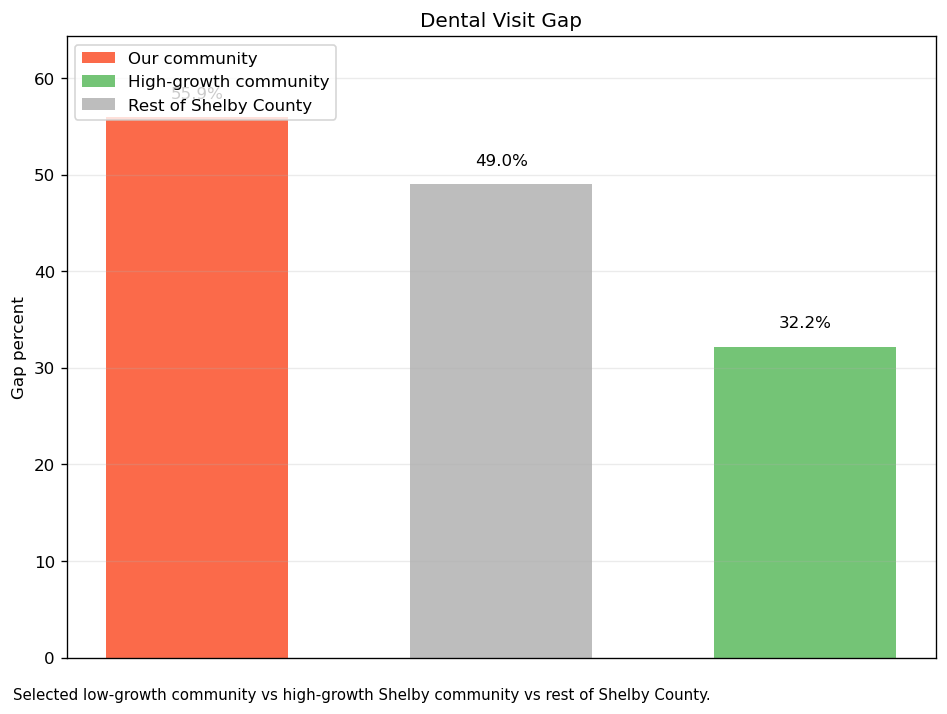

Saved: data\processed\presentation_ready\three_group_dental_visit_gap_pct.png


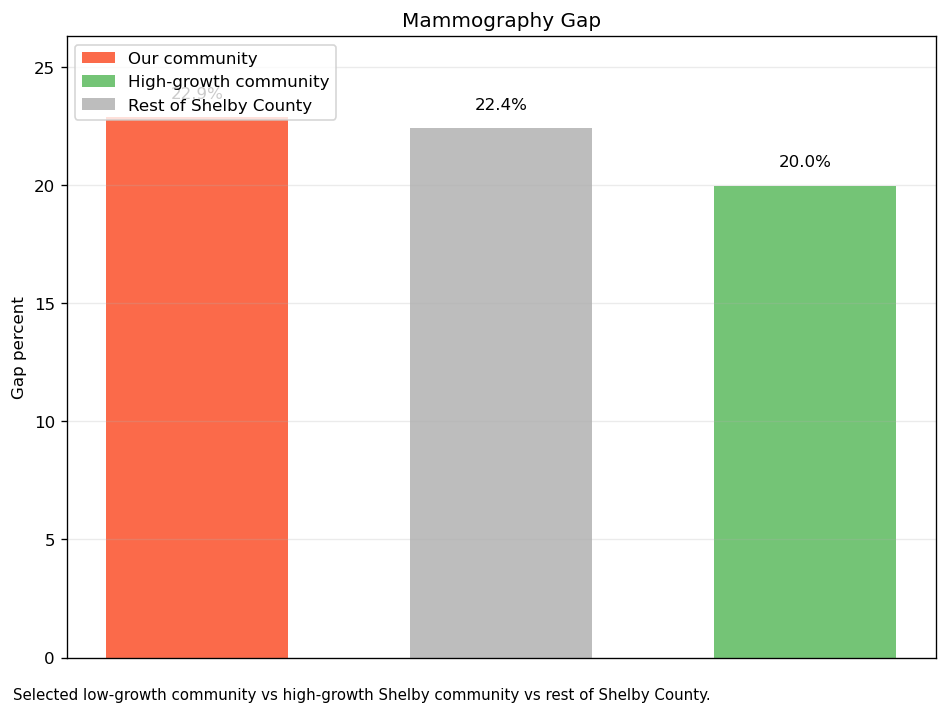

Saved: data\processed\presentation_ready\three_group_mammography_gap_pct.png


In [219]:
# ============================================================
# Cell 8N — detailed 3-group healthcare access / prevention visuals
# Higher = worse for all gap metrics
# ============================================================

access_specs = {
    "uninsured_adults_pct": {
        "title": "Uninsured Adults",
        "ylabel": "Percent"
    },
    "routine_checkup_gap_pct": {
        "title": "Routine Checkup Gap",
        "ylabel": "Gap percent"
    },
    "dental_visit_gap_pct": {
        "title": "Dental Visit Gap",
        "ylabel": "Gap percent"
    },
    "mammography_gap_pct": {
        "title": "Mammography Gap",
        "ylabel": "Gap percent"
    },
    "flu_vax_gap_pct": {
        "title": "Influenza Vaccination Gap",
        "ylabel": "Gap percent"
    },
}

for metric, spec in access_specs.items():
    if metric in three_group_compare.columns and three_group_compare[metric].notna().any():
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=spec["title"],
            ylabel=spec["ylabel"],
            fmt_func=lambda v: f"{v:.1f}%",
            filename=f"three_group_{metric}.png",
            footnote="Selected low-growth community vs high-growth Shelby community vs rest of Shelby County."
        )


### Cell 8O — detailed broader health burden visuals

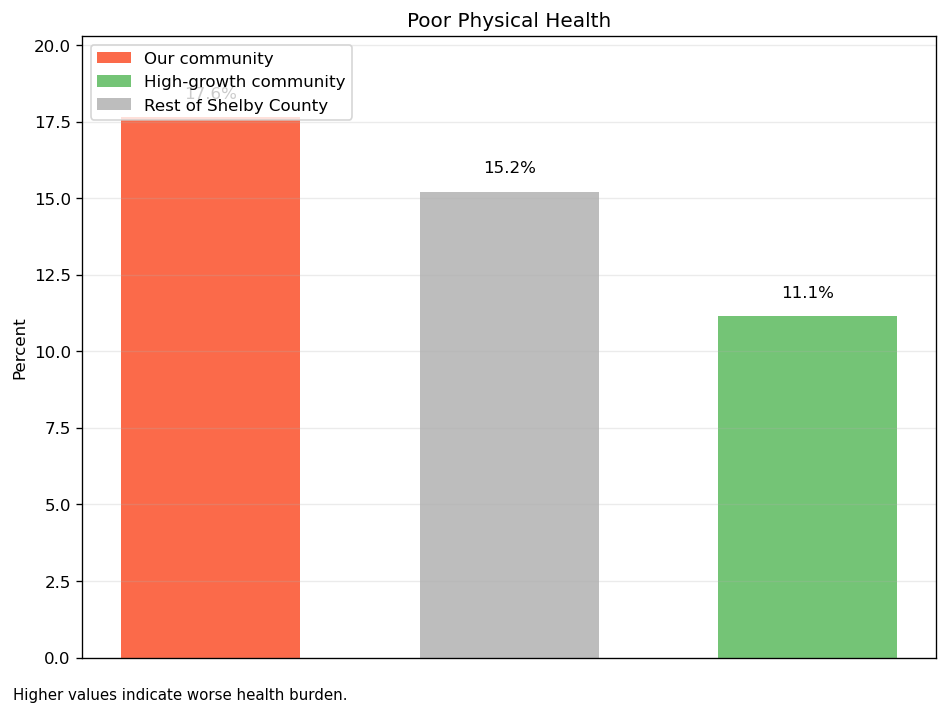

Saved: data\processed\presentation_ready\three_group_poor_physical_health_pct.png


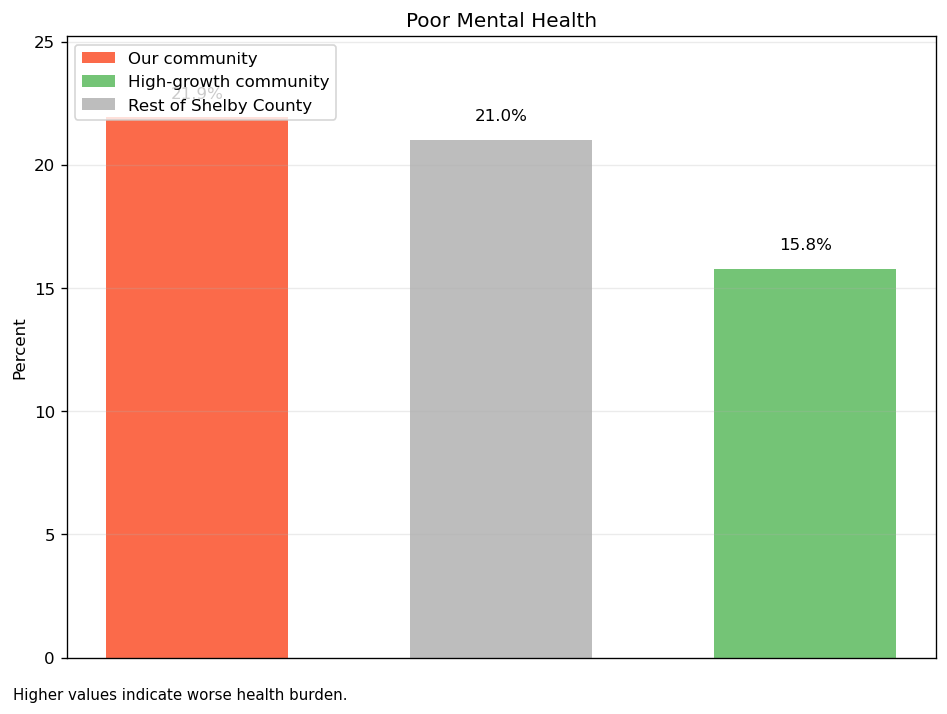

Saved: data\processed\presentation_ready\three_group_poor_mental_health_pct.png


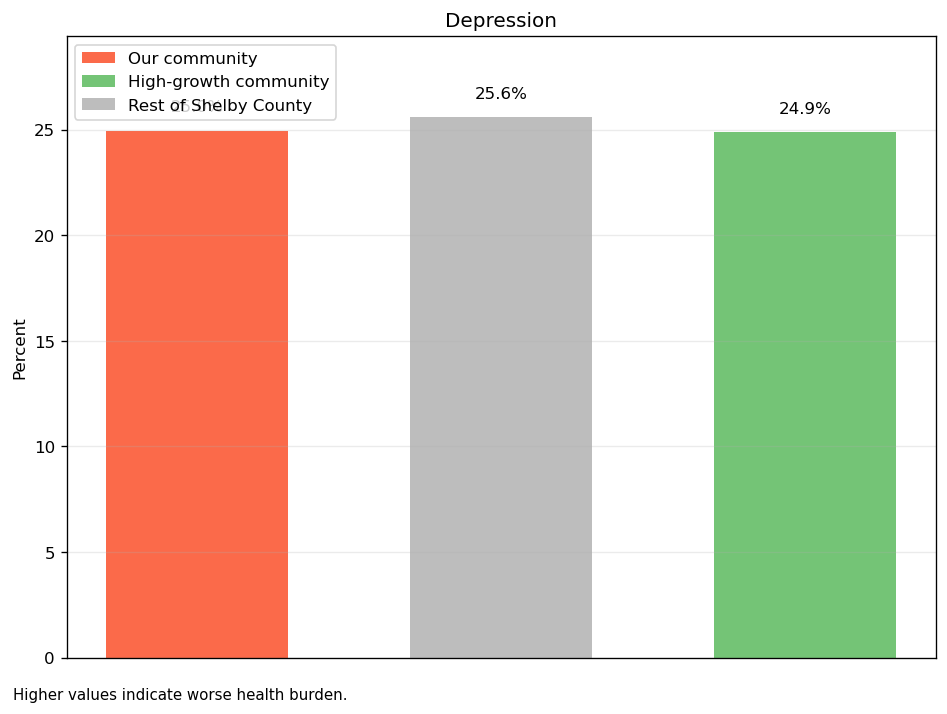

Saved: data\processed\presentation_ready\three_group_depression_pct.png


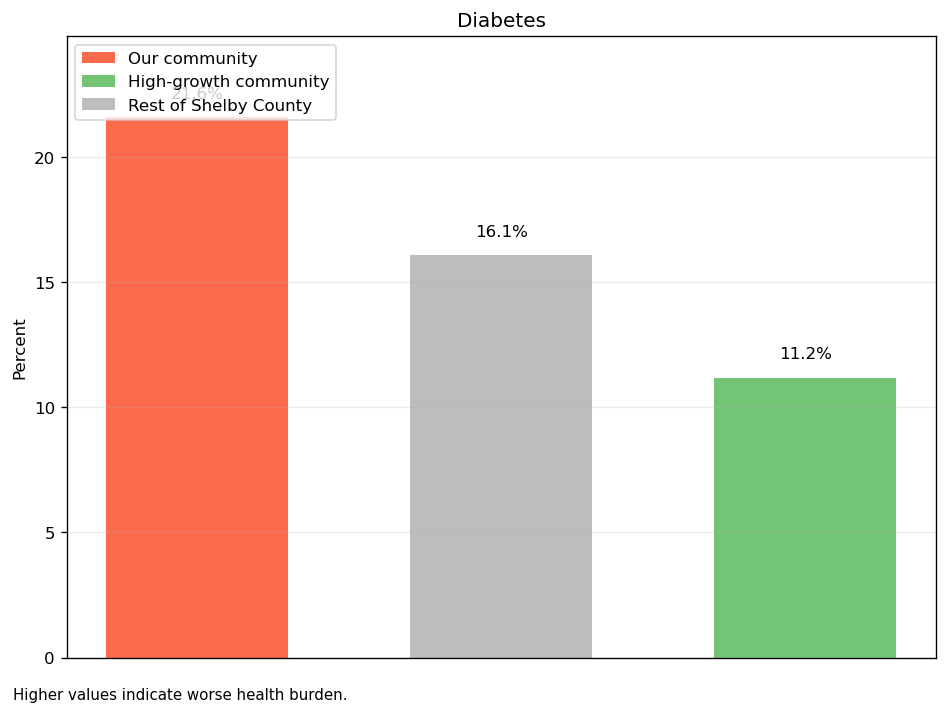

Saved: data\processed\presentation_ready\three_group_diabetes_pct.png


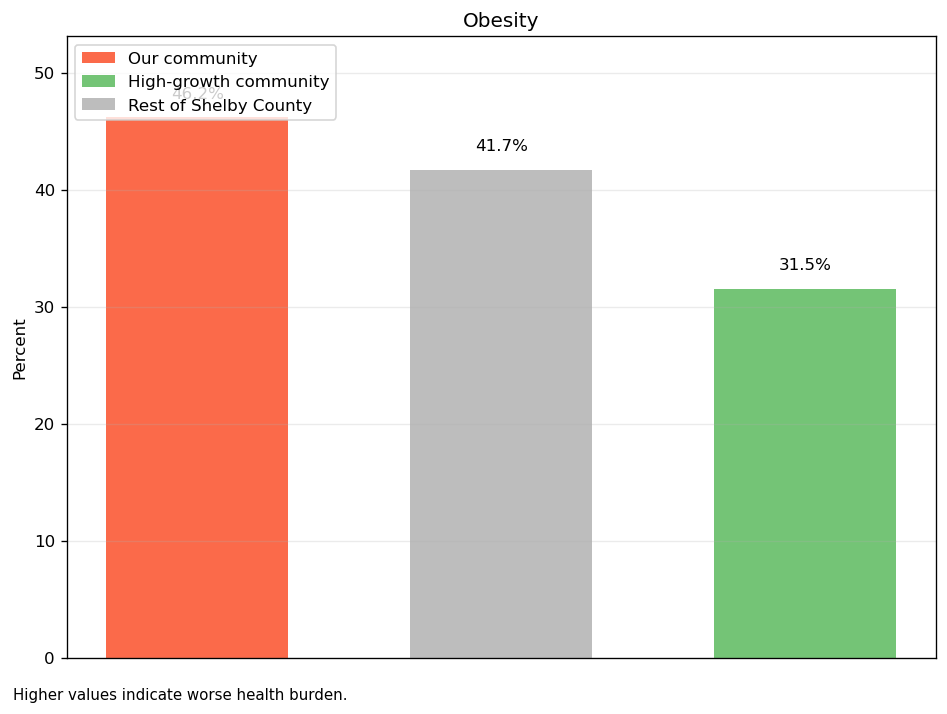

Saved: data\processed\presentation_ready\three_group_obesity_pct.png


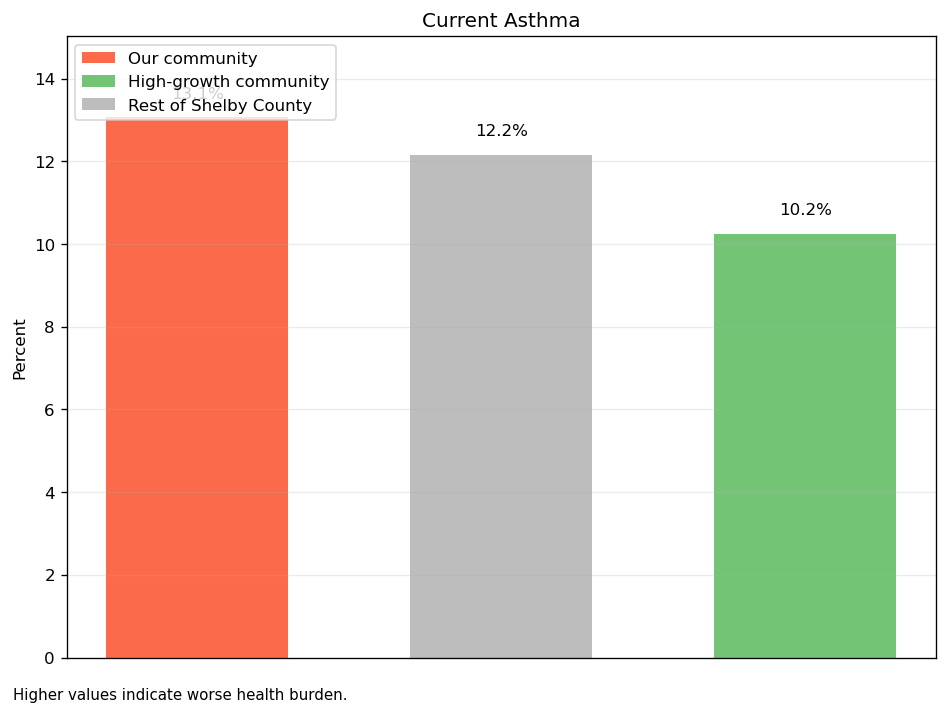

Saved: data\processed\presentation_ready\three_group_current_asthma_pct.png


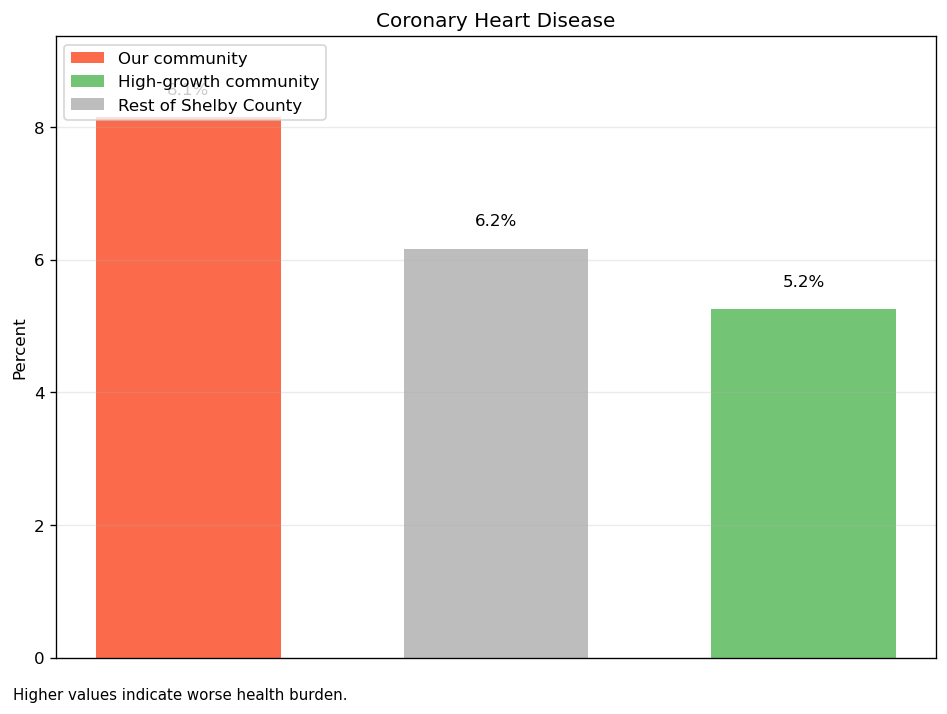

Saved: data\processed\presentation_ready\three_group_coronary_heart_disease_pct.png


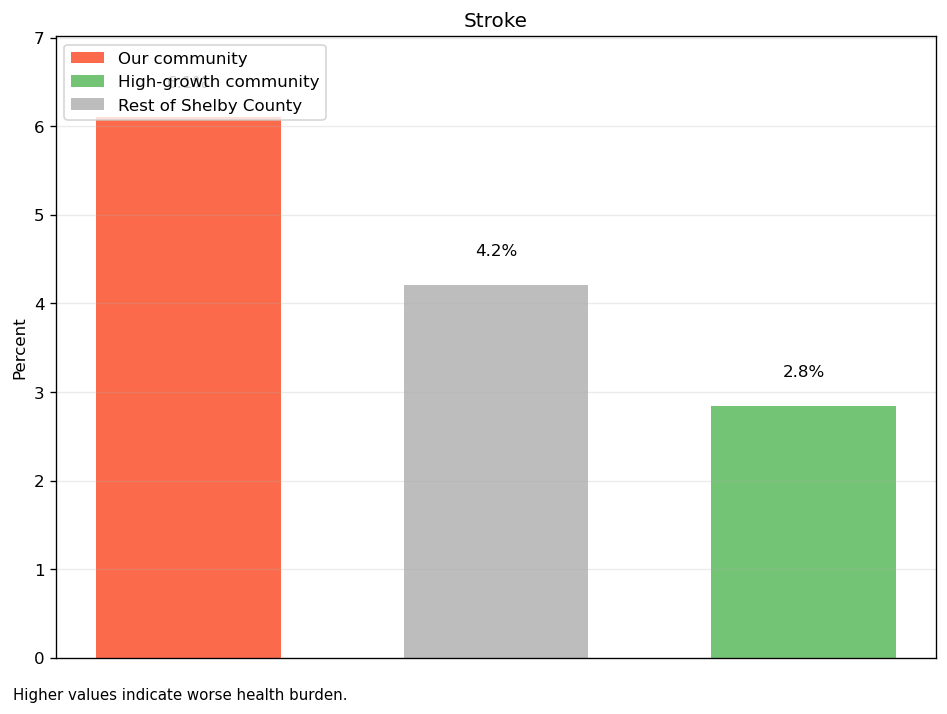

Saved: data\processed\presentation_ready\three_group_stroke_pct.png


In [220]:
# ============================================================
# Cell 8O — detailed 3-group broader health burden visuals
# Higher = worse
# ============================================================

burden_specs = {
    "fair_poor_health_pct": "Poor / Fair Health",
    "poor_physical_health_pct": "Poor Physical Health",
    "poor_mental_health_pct": "Poor Mental Health",
    "depression_pct": "Depression",
    "diabetes_pct": "Diabetes",
    "obesity_pct": "Obesity",
    "current_asthma_pct": "Current Asthma",
    "coronary_heart_disease_pct": "Coronary Heart Disease",
    "stroke_pct": "Stroke",
}

for metric, title in burden_specs.items():
    if metric in three_group_compare.columns and three_group_compare[metric].notna().any():
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=title,
            ylabel="Percent",
            fmt_func=lambda v: f"{v:.1f}%",
            filename=f"three_group_{metric}.png",
            footnote="Higher values indicate worse health burden."
        )


### Cell 8P — detailed barriers / risk visuals

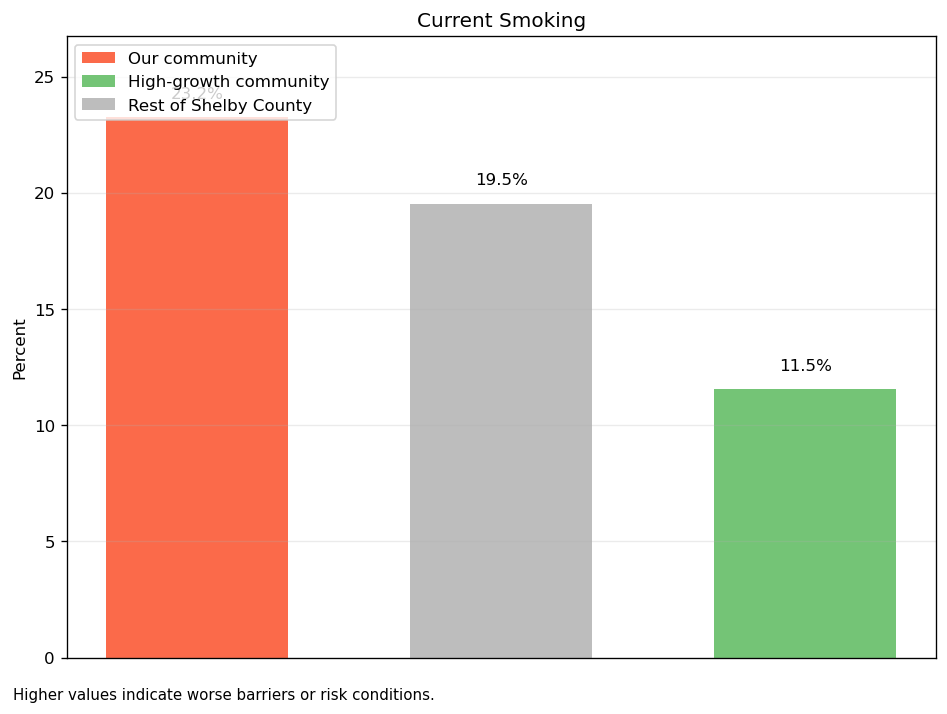

Saved: data\processed\presentation_ready\three_group_smoking_pct.png


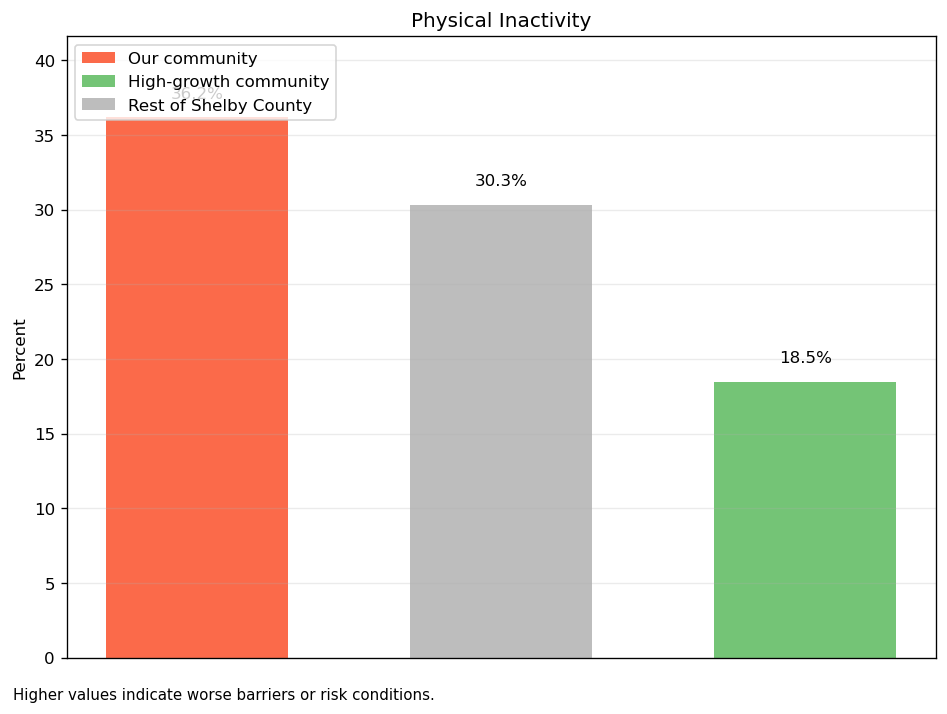

Saved: data\processed\presentation_ready\three_group_physical_inactivity_pct.png


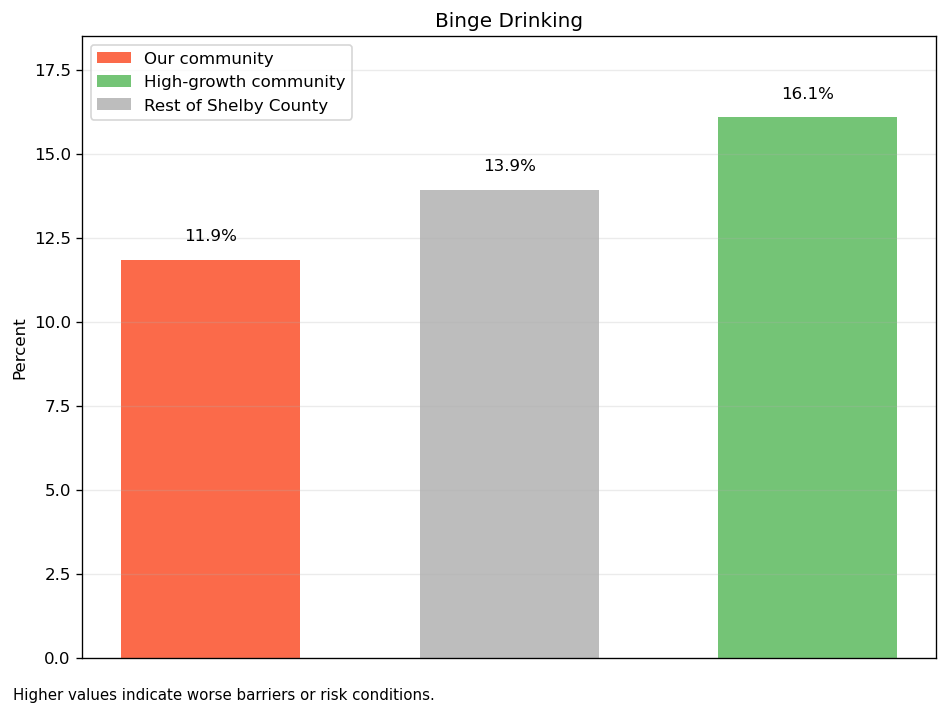

Saved: data\processed\presentation_ready\three_group_binge_drinking_pct.png


In [221]:
# ============================================================
# Cell 8P — detailed 3-group barriers / risk visuals
# Higher = worse
# ============================================================

barrier_specs = {
    "smoking_pct": "Current Smoking",
    "physical_inactivity_pct": "Physical Inactivity",
    "binge_drinking_pct": "Binge Drinking",
    "sleep_lt7_pct": "Sleeping Less Than 7 Hours",
    "food_insecurity_pct": "Food Insecurity",
    "housing_insecurity_pct": "Housing Insecurity",
    "transportation_barriers_pct": "Transportation Barriers",
    "social_isolation_pct": "Social Isolation",
}

for metric, title in barrier_specs.items():
    if metric in three_group_compare.columns and three_group_compare[metric].notna().any():
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=title,
            ylabel="Percent",
            fmt_func=lambda v: f"{v:.1f}%",
            filename=f"three_group_{metric}.png",
            footnote="Higher values indicate worse barriers or risk conditions."
        )


### Cell 7 — load County Health Rankings 2023 healthcare data from analytic_data2023_0.csv


In [197]:
# # Cell 7 — load and join multi-year County Health Rankings healthcare data (2017–2023)

# from pathlib import Path
# import pandas as pd
# import numpy as np

# HEALTHCARE_DIR = RAW_DIR / "healthcare"
# HEALTHCARE_DIR.mkdir(parents=True, exist_ok=True)

# # Only load actual County Health Rankings analytic files
# healthcare_files = sorted(HEALTHCARE_DIR.glob("analytic_data*.csv"))

# if len(healthcare_files) == 0:
#     raise FileNotFoundError(
#         f"No County Health Rankings analytic_data*.csv files found in {HEALTHCARE_DIR}"
#     )

# print("Healthcare files found:")
# for p in healthcare_files:
#     print("-", p.name)

# # --------------------------------------------------
# # A. Helpers
# # --------------------------------------------------
# def normalize_county_fips(series):
#     s = series.astype("string").str.strip()
#     s = s.str.replace(r"\.0$", "", regex=True)
#     s = s.str.replace(r"\D", "", regex=True)
#     s = s.str.zfill(5)
#     return s.where(s.str.fullmatch(r"\d{5}"), pd.NA)

# def find_first_matching_column(df, candidates):
#     for c in candidates:
#         if c in df.columns:
#             return c
#     return None

# def find_first_startswith_column(df, prefixes):
#     lowered = {str(c).strip().lower(): c for c in df.columns}
#     for prefix in prefixes:
#         prefix_l = str(prefix).strip().lower()
#         for col_l, original_col in lowered.items():
#             if col_l.startswith(prefix_l):
#                 return original_col
#     return None

# def standardize_chr_file(chr_raw, source_name):
#     chr_df = chr_raw.copy()

#     fips_col = find_first_matching_column(chr_df, [
#         "5-digit FIPS Code",
#         "5 digit FIPS Code",
#         "5-digit FIPS code",
#         "FIPS Code",
#     ])
#     if fips_col is None:
#         raise ValueError(f"{source_name}: could not find county FIPS column")

#     year_col = find_first_matching_column(chr_df, [
#         "Release Year",
#         "release year",
#         "Year",
#     ])

#     state_col = find_first_matching_column(chr_df, [
#         "State Abbreviation",
#         "State",
#     ])

#     name_col = find_first_matching_column(chr_df, [
#         "Name",
#         "County",
#     ])

#     chr_df["county_fips"] = normalize_county_fips(chr_df[fips_col])

#     if year_col is not None:
#         chr_df["year"] = pd.to_numeric(chr_df[year_col], errors="coerce").astype("Int64")
#     else:
#         chr_df["year"] = pd.NA

#     chr_df["chr_state"] = chr_df[state_col].astype("string") if state_col is not None else pd.NA
#     chr_df["chr_county"] = chr_df[name_col].astype("string") if name_col is not None else pd.NA

#     health_measure_candidates = {
#         "uninsured_rate": ["Uninsured raw value"],
#         "uninsured_adults_rate": ["Uninsured Adults raw value"],
#         "uninsured_children_rate": ["Uninsured Children raw value"],
#         "primary_care_physicians_rate": ["Primary Care Physicians raw value"],
#         "dentists_rate": ["Dentists raw value"],
#         "mental_health_providers_rate": ["Mental Health Providers raw value"],
#         "other_primary_care_providers_rate": ["Other Primary Care Providers raw value"],
#         "preventable_hospital_stays_rate": ["Preventable Hospital Stays raw value"],
#         "mammography_screening_rate": ["Mammography Screening raw value"],
#         "flu_vaccinations_rate": ["Flu Vaccinations raw value"],
#     }

#     resolved_measure_cols = {}

#     for clean_name, candidates in health_measure_candidates.items():
#         exact_col = find_first_matching_column(chr_df, candidates)
#         if exact_col is not None:
#             resolved_measure_cols[exact_col] = clean_name
#             continue

#         prefix_col = find_first_startswith_column(chr_df, candidates)
#         if prefix_col is not None:
#             resolved_measure_cols[prefix_col] = clean_name

#     if len(resolved_measure_cols) == 0:
#         possible_cols = [c for c in chr_df.columns if "raw value" in str(c).lower()]
#         raise ValueError(
#             f"{source_name}: could not find expected healthcare measure columns.\n"
#             f"Example raw-value columns: {possible_cols[:25]}"
#         )

#     keep_cols = ["county_fips", "year", "chr_state", "chr_county"] + list(resolved_measure_cols.keys())

#     out = (
#         chr_df[keep_cols]
#         .copy()
#         .rename(columns=resolved_measure_cols)
#     )

#     for col in out.columns:
#         if col in ["county_fips", "year", "chr_state", "chr_county"]:
#             continue
#         out[col] = pd.to_numeric(out[col], errors="coerce")

#     out["source_file"] = source_name

#     out = (
#         out
#         .dropna(subset=["county_fips", "year"])
#         .reset_index(drop=True)
#     )

#     return out

# # --------------------------------------------------
# # B. Load and standardize all CHR files
# # --------------------------------------------------
# healthcare_frames = []

# for fp in healthcare_files:
#     try:
#         df_raw = pd.read_csv(fp, low_memory=False)
#         # print (df_raw)
#         df_std = standardize_chr_file(df_raw, fp.name)
#         healthcare_frames.append(df_std)
#         print(f"Loaded {fp.name}: {df_std.shape}")
#     except Exception as e:
#         print(f"Skipped {fp.name}: {e}")

# if len(healthcare_frames) == 0:
#     raise RuntimeError("No healthcare CSVs could be standardized successfully.")

# healthcare_standardized = pd.concat(healthcare_frames, ignore_index=True)

# # Drop U.S. total and state rollup rows
# healthcare_standardized = healthcare_standardized.loc[
#     healthcare_standardized["county_fips"].notna()
#     & (healthcare_standardized["county_fips"] != "00000")
#     & (~healthcare_standardized["county_fips"].astype(str).str.endswith("000"))
# ].copy()

# # Keep the last-loaded version if a county-year repeats
# healthcare_standardized = (
#     healthcare_standardized
#     .sort_values(["county_fips", "year", "source_file"])
#     .drop_duplicates(subset=["county_fips", "year"], keep="last")
#     .reset_index(drop=True)
# )

# healthcare_join_level = "county"

# healthcare_metric_cols = [
#     c for c in healthcare_standardized.columns
#     if c not in ["county_fips", "year", "chr_state", "chr_county", "source_file"]
# ]

# available_healthcare_years = sorted(
#     healthcare_standardized["year"].dropna().astype(int).unique().tolist()
# )

# print("\nCombined healthcare shape:", healthcare_standardized.shape)
# print("Available healthcare years:", available_healthcare_years)
# print("Healthcare metric cols:", healthcare_metric_cols)

# # --------------------------------------------------
# # C. Validate enrichment inputs from Cell 6
# # --------------------------------------------------
# if "enrichment_clusters" not in globals() or len(enrichment_clusters) == 0:
#     raise ValueError("enrichment_clusters is empty or missing. Rerun Cell 6 first.")

# if "enrichment_tract_year_panel" not in globals() or len(enrichment_tract_year_panel) == 0:
#     raise ValueError("enrichment_tract_year_panel is empty or missing. Rerun Cell 6 first.")

# if "enrichment_cluster_year_panel" not in globals() or len(enrichment_cluster_year_panel) == 0:
#     raise ValueError("enrichment_cluster_year_panel is empty or missing. Rerun Cell 6 first.")

# # --------------------------------------------------
# # D. Build YEAR-SPECIFIC county weights from shortlisted clusters
# # FIX:
# # - use actual year-specific tract populations
# # - sum tract populations to county-year totals
# # - compute county share within cluster-year
# # --------------------------------------------------
# cluster_county_weights = (
#     enrichment_tract_year_panel[
#         ["cluster_id", "year", "geoid", "pop_total"]
#     ]
#     .copy()
# )

# cluster_county_weights["geoid"] = cluster_county_weights["geoid"].astype("string")
# cluster_county_weights["county_fips"] = normalize_county_fips(
#     cluster_county_weights["geoid"].str[:5]
# )
# cluster_county_weights["pop_total"] = pd.to_numeric(
#     cluster_county_weights["pop_total"], errors="coerce"
# )

# cluster_county_weights = cluster_county_weights.loc[
#     cluster_county_weights["year"].isin(available_healthcare_years)
# ].copy()

# if len(cluster_county_weights) == 0:
#     raise ValueError("No tract-year rows remain after restricting to healthcare years.")

# cluster_county_weights = (
#     cluster_county_weights
#     .dropna(subset=["cluster_id", "year", "county_fips", "pop_total"])
#     .groupby(["cluster_id", "year", "county_fips"], as_index=False)
#     .agg(cluster_county_pop=("pop_total", "sum"))
# )

# cluster_county_weights["cluster_total_pop_for_weights"] = (
#     cluster_county_weights.groupby(["cluster_id", "year"])["cluster_county_pop"].transform("sum")
# )

# cluster_county_weights["cluster_county_weight"] = np.where(
#     cluster_county_weights["cluster_total_pop_for_weights"] > 0,
#     cluster_county_weights["cluster_county_pop"] / cluster_county_weights["cluster_total_pop_for_weights"],
#     np.nan
# )

# cluster_county_weight_panel = cluster_county_weights.copy()

# if len(cluster_county_weight_panel) == 0:
#     raise ValueError("cluster_county_weight_panel is empty after building year-specific weights.")

# # --------------------------------------------------
# # E. Coverage audit before join
# # --------------------------------------------------
# shortlist_fips = set(cluster_county_weight_panel["county_fips"].dropna().astype(str).unique())
# healthcare_fips = set(healthcare_standardized["county_fips"].dropna().astype(str).unique())
# overlap_fips = shortlist_fips & healthcare_fips

# print("\nCoverage audit:")
# print("Shortlist county_fips:", len(shortlist_fips))
# print("Healthcare county_fips:", len(healthcare_fips))
# print("Overlap county_fips:", len(overlap_fips))

# missing_fips = sorted(list(shortlist_fips - healthcare_fips))
# print("\nSample missing shortlist county_fips:")
# print(missing_fips[:25])

# healthcare_overlap_audit = pd.DataFrame({
#     "metric": [
#         "shortlist_county_fips",
#         "healthcare_county_fips",
#         "overlap_county_fips"
#     ],
#     "value": [
#         len(shortlist_fips),
#         len(healthcare_fips),
#         len(overlap_fips)
#     ]
# })

# # --------------------------------------------------
# # F. Join county healthcare into shortlisted clusters
# # --------------------------------------------------
# healthcare_county_joined = (
#     cluster_county_weight_panel
#     .merge(
#         healthcare_standardized,
#         on=["county_fips", "year"],
#         how="left",
#         indicator=True
#     )
#     .copy()
# )

# healthcare_county_joined["matched_chr_county_flag"] = healthcare_county_joined["_merge"].eq("both")
# healthcare_county_joined["county_has_any_healthcare_metric"] = (
#     healthcare_county_joined[healthcare_metric_cols].notna().any(axis=1)
# )

# print("\nJoin result:")
# print(healthcare_county_joined["_merge"].value_counts(dropna=False))

# unmatched_counties = (
#     healthcare_county_joined.loc[
#         healthcare_county_joined["_merge"] == "left_only",
#         ["cluster_id", "year", "county_fips"]
#     ]
#     .drop_duplicates()
#     .sort_values(["cluster_id", "year", "county_fips"])
#     .reset_index(drop=True)
# )

# print("\nUnmatched county-year examples:")
# print(unmatched_counties.head(25))

# # --------------------------------------------------
# # G. Aggregate county healthcare to cluster-year
# # --------------------------------------------------
# cluster_year_meta = (
#     enrichment_cluster_year_panel[
#         ["cluster_id", "year", "display_state", "display_county", "n_cluster_tracts", "cluster_pop_total"]
#     ]
#     .drop_duplicates(subset=["cluster_id", "year"])
#     .copy()
# )

# cluster_rows = []

# for (cluster_id, year), grp in healthcare_county_joined.groupby(["cluster_id", "year"], dropna=False):
#     row = {
#         "cluster_id": cluster_id,
#         "year": int(year) if pd.notna(year) else pd.NA,
#     }

#     meta = cluster_year_meta.loc[
#         (cluster_year_meta["cluster_id"] == cluster_id) &
#         (cluster_year_meta["year"] == year)
#     ]

#     if len(meta) > 0:
#         row["display_state"] = meta["display_state"].iloc[0]
#         row["display_county"] = meta["display_county"].iloc[0]
#         row["n_cluster_tracts"] = meta["n_cluster_tracts"].iloc[0]
#         row["cluster_pop_total"] = meta["cluster_pop_total"].iloc[0]
#     else:
#         row["display_state"] = pd.NA
#         row["display_county"] = pd.NA
#         row["n_cluster_tracts"] = pd.NA
#         row["cluster_pop_total"] = pd.NA

#     weights = pd.to_numeric(grp["cluster_county_weight"], errors="coerce")

#     row["cluster_county_count"] = grp["county_fips"].nunique()
#     row["matched_chr_county_count"] = grp.loc[grp["matched_chr_county_flag"], "county_fips"].nunique()
#     row["matched_chr_weight_share"] = grp.loc[
#         grp["matched_chr_county_flag"] & weights.notna(),
#         "cluster_county_weight"
#     ].sum()

#     row["any_metric_weight_share"] = grp.loc[
#         grp["county_has_any_healthcare_metric"] & weights.notna(),
#         "cluster_county_weight"
#     ].sum()

#     for col in healthcare_metric_cols:
#         values = pd.to_numeric(grp[col], errors="coerce")
#         mask = values.notna() & weights.notna() & (weights > 0)

#         if mask.sum() > 0:
#             row[col] = np.average(values.loc[mask], weights=weights.loc[mask])
#         elif values.notna().sum() > 0:
#             row[col] = values.mean()
#         else:
#             row[col] = np.nan

#     row["healthcare_any_data_flag"] = pd.Series(
#         [row.get(col, np.nan) for col in healthcare_metric_cols]
#     ).notna().any()

#     cluster_rows.append(row)

# if len(cluster_rows) == 0:
#     raise ValueError("No cluster-year rows were produced for healthcare aggregation.")

# healthcare_cluster_panel = (
#     pd.DataFrame(cluster_rows)
#     .sort_values(["cluster_id", "year"])
#     .reset_index(drop=True)
# )

# # Keep only clusters with actual healthcare data in summary
# if healthcare_cluster_panel["healthcare_any_data_flag"].any():
#     healthcare_cluster_summary = (
#         healthcare_cluster_panel
#         .loc[healthcare_cluster_panel["healthcare_any_data_flag"] == True]
#         .groupby("cluster_id", as_index=False)
#         .agg({
#             "display_state": "first",
#             "display_county": "first",
#             "n_cluster_tracts": "max",
#             "cluster_pop_total": "mean",
#             "cluster_county_count": "max",
#             "matched_chr_county_count": "max",
#             "matched_chr_weight_share": "mean",
#             "any_metric_weight_share": "mean",
#             "year": "nunique",
#             **{col: "mean" for col in healthcare_metric_cols}
#         })
#         .rename(columns={"year": "n_healthcare_years_with_any_data"})
#     )
# else:
#     healthcare_cluster_summary = pd.DataFrame(
#         columns=[
#             "cluster_id",
#             "display_state",
#             "display_county",
#             "n_cluster_tracts",
#             "cluster_pop_total",
#             "cluster_county_count",
#             "matched_chr_county_count",
#             "matched_chr_weight_share",
#             "any_metric_weight_share",
#             "n_healthcare_years_with_any_data",
#         ] + healthcare_metric_cols
#     )

# print("\nHealthcare cluster panel rows with any data:")
# print(healthcare_cluster_panel["healthcare_any_data_flag"].value_counts(dropna=False))
# print("Healthcare cluster summary shape:", healthcare_cluster_summary.shape)

# # --------------------------------------------------
# # H. Save outputs
# # --------------------------------------------------
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# healthcare_standardized.to_parquet(OUT_DIR / "healthcare_standardized.parquet", index=False)
# healthcare_county_joined.to_parquet(OUT_DIR / "healthcare_county_joined.parquet", index=False)
# healthcare_cluster_panel.to_parquet(OUT_DIR / "healthcare_cluster_panel.parquet", index=False)
# healthcare_cluster_summary.to_parquet(OUT_DIR / "healthcare_cluster_summary.parquet", index=False)
# unmatched_counties.to_parquet(OUT_DIR / "healthcare_unmatched_counties.parquet", index=False)
# healthcare_overlap_audit.to_csv(OUT_DIR / "healthcare_overlap_audit.csv", index=False)

# healthcare_standardized.to_csv(OUT_DIR / "healthcare_standardized.csv", index=False)
# healthcare_cluster_summary.to_csv(OUT_DIR / "healthcare_cluster_summary.csv", index=False)
# unmatched_counties.to_csv(OUT_DIR / "healthcare_unmatched_counties.csv", index=False)

# print("\nSaved:")
# print("-", OUT_DIR / "healthcare_standardized.parquet")
# print("-", OUT_DIR / "healthcare_county_joined.parquet")
# print("-", OUT_DIR / "healthcare_cluster_panel.parquet")
# print("-", OUT_DIR / "healthcare_cluster_summary.parquet")
# print("-", OUT_DIR / "healthcare_unmatched_counties.parquet")
# print("-", OUT_DIR / "healthcare_overlap_audit.csv")
# print("-", OUT_DIR / "healthcare_standardized.csv")
# print("-", OUT_DIR / "healthcare_cluster_summary.csv")
# print("-", OUT_DIR / "healthcare_unmatched_counties.csv")

# print("\nHealthcare cluster panel preview:")
# print(
#     healthcare_cluster_panel[
#         [
#             "cluster_id",
#             "year",
#             "display_state",
#             "display_county",
#             "cluster_pop_total",
#             "cluster_county_count",
#             "matched_chr_county_count",
#             "matched_chr_weight_share",
#             "any_metric_weight_share",
#             "healthcare_any_data_flag",
#         ] + healthcare_metric_cols[:5]
#     ].head(20)
# )

In [198]:
### Cell 7.5 — healthcare feasibility decision checkpoint

In [199]:
# # Cell 7.5 — healthcare feasibility decision checkpoint
# # Purpose:
# # make the healthcare-source mismatch explicit before any healthcare scoring

# # -----------------------------------
# # A. cluster-level healthcare feasibility summary
# # -----------------------------------
# healthcare_feasibility = (
#     healthcare_cluster_panel
#     .groupby("cluster_id", as_index=False)
#     .agg(
#         display_state=("display_state", "first"),
#         display_county=("display_county", "first"),
#         n_cluster_tracts=("n_cluster_tracts", "max"),
#         cluster_pop_latest_proxy=("cluster_pop_total", "max"),
#         n_years_in_panel=("year", "nunique"),
#         n_years_with_any_healthcare_data=("healthcare_any_data_flag", lambda s: int(pd.Series(s).fillna(False).sum())),
#         mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
#         mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
#     )
#     .copy()
# )

# healthcare_feasibility["healthcare_usable_flag"] = (
#     (healthcare_feasibility["n_years_with_any_healthcare_data"] >= 2) &
#     (healthcare_feasibility["mean_any_metric_weight_share"] > 0)
# )

# healthcare_feasibility = (
#     healthcare_feasibility
#     .merge(
#         enrichment_clusters[
#             ["cluster_id", "enrichment_rank", "rank", "cluster_shortlist_score"]
#         ].drop_duplicates(),
#         on="cluster_id",
#         how="left",
#         validate="1:1"
#     )
#     .sort_values(["enrichment_rank", "cluster_id"])
#     .reset_index(drop=True)
# )

# # -----------------------------------
# # B. overall decision stats
# # -----------------------------------
# n_shortlisted_clusters = len(enrichment_clusters)
# n_usable_healthcare_clusters = int(healthcare_feasibility["healthcare_usable_flag"].sum())

# decision_summary = pd.DataFrame({
#     "metric": [
#         "shortlisted_clusters",
#         "clusters_with_usable_healthcare_data",
#         "clusters_without_usable_healthcare_data",
#         "share_usable"
#     ],
#     "value": [
#         n_shortlisted_clusters,
#         n_usable_healthcare_clusters,
#         n_shortlisted_clusters - n_usable_healthcare_clusters,
#         (n_usable_healthcare_clusters / n_shortlisted_clusters) if n_shortlisted_clusters > 0 else np.nan
#     ]
# })

# # -----------------------------------
# # C. explicit notebook decision
# # -----------------------------------
# if n_usable_healthcare_clusters <= 1:
#     healthcare_decision_message = (
#         "County Health Rankings is not sufficient for cross-cluster healthcare comparison "
#         "on the current shortlist. The shortlist is mostly Puerto Rico, while CHR only "
#         "matches one shortlisted cluster. Do NOT build the final healthcare ranking from "
#         "this source as-is."
#     )
#     recommended_next_step = (
#         "Choose one of two branches: "
#         "(1) keep the current shortlist and switch to a healthcare source that covers Puerto Rico, or "
#         "(2) keep CHR and create a mainland-compatible healthcare branch for comparison."
#     )
# else:
#     healthcare_decision_message = (
#         "County Health Rankings has enough overlap to support preliminary healthcare comparison "
#         "across multiple shortlisted clusters."
#     )
#     recommended_next_step = (
#         "Proceed to Cell 8 using recovery-period healthcare metrics only, with coverage filters."
#     )

# print("Healthcare decision checkpoint")
# print("-" * 60)
# print(healthcare_decision_message)
# print()
# print("Recommended next step:")
# print(recommended_next_step)

# print("\nDecision summary:")
# print(decision_summary)

# print("\nCluster-level healthcare feasibility:")
# print(
#     healthcare_feasibility[
#         [
#             "enrichment_rank",
#             "cluster_id",
#             "display_state",
#             "display_county",
#             "n_years_in_panel",
#             "n_years_with_any_healthcare_data",
#             "mean_matched_chr_weight_share",
#             "mean_any_metric_weight_share",
#             "healthcare_usable_flag",
#         ]
#     ]
# )

# # -----------------------------------
# # D. Save outputs
# # -----------------------------------
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# healthcare_feasibility.to_parquet(OUT_DIR / "healthcare_feasibility.parquet", index=False)
# healthcare_feasibility.to_csv(OUT_DIR / "healthcare_feasibility.csv", index=False)
# decision_summary.to_csv(OUT_DIR / "healthcare_decision_summary.csv", index=False)

# print("\nSaved:")
# print("-", OUT_DIR / "healthcare_feasibility.parquet")
# print("-", OUT_DIR / "healthcare_feasibility.csv")
# print("-", OUT_DIR / "healthcare_decision_summary.csv")

In [200]:
# # Cell 8 — score healthcare need on the healthcare-covered subset (recovery years only)
# # IMPORTANT:
# # - Uses County Health Rankings only where coverage is actually usable
# # - Uses recovery-period overlap years only (given CHR availability, this should be 2022–2023)
# # - Scores metrics within-year, then averages across recovery years
# #   so cross-year raw-value scale changes do not distort the comparison

# import pandas as pd
# import numpy as np

# # --------------------------------------------------
# # A. Helpers
# # --------------------------------------------------
# def bad_when_high(series: pd.Series) -> pd.Series:
#     s = pd.to_numeric(series, errors="coerce")
#     return s.rank(pct=True, method="average")

# def bad_when_low(series: pd.Series) -> pd.Series:
#     s = pd.to_numeric(series, errors="coerce")
#     return (-s).rank(pct=True, method="average")

# # --------------------------------------------------
# # B. Basic validation
# # --------------------------------------------------
# if "healthcare_cluster_panel" not in globals() or len(healthcare_cluster_panel) == 0:
#     raise ValueError("healthcare_cluster_panel is empty or missing. Rerun Cell 7 first.")

# if "cluster_shortlist" not in globals() or len(cluster_shortlist) == 0:
#     raise ValueError("cluster_shortlist is empty or missing. Rerun Cell 5 first.")

# if "healthcare_metric_cols" not in globals() or len(healthcare_metric_cols) == 0:
#     raise ValueError("healthcare_metric_cols is empty or missing. Rerun Cell 7 first.")

# # --------------------------------------------------
# # C. Determine usable recovery years for healthcare scoring
# # --------------------------------------------------
# recovery_years_from_main = sorted(
#     cluster_year_panel.loc[
#         cluster_year_panel["analysis_period"] == "recovery",
#         "year"
#     ].dropna().astype(int).unique().tolist()
# )

# healthcare_years_available = sorted(
#     healthcare_cluster_panel["year"].dropna().astype(int).unique().tolist()
# )

# healthcare_recovery_years = sorted(set(recovery_years_from_main) & set(healthcare_years_available))

# if len(healthcare_recovery_years) == 0:
#     raise ValueError(
#         "No overlap between recovery years in the main panel and available healthcare years."
#     )

# # With CHR through 2023 and recovery = 2022–2024, this should usually be [2022, 2023]
# print("Main recovery years:", recovery_years_from_main)
# print("Healthcare years available:", healthcare_years_available)
# print("Healthcare recovery years used for scoring:", healthcare_recovery_years)

# # --------------------------------------------------
# # D. Metric directions
# # higher is worse vs lower is worse
# # --------------------------------------------------
# healthcare_metric_direction_map = {
#     "uninsured_rate": "high_is_bad",
#     "uninsured_adults_rate": "high_is_bad",
#     "uninsured_children_rate": "high_is_bad",
#     "primary_care_physicians_rate": "low_is_bad",
#     "dentists_rate": "low_is_bad",
#     "mental_health_providers_rate": "low_is_bad",
#     "other_primary_care_providers_rate": "low_is_bad",
#     "preventable_hospital_stays_rate": "high_is_bad",
#     "mammography_screening_rate": "low_is_bad",
#     "flu_vaccinations_rate": "low_is_bad",
# }

# healthcare_scoring_metrics = [
#     c for c in healthcare_metric_cols
#     if c in healthcare_metric_direction_map
# ]

# if len(healthcare_scoring_metrics) == 0:
#     raise ValueError("No healthcare scoring metrics were found in healthcare_metric_cols.")

# healthcare_metric_directions = pd.DataFrame({
#     "metric": healthcare_scoring_metrics,
#     "direction": [healthcare_metric_direction_map[c] for c in healthcare_scoring_metrics]
# })

# # --------------------------------------------------
# # E. Build recovery-period healthcare base
# # --------------------------------------------------
# MIN_MATCHED_WEIGHT_SHARE = 0.50
# MIN_ANY_METRIC_WEIGHT_SHARE = 0.50
# MIN_METRICS_PRESENT_PER_YEAR = 4
# MIN_RECOVERY_HEALTHCARE_YEARS = min(2, len(healthcare_recovery_years))

# healthcare_recovery_panel = (
#     healthcare_cluster_panel.loc[
#         healthcare_cluster_panel["year"].isin(healthcare_recovery_years)
#     ]
#     .copy()
#     .sort_values(["cluster_id", "year"])
#     .reset_index(drop=True)
# )

# healthcare_recovery_panel["n_nonmissing_healthcare_metrics"] = (
#     healthcare_recovery_panel[healthcare_scoring_metrics].notna().sum(axis=1)
# )

# healthcare_recovery_panel["recovery_healthcare_row_usable_flag"] = (
#     healthcare_recovery_panel["healthcare_any_data_flag"].fillna(False)
#     & (pd.to_numeric(healthcare_recovery_panel["matched_chr_weight_share"], errors="coerce") >= MIN_MATCHED_WEIGHT_SHARE)
#     & (pd.to_numeric(healthcare_recovery_panel["any_metric_weight_share"], errors="coerce") >= MIN_ANY_METRIC_WEIGHT_SHARE)
#     & (pd.to_numeric(healthcare_recovery_panel["n_nonmissing_healthcare_metrics"], errors="coerce") >= MIN_METRICS_PRESENT_PER_YEAR)
# )

# # cluster-level coverage summary over recovery years
# healthcare_recovery_coverage = (
#     healthcare_recovery_panel
#     .groupby("cluster_id", as_index=False)
#     .agg(
#         display_state=("display_state", "first"),
#         display_county=("display_county", "first"),
#         n_cluster_tracts=("n_cluster_tracts", "max"),
#         n_recovery_healthcare_years=("year", "nunique"),
#         n_usable_recovery_healthcare_years=("recovery_healthcare_row_usable_flag", lambda s: int(pd.Series(s).fillna(False).sum())),
#         mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
#         mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
#         mean_nonmissing_healthcare_metrics=("n_nonmissing_healthcare_metrics", "mean"),
#     )
#     .copy()
# )

# healthcare_recovery_coverage["healthcare_eligible_flag"] = (
#     (healthcare_recovery_coverage["n_usable_recovery_healthcare_years"] >= MIN_RECOVERY_HEALTHCARE_YEARS)
#     & (healthcare_recovery_coverage["mean_any_metric_weight_share"] >= MIN_ANY_METRIC_WEIGHT_SHARE)
# )

# eligible_healthcare_cluster_ids = set(
#     healthcare_recovery_coverage.loc[
#         healthcare_recovery_coverage["healthcare_eligible_flag"],
#         "cluster_id"
#     ].astype(str).tolist()
# )

# print("\nHealthcare recovery coverage summary:")
# print("Recovery healthcare rows:", healthcare_recovery_panel.shape[0])
# print("Eligible healthcare clusters:", len(eligible_healthcare_cluster_ids))
# print("Min usable recovery years required:", MIN_RECOVERY_HEALTHCARE_YEARS)
# print()

# print(
#     healthcare_recovery_coverage.sort_values(
#         ["healthcare_eligible_flag", "n_usable_recovery_healthcare_years", "mean_any_metric_weight_share", "cluster_id"],
#         ascending=[False, False, False, True]
#     )
# )

# # --------------------------------------------------
# # F. Score healthcare need within each year
# #    (rank within year, then average across years)
# # --------------------------------------------------
# healthcare_scored_yearly = (
#     healthcare_recovery_panel.loc[
#         healthcare_recovery_panel["cluster_id"].astype(str).isin(eligible_healthcare_cluster_ids)
#         & healthcare_recovery_panel["recovery_healthcare_row_usable_flag"]
#     ]
#     .copy()
# )

# if len(healthcare_scored_yearly) == 0:
#     print("\nNo clusters met healthcare eligibility for scoring.")
#     healthcare_cluster_scored = pd.DataFrame(columns=[
#         "cluster_id",
#         "display_state",
#         "display_county",
#         "n_cluster_tracts",
#         "n_recovery_healthcare_years_scored",
#         "mean_matched_chr_weight_share",
#         "mean_any_metric_weight_share",
#         "mean_nonmissing_healthcare_metrics",
#         "healthcare_need_score",
#         "healthcare_need_rank",
#     ] + healthcare_scoring_metrics)
# else:
#     metric_score_cols = []

#     for metric in healthcare_scoring_metrics:
#         direction = healthcare_metric_direction_map[metric]
#         score_col = f"{metric}_need_score"
#         metric_score_cols.append(score_col)

#         if direction == "high_is_bad":
#             healthcare_scored_yearly[score_col] = (
#                 healthcare_scored_yearly
#                 .groupby("year")[metric]
#                 .transform(bad_when_high)
#             )
#         elif direction == "low_is_bad":
#             healthcare_scored_yearly[score_col] = (
#                 healthcare_scored_yearly
#                 .groupby("year")[metric]
#                 .transform(bad_when_low)
#             )
#         else:
#             raise ValueError(f"Unexpected direction for {metric}: {direction}")

#     healthcare_scored_yearly["healthcare_need_score_year"] = (
#         healthcare_scored_yearly[metric_score_cols].mean(axis=1, skipna=True)
#     )

#     # --------------------------------------------------
#     # G. Aggregate to cluster-level healthcare score
#     # --------------------------------------------------
#     healthcare_cluster_scored = (
#         healthcare_scored_yearly
#         .groupby("cluster_id", as_index=False)
#         .agg(
#             display_state=("display_state", "first"),
#             display_county=("display_county", "first"),
#             n_cluster_tracts=("n_cluster_tracts", "max"),
#             n_recovery_healthcare_years_scored=("year", "nunique"),
#             mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
#             mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
#             mean_nonmissing_healthcare_metrics=("n_nonmissing_healthcare_metrics", "mean"),
#             healthcare_need_score=("healthcare_need_score_year", "mean"),
#             **{metric: (metric, "mean") for metric in healthcare_scoring_metrics}
#         )
#         .copy()
#     )

#     healthcare_cluster_scored["healthcare_need_rank"] = (
#         healthcare_cluster_scored["healthcare_need_score"]
#         .rank(method="first", ascending=False)
#         .astype(int)
#     )

#     healthcare_cluster_scored = healthcare_cluster_scored.sort_values(
#         ["healthcare_need_score", "cluster_id"],
#         ascending=[False, True]
#     ).reset_index(drop=True)

# # --------------------------------------------------
# # H. Merge healthcare back into the shortlist
# # --------------------------------------------------
# cluster_shortlist_with_healthcare = (
#     cluster_shortlist
#     .merge(
#         healthcare_recovery_coverage[
#             [
#                 "cluster_id",
#                 "n_recovery_healthcare_years",
#                 "n_usable_recovery_healthcare_years",
#                 "mean_matched_chr_weight_share",
#                 "mean_any_metric_weight_share",
#                 "mean_nonmissing_healthcare_metrics",
#                 "healthcare_eligible_flag",
#             ]
#         ],
#         on="cluster_id",
#         how="left",
#         validate="1:1"
#     )
#     .merge(
#         healthcare_cluster_scored[
#             ["cluster_id", "healthcare_need_score", "healthcare_need_rank"] + healthcare_scoring_metrics
#         ] if len(healthcare_cluster_scored) > 0 else pd.DataFrame(columns=["cluster_id", "healthcare_need_score", "healthcare_need_rank"] + healthcare_scoring_metrics),
#         on="cluster_id",
#         how="left",
#         validate="1:1"
#     )
#     .copy()
# )

# cluster_shortlist_with_healthcare["healthcare_eligible_flag"] = (
#     cluster_shortlist_with_healthcare["healthcare_eligible_flag"].fillna(False)
# )

# # preliminary combined score before business enrichment
# # keep the shortlist foundation primary, then let healthcare refine among covered clusters
# SHORTLIST_WEIGHT = 0.70
# HEALTHCARE_WEIGHT = 0.30

# cluster_shortlist_with_healthcare["preliminary_combined_score"] = np.where(
#     cluster_shortlist_with_healthcare["healthcare_eligible_flag"]
#     & cluster_shortlist_with_healthcare["healthcare_need_score"].notna(),
#     (SHORTLIST_WEIGHT * cluster_shortlist_with_healthcare["cluster_shortlist_score"])
#     + (HEALTHCARE_WEIGHT * cluster_shortlist_with_healthcare["healthcare_need_score"]),
#     np.nan
# )

# healthcare_comparison_set = (
#     cluster_shortlist_with_healthcare
#     .loc[cluster_shortlist_with_healthcare["healthcare_eligible_flag"]]
#     .sort_values(
#         [
#             "preliminary_combined_score",
#             "healthcare_need_score",
#             "cluster_shortlist_score",
#             "latest_cluster_pop_total",
#         ],
#         ascending=[False, False, False, False]
#     )
#     .reset_index(drop=True)
# )

# if len(healthcare_comparison_set) > 0:
#     healthcare_comparison_set["healthcare_comparison_rank"] = np.arange(1, len(healthcare_comparison_set) + 1)

# # --------------------------------------------------
# # I. Diagnostics
# # --------------------------------------------------
# print("\nHealthcare metric directions:")
# print(healthcare_metric_directions)

# print("\nHealthcare-scored yearly panel shape:", healthcare_scored_yearly.shape)
# print("Healthcare cluster scored shape:", healthcare_cluster_scored.shape if len(healthcare_cluster_scored) > 0 else (0, 0))
# print("Shortlist with healthcare shape:", cluster_shortlist_with_healthcare.shape)
# print("Healthcare comparison set shape:", healthcare_comparison_set.shape)

# print("\nTop healthcare-covered clusters:")
# view_cols = [
#     "rank",
#     "cluster_id",
#     "display_state",
#     "display_county",
#     "n_cluster_tracts",
#     "latest_cluster_pop_total",
#     "cluster_shortlist_score",
#     "n_usable_recovery_healthcare_years",
#     "mean_matched_chr_weight_share",
#     "mean_any_metric_weight_share",
#     "healthcare_need_score",
#     "preliminary_combined_score",
# ]

# if len(healthcare_comparison_set) > 0:
#     print(healthcare_comparison_set[view_cols].head(20))
# else:
#     print("No healthcare-eligible clusters were available for comparison.")

# print("\nShortlist clusters without usable healthcare coverage:")
# print(
#     cluster_shortlist_with_healthcare.loc[
#         ~cluster_shortlist_with_healthcare["healthcare_eligible_flag"],
#         ["rank", "cluster_id", "display_state", "display_county", "cluster_shortlist_score"]
#     ].sort_values(["rank", "cluster_id"]).reset_index(drop=True)
# )

# # --------------------------------------------------
# # J. Save outputs
# # --------------------------------------------------
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# healthcare_metric_directions.to_csv(OUT_DIR / "healthcare_metric_directions.csv", index=False)
# healthcare_recovery_panel.to_parquet(OUT_DIR / "healthcare_recovery_panel.parquet", index=False)
# healthcare_recovery_coverage.to_parquet(OUT_DIR / "healthcare_recovery_coverage.parquet", index=False)
# healthcare_scored_yearly.to_parquet(OUT_DIR / "healthcare_scored_yearly.parquet", index=False)
# healthcare_cluster_scored.to_parquet(OUT_DIR / "healthcare_cluster_scored.parquet", index=False)
# cluster_shortlist_with_healthcare.to_parquet(OUT_DIR / "cluster_shortlist_with_healthcare.parquet", index=False)
# healthcare_comparison_set.to_parquet(OUT_DIR / "healthcare_comparison_set.parquet", index=False)

# cluster_shortlist_with_healthcare.to_csv(OUT_DIR / "cluster_shortlist_with_healthcare.csv", index=False)
# healthcare_comparison_set.to_csv(OUT_DIR / "healthcare_comparison_set.csv", index=False)

# print("\nSaved:")
# print("-", OUT_DIR / "healthcare_metric_directions.csv")
# print("-", OUT_DIR / "healthcare_recovery_panel.parquet")
# print("-", OUT_DIR / "healthcare_recovery_coverage.parquet")
# print("-", OUT_DIR / "healthcare_scored_yearly.parquet")
# print("-", OUT_DIR / "healthcare_cluster_scored.parquet")
# print("-", OUT_DIR / "cluster_shortlist_with_healthcare.parquet")
# print("-", OUT_DIR / "healthcare_comparison_set.parquet")
# print("-", OUT_DIR / "cluster_shortlist_with_healthcare.csv")
# print("-", OUT_DIR / "healthcare_comparison_set.csv")

# #12 eligible out of the 15 enrichment clusters 
# # not “12 eligible out of the full 67 shortlist clusters”

### Cell 9C — national overview map with U.S. basemap + cluster locator dots

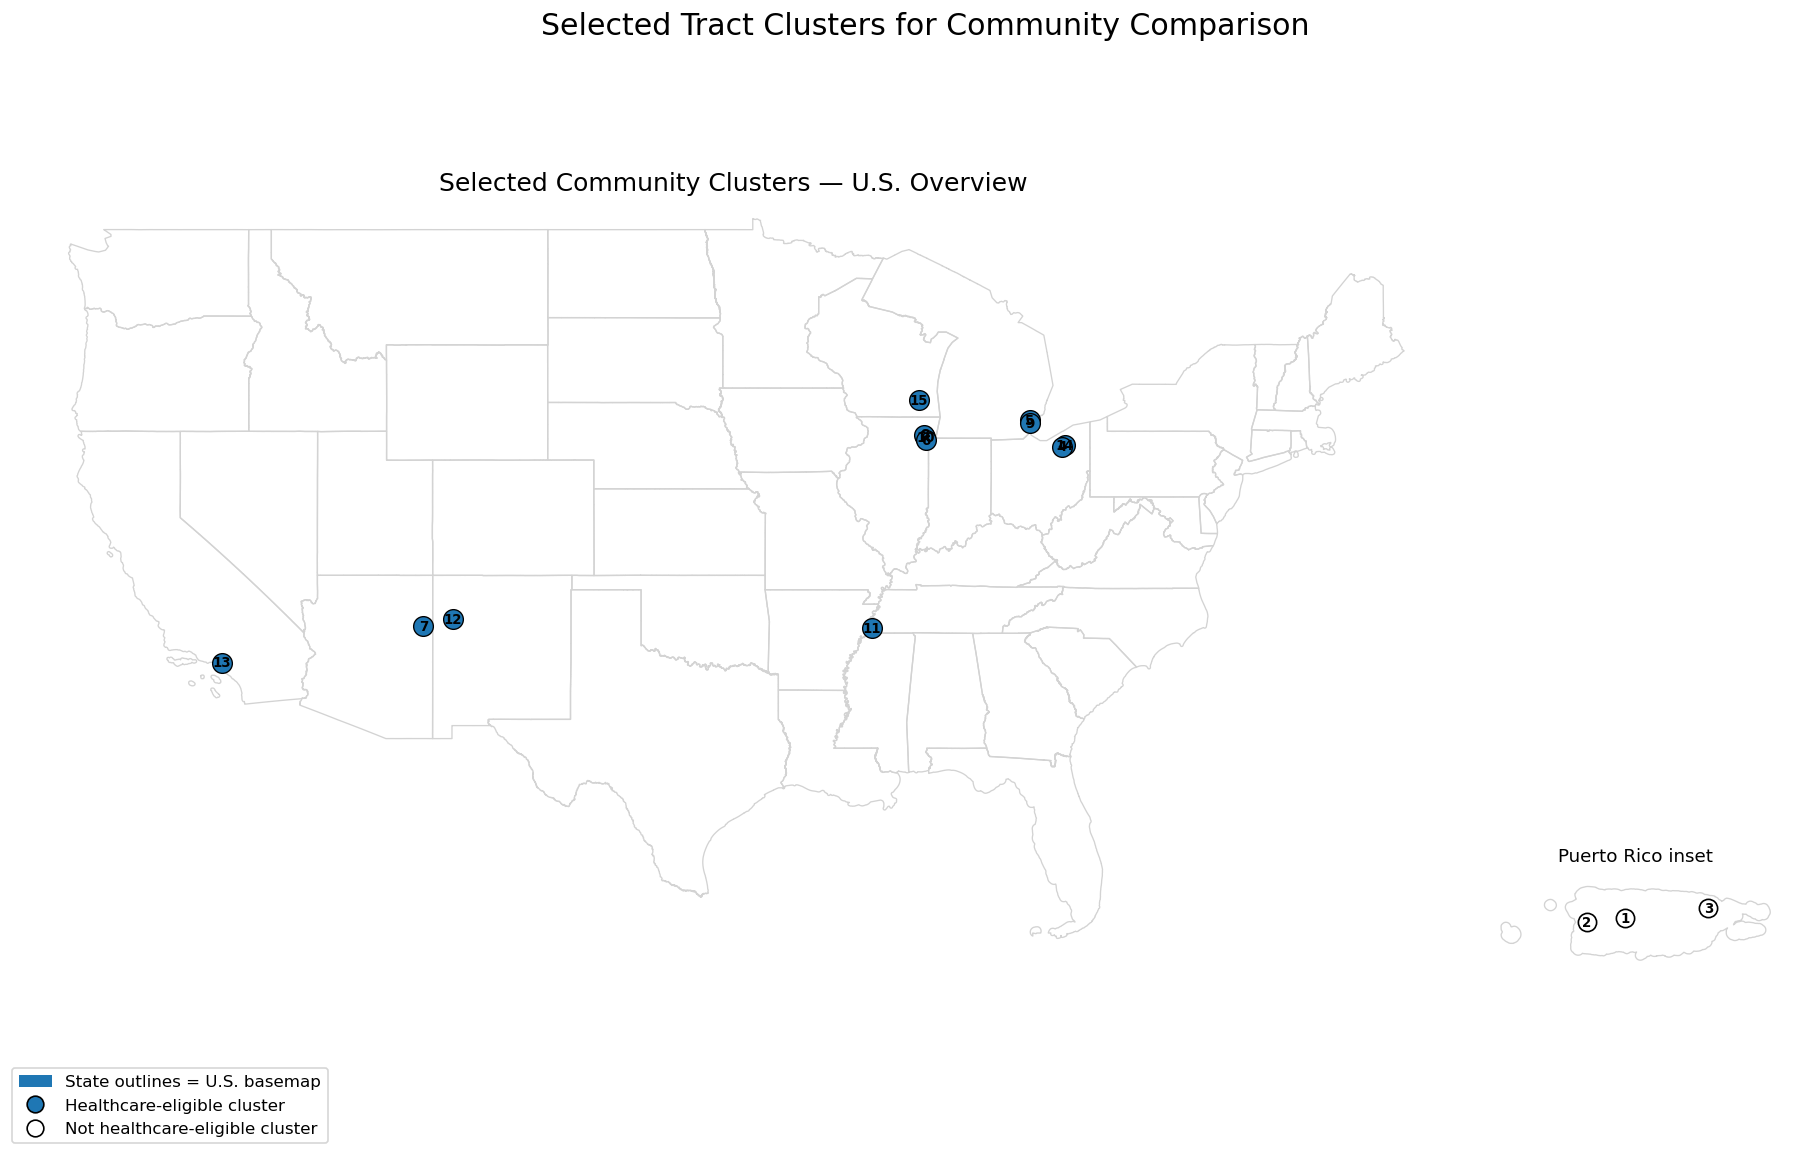

Mapped cluster lookup:


,enrichment_rank,cluster_id,display_state,display_county,healthcare_eligible_flag,cluster_shortlist_score
0,1,Puerto Rico | Utuado Municipio | cluster_75,Puerto Rico,Utuado Municipio,False,0.869855
1,2,Puerto Rico | Mayagüez Municipio | cluster_73,Puerto Rico,Mayagüez Municipio,False,0.848576
2,3,Puerto Rico | Río Grande Municipio | cluster_74,Puerto Rico,Río Grande Municipio,False,0.821570
3,4,Ohio | Cuyahoga County | cluster_64,Ohio,Cuyahoga County,True,0.811047
4,5,Michigan | Wayne County | cluster_38,Michigan,Wayne County,True,0.772703
5,6,Illinois | Cook County | cluster_29,Illinois,Cook County,True,0.752267
6,7,Arizona | Apache County | cluster_3,Arizona,Apache County,True,0.742122
7,8,Illinois | Cook County | cluster_25,Illinois,Cook County,True,0.734564
8,9,Michigan | Wayne County | cluster_39,Michigan,Wayne County,True,0.733314
9,10,Illinois | Cook County | cluster_24,Illinois,Cook County,True,0.712355


In [201]:
# Cell 9C — national overview map with U.S. basemap + cluster locator dots
# Purpose:
# show where the selected clusters are in the U.S. in a presentation-friendly way

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import zipfile
import requests
from pathlib import Path

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "adjacency_gdf" not in globals() or len(adjacency_gdf) == 0:
    raise ValueError("adjacency_gdf is missing or empty. Rerun Cell 2 first.")

if "enrichment_clusters" not in globals() or len(enrichment_clusters) == 0:
    raise ValueError("enrichment_clusters is missing or empty. Rerun Cell 6 first.")

# --------------------------------------------------
# B. Choose which cluster set to show
# --------------------------------------------------
MAP_CLUSTER_SOURCE = "enrichment_clusters"
# MAP_CLUSTER_SOURCE = "healthcare_comparison_set"

if MAP_CLUSTER_SOURCE == "healthcare_comparison_set":
    if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
        raise ValueError("healthcare_comparison_set is missing or empty. Run Cell 8 first.")
    map_clusters_df = healthcare_comparison_set.copy()
else:
    map_clusters_df = enrichment_clusters.copy()

map_cluster_ids = set(map_clusters_df["cluster_id"].astype(str).tolist())

# --------------------------------------------------
# C. Build dissolved cluster geometries
# --------------------------------------------------
map_gdf = adjacency_gdf.loc[
    adjacency_gdf["cluster_id"].astype(str).isin(map_cluster_ids)
].copy()

if len(map_gdf) == 0:
    raise ValueError("No geometries found for selected clusters.")

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=adjacency_gdf.crs).to_crs(4326)

cluster_boundaries = (
    map_gdf[["cluster_id", "geometry"]]
    .dissolve(by="cluster_id", as_index=False)
)

cluster_meta_cols = ["cluster_id", "display_state", "display_county"]
for c in ["enrichment_rank", "rank", "cluster_shortlist_score"]:
    if c in map_clusters_df.columns:
        cluster_meta_cols.append(c)

cluster_meta = (
    map_clusters_df[cluster_meta_cols]
    .drop_duplicates(subset=["cluster_id"])
    .copy()
)

cluster_boundaries = cluster_boundaries.merge(
    cluster_meta,
    on="cluster_id",
    how="left",
    validate="1:1"
)

# healthcare eligibility if available
if "cluster_shortlist_with_healthcare" in globals() and len(cluster_shortlist_with_healthcare) > 0:
    eligibility_df = (
        cluster_shortlist_with_healthcare[["cluster_id", "healthcare_eligible_flag"]]
        .drop_duplicates(subset=["cluster_id"])
        .copy()
    )
    cluster_boundaries = cluster_boundaries.merge(
        eligibility_df,
        on="cluster_id",
        how="left",
        validate="1:1"
    )
else:
    cluster_boundaries["healthcare_eligible_flag"] = False

cluster_boundaries["healthcare_eligible_flag"] = (
    cluster_boundaries["healthcare_eligible_flag"].fillna(False).astype(bool)
)

cluster_boundaries["label_point"] = cluster_boundaries.geometry.representative_point()
cluster_boundaries["lon"] = cluster_boundaries["label_point"].x
cluster_boundaries["lat"] = cluster_boundaries["label_point"].y

# --------------------------------------------------
# D. Load U.S. state basemap (Census TIGER states)
# --------------------------------------------------
STATE_BASE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/STATE/"
STATE_ROOT_DIR = RAW_DIR / "tl_2024_us_state"
STATE_ROOT_DIR.mkdir(parents=True, exist_ok=True)

state_zip_name = "tl_2024_us_state.zip"
state_shp_name = "tl_2024_us_state.shp"
state_zip_path = STATE_ROOT_DIR / state_zip_name
state_extract_dir = STATE_ROOT_DIR / "tl_2024_us_state"
state_shp_path = state_extract_dir / state_shp_name

if not state_shp_path.exists():
    state_extract_dir.mkdir(parents=True, exist_ok=True)

    if not state_zip_path.exists():
        url = f"{STATE_BASE_URL}{state_zip_name}"
        print(f"Downloading {url}")
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with open(state_zip_path, "wb") as f:
            f.write(r.content)

    print(f"Extracting {state_zip_name}")
    with zipfile.ZipFile(state_zip_path, "r") as zf:
        zf.extractall(state_extract_dir)

states_gdf = gpd.read_file(state_shp_path).to_crs(4326)

# Keep only states / DC / PR, drop territories not needed for this slide
drop_names = {
    "Alaska", "Hawaii", "Guam", "American Samoa",
    "Commonwealth of the Northern Mariana Islands",
    "United States Virgin Islands"
}
states_gdf = states_gdf.loc[~states_gdf["NAME"].isin(drop_names)].copy()

conus_states = states_gdf.loc[states_gdf["NAME"] != "Puerto Rico"].copy()
pr_state = states_gdf.loc[states_gdf["NAME"] == "Puerto Rico"].copy()

# --------------------------------------------------
# E. Split points into CONUS vs Puerto Rico
# --------------------------------------------------
conus_points = cluster_boundaries.loc[cluster_boundaries["display_state"] != "Puerto Rico"].copy()
pr_points = cluster_boundaries.loc[cluster_boundaries["display_state"] == "Puerto Rico"].copy()

# --------------------------------------------------
# F. Plot
# --------------------------------------------------
fig = plt.figure(figsize=(16, 10))

# Main U.S. panel
ax_main = fig.add_axes([0.04, 0.08, 0.72, 0.84])
conus_states.boundary.plot(ax=ax_main, linewidth=0.8, color="lightgray")

# Healthcare-eligible vs not
conus_yes = conus_points.loc[conus_points["healthcare_eligible_flag"]].copy()
conus_no = conus_points.loc[~conus_points["healthcare_eligible_flag"]].copy()

if len(conus_yes) > 0:
    ax_main.scatter(
        conus_yes["lon"], conus_yes["lat"],
        s=140, zorder=3, edgecolor="black", linewidth=0.8,
        label="Healthcare-eligible"
    )

if len(conus_no) > 0:
    ax_main.scatter(
        conus_no["lon"], conus_no["lat"],
        s=140, zorder=3, edgecolor="black", linewidth=1.0,
        facecolors="white", label="Not healthcare-eligible"
    )

for _, row in conus_points.iterrows():
    label_txt = ""
    if "enrichment_rank" in row and pd.notna(row["enrichment_rank"]):
        label_txt = str(int(row["enrichment_rank"]))

    if label_txt:
        ax_main.text(
            row["lon"], row["lat"], label_txt,
            ha="center", va="center",
            fontsize=8, fontweight="bold",
            zorder=4
        )

ax_main.set_title("Selected Community Clusters — U.S. Overview", fontsize=15)
ax_main.set_xlim(-126, -66)
ax_main.set_ylim(24, 50)
ax_main.set_axis_off()

# Puerto Rico inset
ax_pr = fig.add_axes([0.79, 0.12, 0.16, 0.18])
if len(pr_state) > 0:
    pr_state.boundary.plot(ax=ax_pr, linewidth=0.8, color="lightgray")

pr_yes = pr_points.loc[pr_points["healthcare_eligible_flag"]].copy()
pr_no = pr_points.loc[~pr_points["healthcare_eligible_flag"]].copy()

if len(pr_yes) > 0:
    ax_pr.scatter(
        pr_yes["lon"], pr_yes["lat"],
        s=120, zorder=3, edgecolor="black", linewidth=0.8
    )

if len(pr_no) > 0:
    ax_pr.scatter(
        pr_no["lon"], pr_no["lat"],
        s=120, zorder=3, edgecolor="black", linewidth=1.0,
        facecolors="white"
    )

for _, row in pr_points.iterrows():
    label_txt = ""
    if "enrichment_rank" in row and pd.notna(row["enrichment_rank"]):
        label_txt = str(int(row["enrichment_rank"]))

    if label_txt:
        ax_pr.text(
            row["lon"], row["lat"], label_txt,
            ha="center", va="center",
            fontsize=8, fontweight="bold",
            zorder=4
        )

if len(pr_state) > 0:
    minx, miny, maxx, maxy = pr_state.total_bounds
    ax_pr.set_xlim(minx - 0.2, maxx + 0.2)
    ax_pr.set_ylim(miny - 0.15, maxy + 0.15)

ax_pr.set_title("Puerto Rico inset", fontsize=11)
ax_pr.set_axis_off()

fig.suptitle("Selected Tract Clusters for Community Comparison", fontsize=18, y=0.97)

# Legend
legend_handles = [
    mpatches.Patch(label="State outlines = U.S. basemap"),
]

if len(conus_yes) + len(pr_yes) > 0:
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='C0', markeredgecolor='black',
                   markersize=10, label='Healthcare-eligible cluster')
    )

if len(conus_no) + len(pr_no) > 0:
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='white', markeredgecolor='black',
                   markersize=10, label='Not healthcare-eligible cluster')
    )

fig.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=True
)

plt.show()

# --------------------------------------------------
# G. Printed lookup table
# --------------------------------------------------
lookup_cols = [
    c for c in [
        "enrichment_rank",
        "cluster_id",
        "display_state",
        "display_county",
        "healthcare_eligible_flag",
        "cluster_shortlist_score"
    ]
    if c in cluster_boundaries.columns
]

print("Mapped cluster lookup:")
display(
    cluster_boundaries[lookup_cols]
    .sort_values(
        ["enrichment_rank", "cluster_id"] if "enrichment_rank" in cluster_boundaries.columns else ["cluster_id"]
    )
    .reset_index(drop=True)
)

### Cell 9F — healthcare access comparison heatmap across finalist clusters

Preview of healthcare values used in the heatmap:


,cluster_label,healthcare_need_score,uninsured_rate,uninsured_adults_rate,uninsured_children_rate,primary_care_physicians_rate,dentists_rate,mental_health_providers_rate,other_primary_care_providers_rate,preventable_hospital_stays_rate,mammography_screening_rate,flu_vaccinations_rate
0,"#1 — Apache County, Arizona",0.879167,0.198031,0.230315,0.128705,0.000410,0.000751,0.001093,0.000970,3750.0,0.205,0.400
1,"#2 — McKinley County, New Mexico",0.822917,0.188087,0.241622,0.075279,0.000752,0.000722,0.001697,0.000596,3481.0,0.245,0.445
2,"#3 — Wayne County, Michigan",0.550000,0.070757,0.087738,0.026215,0.000755,0.000732,0.003282,0.001036,5730.5,0.360,0.460
3,"#4 — Shelby County, Tennessee",0.645833,0.131008,0.161872,0.055092,0.000878,0.000759,0.001702,0.001595,3897.0,0.335,0.505
4,"#5 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
5,"#6 — Los Angeles County, California",0.616667,0.106480,0.130229,0.036193,0.000741,0.000927,0.004129,0.000764,3078.0,0.285,0.410
6,"#7 — Wayne County, Michigan",0.550000,0.070757,0.087738,0.026215,0.000755,0.000732,0.003282,0.001036,5730.5,0.360,0.460
7,"#8 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
8,"#9 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
9,"#10 — Cuyahoga County, Ohio",0.260417,0.073992,0.087338,0.035996,0.001157,0.001093,0.004431,0.002076,4450.0,0.435,0.530


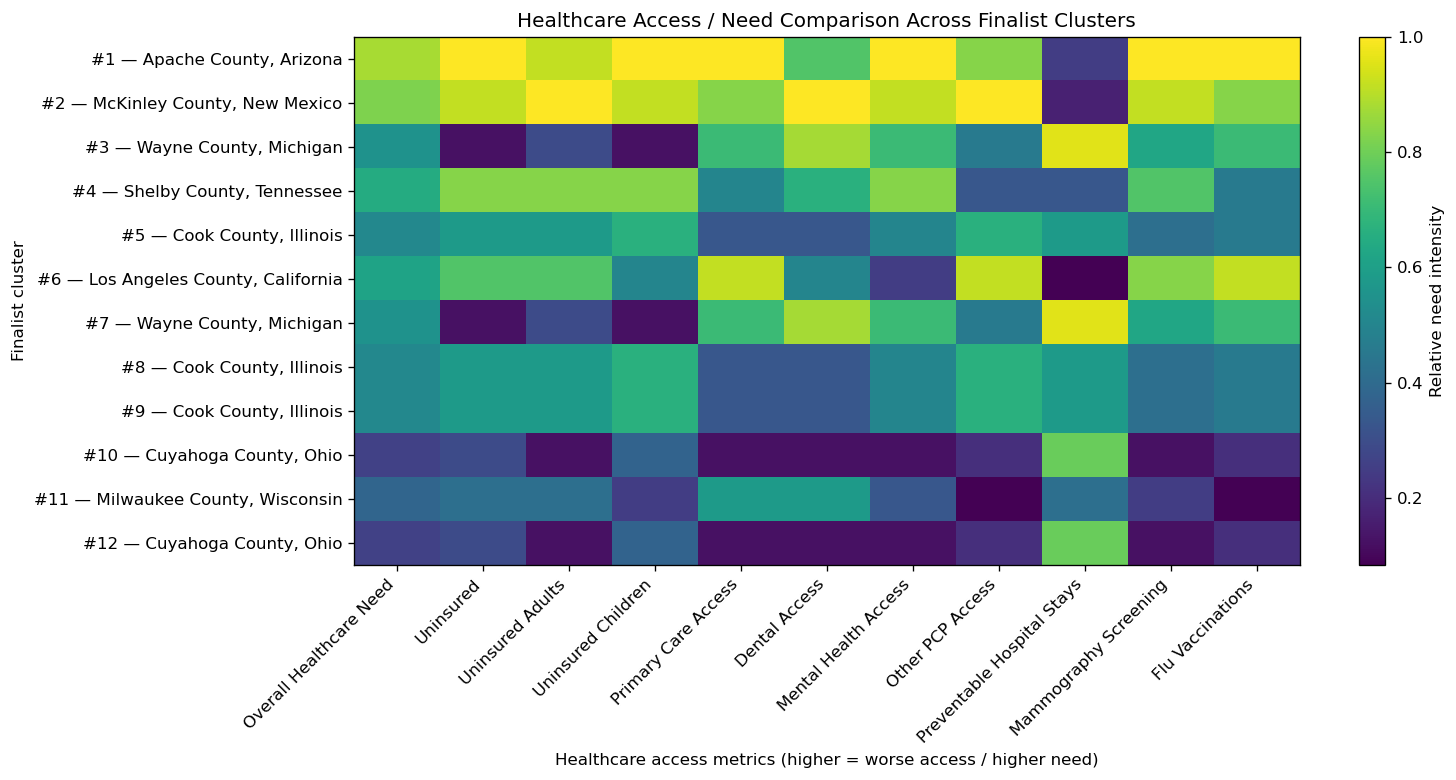

Healthcare access comparison table (relative scores):


,Overall Healthcare Need,Uninsured,Uninsured Adults,Uninsured Children,Primary Care Access,Dental Access,Mental Health Access,Other PCP Access,Preventable Hospital Stays,Mammography Screening,Flu Vaccinations
"#1 — Apache County, Arizona",0.879,1.000,0.917,1.000,1.000,0.750,1.000,0.833,0.250,1.000,1.000
"#2 — McKinley County, New Mexico",0.823,0.917,1.000,0.917,0.833,1.000,0.917,1.000,0.167,0.917,0.833
"#3 — Wayne County, Michigan",0.550,0.125,0.292,0.125,0.708,0.875,0.708,0.458,0.958,0.625,0.708
"#4 — Shelby County, Tennessee",0.646,0.833,0.833,0.833,0.500,0.667,0.833,0.333,0.333,0.750,0.458
"#5 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#6 — Los Angeles County, California",0.617,0.750,0.750,0.500,0.917,0.500,0.250,0.917,0.083,0.833,0.917
"#7 — Wayne County, Michigan",0.550,0.125,0.292,0.125,0.708,0.875,0.708,0.458,0.958,0.625,0.708
"#8 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#9 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#10 — Cuyahoga County, Ohio",0.260,0.292,0.125,0.375,0.125,0.125,0.125,0.208,0.792,0.125,0.208



Saved:
- C:\Users\jabba\Desktop\Code\machine_learning\AUC_mastercard_challenge\src\data\processed\presentation_ready\healthcare_access_heatmap_table.csv


In [202]:
# Cell 9F — healthcare access comparison heatmap across finalist clusters
# FIXED:
# avoid pandas index-alignment NaNs by assigning numpy arrays directly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "healthcare_cluster_scored" not in globals() or len(healthcare_cluster_scored) == 0:
    raise ValueError("healthcare_cluster_scored is empty or missing. Run Cell 8 first.")

if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
    raise ValueError("healthcare_comparison_set is empty or missing. Run Cell 8 first.")

# --------------------------------------------------
# B. Metric setup
# higher = worse access / higher need
# --------------------------------------------------
healthcare_access_metrics = [
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "preventable_hospital_stays_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]

metric_label_map = {
    "uninsured_rate": "Uninsured",
    "uninsured_adults_rate": "Uninsured Adults",
    "uninsured_children_rate": "Uninsured Children",
    "primary_care_physicians_rate": "Primary Care Access",
    "dentists_rate": "Dental Access",
    "mental_health_providers_rate": "Mental Health Access",
    "other_primary_care_providers_rate": "Other PCP Access",
    "preventable_hospital_stays_rate": "Preventable Hospital Stays",
    "mammography_screening_rate": "Mammography Screening",
    "flu_vaccinations_rate": "Flu Vaccinations",
}

high_is_bad = {
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "preventable_hospital_stays_rate",
}

low_is_bad = {
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
}

# --------------------------------------------------
# C. Build finalist healthcare table
# --------------------------------------------------
heatmap_df = (
    healthcare_cluster_scored
    .merge(
        healthcare_comparison_set[
            ["cluster_id", "healthcare_comparison_rank", "preliminary_combined_score"]
        ].drop_duplicates(),
        on="cluster_id",
        how="inner",
        validate="1:1"
    )
    .copy()
)

heatmap_df = heatmap_df.sort_values(
    ["healthcare_comparison_rank", "healthcare_need_score"],
    ascending=[True, False]
).reset_index(drop=True)

heatmap_df["cluster_label"] = (
    "#" + heatmap_df["healthcare_comparison_rank"].astype(int).astype(str)
    + " — "
    + heatmap_df["display_county"].astype(str)
    + ", "
    + heatmap_df["display_state"].astype(str)
)

print("Preview of healthcare values used in the heatmap:")
display(
    heatmap_df[
        ["cluster_label", "healthcare_need_score"] + healthcare_access_metrics
    ].head(12)
)

# --------------------------------------------------
# D. Convert all metrics so higher = worse access / higher need
# then percentile-rank them across finalists
# --------------------------------------------------
oriented = pd.DataFrame(index=heatmap_df["cluster_label"].tolist())

for metric in healthcare_access_metrics:
    vals = pd.to_numeric(heatmap_df[metric], errors="coerce")

    if metric in high_is_bad:
        ranked = vals.rank(pct=True, method="average")
    elif metric in low_is_bad:
        ranked = (-vals).rank(pct=True, method="average")
    else:
        ranked = pd.Series(np.nan, index=vals.index)

    # IMPORTANT FIX: assign raw values, not index-aligned series
    oriented[metric_label_map[metric]] = ranked.to_numpy()

# keep healthcare need score as summary column
oriented["Overall Healthcare Need"] = pd.to_numeric(
    heatmap_df["healthcare_need_score"], errors="coerce"
).to_numpy()

# move summary column first
ordered_cols = ["Overall Healthcare Need"] + [
    c for c in oriented.columns if c != "Overall Healthcare Need"
]
oriented = oriented[ordered_cols]

# --------------------------------------------------
# E. Plot heatmap
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(13, max(6, len(oriented) * 0.55)))

im = ax.imshow(oriented.values, aspect="auto")

ax.set_xticks(np.arange(oriented.shape[1]))
ax.set_xticklabels(oriented.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(oriented.shape[0]))
ax.set_yticklabels(oriented.index)

ax.set_title("Healthcare Access / Need Comparison Across Finalist Clusters")
ax.set_xlabel("Healthcare access metrics (higher = worse access / higher need)")
ax.set_ylabel("Finalist cluster")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative need intensity")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# F. Printed table
# --------------------------------------------------
print("Healthcare access comparison table (relative scores):")
display(oriented.round(3))

# --------------------------------------------------
# G. Optional save
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
oriented.to_csv(OUT_DIR / "healthcare_access_heatmap_table.csv")

print("\nSaved:")
print("-", OUT_DIR / "healthcare_access_heatmap_table.csv")

In [203]:
# Cell 10A — shared prep for finalist visuals

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# basic checks
# -----------------------------
required_globals = [
    "healthcare_comparison_set",
    "healthcare_cluster_scored",
    "cluster_period_summary",
    "analysis_panel",
    "healthcare_standardized",
]
for name in required_globals:
    if name not in globals() or len(globals()[name]) == 0:
        raise ValueError(f"{name} is missing or empty. Rerun the earlier cells first.")

# -----------------------------
# helpers
# -----------------------------
def pct_rank_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def pct_rank_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        return values.loc[valid].mean() if valid.sum() > 0 else np.nan
    return np.average(values.loc[mask], weights=weights.loc[mask])

STATE_ABBR = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA","Colorado":"CO",
    "Connecticut":"CT","Delaware":"DE","District of Columbia":"DC","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
    "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD","Massachusetts":"MA",
    "Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO","Montana":"MT",
    "Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM",
    "New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
    "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY","Puerto Rico":"PR"
}

TOP_FINALISTS_N = min(4, len(healthcare_comparison_set))

# -----------------------------
# top finalists
# -----------------------------
finalist_eval_df = (
    healthcare_comparison_set
    .sort_values(
        ["preliminary_combined_score", "healthcare_need_score", "cluster_shortlist_score"],
        ascending=[False, False, False]
    )
    .head(TOP_FINALISTS_N)
    .copy()
    .reset_index(drop=True)
)

finalist_eval_df["final_rank"] = np.arange(1, len(finalist_eval_df) + 1)
finalist_eval_df["cluster_label"] = (
    "#" + finalist_eval_df["final_rank"].astype(str)
    + " — "
    + finalist_eval_df["display_county"].astype(str)
    + ", "
    + finalist_eval_df["display_state"].astype(str)
)

# attach detailed healthcare metrics
health_cols = [
    "cluster_id",
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "preventable_hospital_stays_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]
finalist_eval_df = finalist_eval_df.merge(
    healthcare_cluster_scored[health_cols],
    on="cluster_id",
    how="left",
    validate="1:1"
)

# -----------------------------
# healthcare composites
# -----------------------------
all_health = healthcare_cluster_scored.copy()

uninsured_burden_all = (
    pct_rank_high(all_health["uninsured_rate"]) +
    pct_rank_high(all_health["uninsured_adults_rate"]) +
    pct_rank_high(all_health["uninsured_children_rate"])
) / 3

provider_gap_all = (
    pct_rank_low(all_health["primary_care_physicians_rate"]) +
    pct_rank_low(all_health["dentists_rate"]) +
    pct_rank_low(all_health["mental_health_providers_rate"]) +
    pct_rank_low(all_health["other_primary_care_providers_rate"])
) / 4

preventive_gap_all = (
    pct_rank_low(all_health["mammography_screening_rate"]) +
    pct_rank_low(all_health["flu_vaccinations_rate"])
) / 2

preventable_stays_all = pct_rank_high(all_health["preventable_hospital_stays_rate"])

health_composites = pd.DataFrame({
    "cluster_id": all_health["cluster_id"],
    "uninsured_burden_score": uninsured_burden_all,
    "provider_access_gap_score": provider_gap_all,
    "preventive_care_gap_score": preventive_gap_all,
    "preventable_stays_score": preventable_stays_all,
})

finalist_eval_df = finalist_eval_df.merge(
    health_composites,
    on="cluster_id",
    how="left",
    validate="1:1"
)

# -----------------------------
# recovery-period economic context
# -----------------------------
recovery_cols = [
    "cluster_id",
    "igs_total_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
]
finalist_eval_df = finalist_eval_df.merge(
    cluster_period_summary[recovery_cols],
    on="cluster_id",
    how="left",
    validate="1:1"
)

print("Prepared finalist_eval_df:")
display(
    finalist_eval_df[
        [
            "final_rank", "cluster_label",
            "cluster_shortlist_score", "healthcare_need_score", "preliminary_combined_score",
            "uninsured_burden_score", "provider_access_gap_score",
            "preventive_care_gap_score", "preventable_stays_score"
        ]
    ]
)

Prepared finalist_eval_df:


,final_rank,cluster_label,cluster_shortlist_score,healthcare_need_score,preliminary_combined_score,uninsured_burden_score,provider_access_gap_score,preventive_care_gap_score,preventable_stays_score
0,1,"#1 — Apache County, Arizona",0.742122,0.879167,0.783235,0.972222,0.895833,1.000000,0.250000
1,2,"#2 — McKinley County, New Mexico",0.705959,0.822917,0.741047,0.944444,0.937500,0.875000,0.166667
2,3,"#3 — Wayne County, Michigan",0.772703,0.550000,0.705892,0.180556,0.687500,0.666667,0.958333
3,4,"#4 — Shelby County, Tennessee",0.712122,0.645833,0.692235,0.833333,0.583333,0.604167,0.333333


### Cell 10D — healthcare profile grouped bar chart for the top finalists

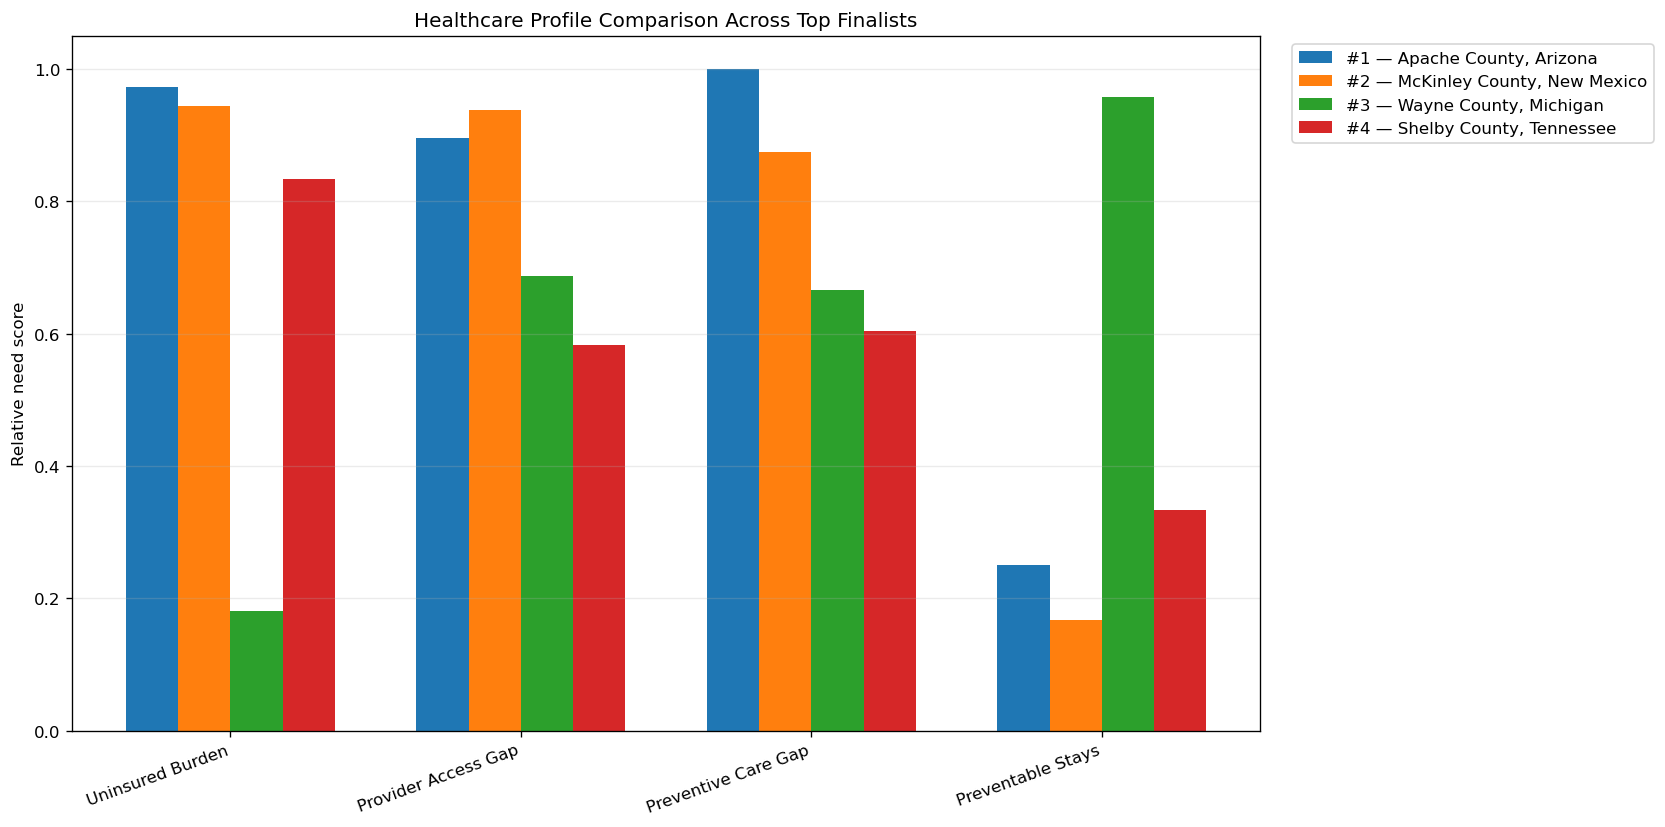

In [204]:
# Cell 10D — healthcare profile grouped bar chart for the top finalists

profile_cols = [
    "uninsured_burden_score",
    "provider_access_gap_score",
    "preventive_care_gap_score",
    "preventable_stays_score",
]

profile_labels = {
    "uninsured_burden_score": "Uninsured Burden",
    "provider_access_gap_score": "Provider Access Gap",
    "preventive_care_gap_score": "Preventive Care Gap",
    "preventable_stays_score": "Preventable Stays",
}

plot_df = finalist_eval_df[["cluster_label"] + profile_cols].copy()

x = np.arange(len(profile_cols))
bar_w = 0.18

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.bar(
        x + (i - (len(plot_df)-1)/2) * bar_w,
        row[profile_cols].values,
        width=bar_w,
        label=row["cluster_label"]
    )

ax.set_xticks(x)
ax.set_xticklabels([profile_labels[c] for c in profile_cols], rotation=20, ha="right")
ax.set_ylabel("Relative need score")
ax.set_title("Healthcare Profile Comparison Across Top Finalists")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Cell 10F — provisional solution-fit visual

In [205]:
import pandas as pd
from pathlib import Path

PROC_CANDIDATES = [
    Path("src/data/processed"),
    Path("data/processed"),
    Path.cwd() / "src/data/processed",
    Path.cwd() / "data/processed",
]

PROCESSED_DIR = next((p for p in PROC_CANDIDATES if p.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError("Could not find src/data/processed or data/processed.")

# This file should contain the finalist community clusters
enrichment_clusters = pd.read_parquet(PROCESSED_DIR / "enrichment_clusters.parquet").copy()

# Keep only Wayne + Shelby finalist communities
cand = enrichment_clusters.loc[
    (
        (enrichment_clusters["display_state"] == "Michigan") &
        (enrichment_clusters["display_county"] == "Wayne County")
    )
    |
    (
        (enrichment_clusters["display_state"] == "Tennessee") &
        (enrichment_clusters["display_county"] == "Shelby County")
    )
].copy()

# Show useful columns if they exist
preferred_cols = [
    "cluster_id",
    "display_state",
    "display_county",
    "enrichment_rank",
    "rank",
    "cluster_shortlist_score",
    "combined_score",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
]
cols = [c for c in preferred_cols if c in cand.columns]

# Sort by best available ranking field
sort_cols = [c for c in ["enrichment_rank", "rank"] if c in cand.columns]
if sort_cols:
    cand = cand.sort_values(sort_cols)
elif "cluster_shortlist_score" in cand.columns:
    cand = cand.sort_values("cluster_shortlist_score", ascending=False)
elif "combined_score" in cand.columns:
    cand = cand.sort_values("combined_score", ascending=False)

print(cand[cols].to_string(index=False))

                            cluster_id display_state display_county  enrichment_rank  rank  cluster_shortlist_score  n_cluster_tracts  latest_cluster_pop_total
  Michigan | Wayne County | cluster_38      Michigan   Wayne County                5     5                 0.772703               152                  319984.0
  Michigan | Wayne County | cluster_39      Michigan   Wayne County                9     9                 0.733314                 9                   19947.0
Tennessee | Shelby County | cluster_77     Tennessee  Shelby County               11    11                 0.712122                96                  268298.0


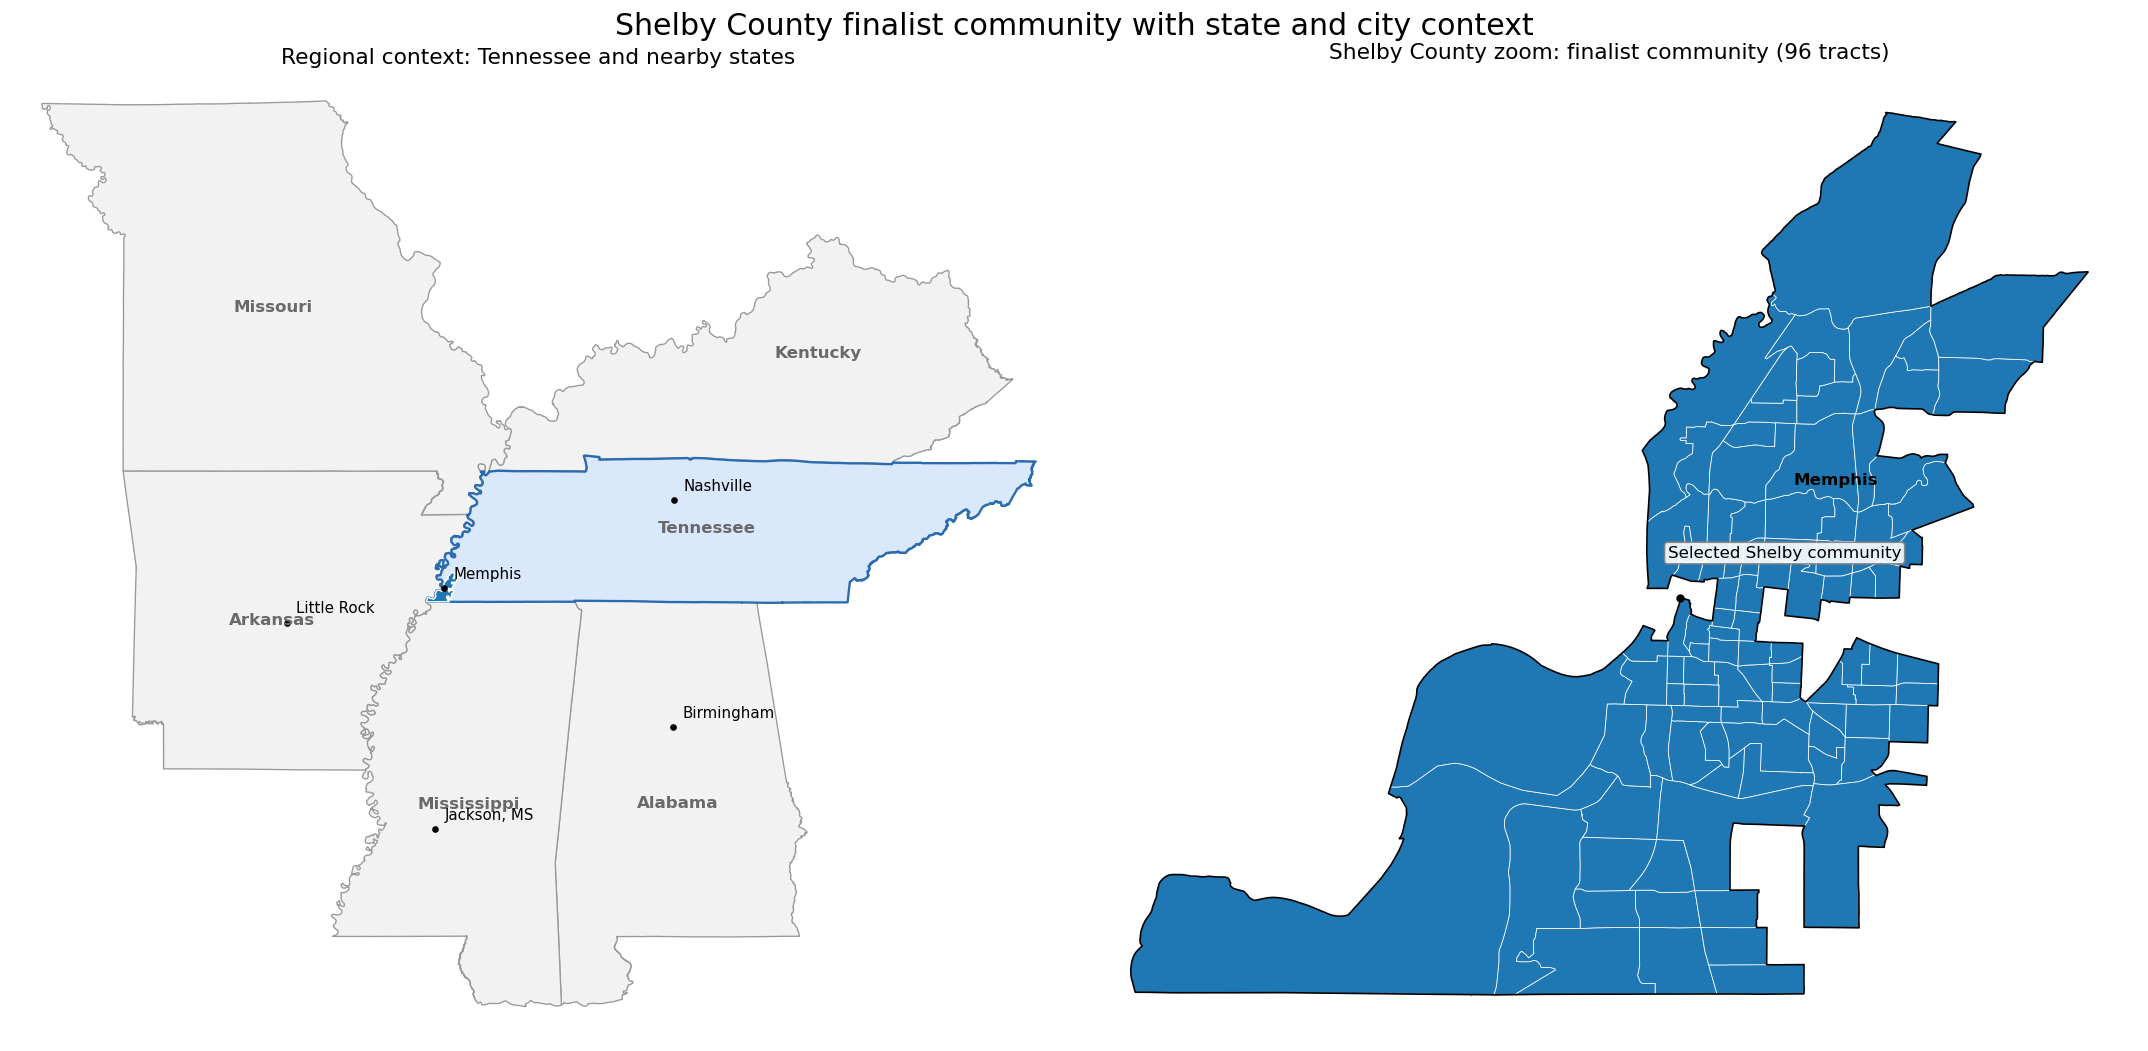


Cluster: Tennessee | Shelby County | cluster_77
Shelby tracts in adjacency universe: 96
Selected cluster tracts: 96
Saved: data\processed\presentation_ready\shelby_cluster_77_context_map_from_adjacency.png


In [206]:
# ============================================================
# Shelby cluster context map — use adjacency_gdf directly
# This avoids the shapefile-selection bug entirely.
# ============================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "adjacency_gdf" not in globals() or len(adjacency_gdf) == 0:
    raise ValueError("adjacency_gdf is missing or empty. Rerun Cell 2 first.")

TARGET_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"

# --------------------------------------------------
# B. Get Shelby cluster tracts from the actual clustering geometry
# --------------------------------------------------
cluster_gdf = adjacency_gdf.loc[
    adjacency_gdf["cluster_id"].astype(str) == TARGET_CLUSTER_ID
].copy()

if cluster_gdf.empty:
    raise ValueError(f"No rows found in adjacency_gdf for {TARGET_CLUSTER_ID}")

cluster_gdf["geoid"] = cluster_gdf["geoid"].astype(str).str.zfill(11)

# all Shelby tracts that were in the clustering universe
shelby_all = adjacency_gdf.loc[
    (adjacency_gdf["display_state"] == "Tennessee") &
    (adjacency_gdf["display_county"] == "Shelby County")
].copy()

if shelby_all.empty:
    raise ValueError("No Shelby County rows found in adjacency_gdf.")

# make sure these are GeoDataFrames
cluster_gdf = gpd.GeoDataFrame(cluster_gdf, geometry="geometry", crs=adjacency_gdf.crs)
shelby_all = gpd.GeoDataFrame(shelby_all, geometry="geometry", crs=adjacency_gdf.crs)

# reproject for plotting if needed
if cluster_gdf.crs is not None and str(cluster_gdf.crs) != "EPSG:3857":
    cluster_gdf = cluster_gdf.to_crs(3857)
    shelby_all = shelby_all.to_crs(3857)

cluster_outline = cluster_gdf.dissolve()
shelby_outline = shelby_all.dissolve()

# --------------------------------------------------
# C. Optional: load U.S. states for context
# --------------------------------------------------
DATA_DIR_CANDIDATES = [
    Path("src/data/raw"),
    Path("data/raw"),
    Path.cwd() / "src/data/raw",
    Path.cwd() / "data/raw",
]

RAW_DIR = next((p for p in DATA_DIR_CANDIDATES if p.exists()), None)
if RAW_DIR is None:
    raise FileNotFoundError("Could not find src/data/raw or data/raw.")

state_candidates = list(RAW_DIR.rglob("tl_2024_us_state*.shp")) + list(RAW_DIR.rglob("*us_state*.shp"))
if not state_candidates:
    raise FileNotFoundError("Could not find U.S. state shapefile.")

state_shp = state_candidates[0]
states = gpd.read_file(state_shp).copy().to_crs(3857)

# keep nearby-state context
if "STUSPS" not in states.columns and "STATEFP" in states.columns:
    fp_to_abbr = {
        "01":"AL","05":"AR","21":"KY","28":"MS","47":"TN","22":"LA","13":"GA","29":"MO"
    }
    states["STUSPS"] = states["STATEFP"].astype(str).str.zfill(2).map(fp_to_abbr)

ctx_states = states.loc[states["STUSPS"].isin(["TN", "AR", "MS", "AL", "KY", "MO"])].copy()
tn_state = ctx_states.loc[ctx_states["STUSPS"] == "TN"].copy()

# state label points
state_labels = ctx_states.copy()
state_labels["label_point"] = state_labels.representative_point()

# fallback city points
city_df = pd.DataFrame({
    "label": ["Memphis", "Nashville", "Little Rock", "Jackson, MS", "Birmingham"],
    "lon": [-90.0490, -86.7816, -92.2896, -90.1848, -86.8025],
    "lat": [35.1495, 36.1627, 34.7465, 32.2988, 33.5186],
})
city_gdf = gpd.GeoDataFrame(
    city_df,
    geometry=gpd.points_from_xy(city_df["lon"], city_df["lat"]),
    crs=4326
).to_crs(3857)

# --------------------------------------------------
# D. Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# LEFT: regional context
ctx_states.plot(ax=axes[0], color="#f2f2f2", edgecolor="#999999", linewidth=0.8)
tn_state.plot(ax=axes[0], color="#d9e8fb", edgecolor="#2b6cb0", linewidth=1.4)
cluster_outline.plot(ax=axes[0], color="#1f78b4", edgecolor="white", linewidth=0.8)

for _, row in state_labels.iterrows():
    pt = row["label_point"]
    axes[0].text(pt.x, pt.y, row["NAME"], fontsize=10, ha="center", va="center",
                 color="dimgray", weight="bold")

for _, row in city_gdf.iterrows():
    pt = row.geometry
    axes[0].plot(pt.x, pt.y, "o", markersize=3, color="black")
    axes[0].text(pt.x + 15000, pt.y + 15000, row["label"], fontsize=9, color="black")

minx, miny, maxx, maxy = ctx_states.total_bounds
pad_x = (maxx - minx) * 0.03
pad_y = (maxy - miny) * 0.03
axes[0].set_xlim(minx - pad_x, maxx + pad_x)
axes[0].set_ylim(miny - pad_y, maxy + pad_y)
axes[0].set_title("Regional context: Tennessee and nearby states", fontsize=13)
axes[0].set_axis_off()

# RIGHT: Shelby zoom
shelby_all.plot(ax=axes[1], color="#ededed", edgecolor="#c0c0c0", linewidth=0.3)
cluster_gdf.plot(ax=axes[1], color="#1f78b4", edgecolor="white", linewidth=0.45)
shelby_outline.boundary.plot(ax=axes[1], color="black", linewidth=1.0)

cluster_label_pt = cluster_outline.representative_point().iloc[0]
axes[1].text(
    cluster_label_pt.x, cluster_label_pt.y,
    "Selected Shelby community",
    fontsize=10, ha="center", va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.9)
)

# Memphis label
mem_pt = city_gdf.loc[city_gdf["label"] == "Memphis"].iloc[0].geometry
axes[1].plot(mem_pt.x, mem_pt.y, "o", markersize=4, color="black")
axes[1].text(mem_pt.x + 6000, mem_pt.y + 6000, "Memphis", fontsize=10, color="black", weight="bold")

minx, miny, maxx, maxy = shelby_all.total_bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05
axes[1].set_xlim(minx - pad_x, maxx + pad_x)
axes[1].set_ylim(miny - pad_y, maxy + pad_y)
axes[1].set_title(f"Shelby County zoom: finalist community ({len(cluster_gdf)} tracts)", fontsize=13)
axes[1].set_axis_off()

fig.suptitle("Shelby County finalist community with state and city context", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# E. Save
# --------------------------------------------------
OUT_DIR = Path("data/processed/presentation_ready")
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_png = OUT_DIR / "shelby_cluster_77_context_map_from_adjacency.png"
fig.savefig(out_png, bbox_inches="tight", dpi=220)

print("\nCluster:", TARGET_CLUSTER_ID)
print("Shelby tracts in adjacency universe:", len(shelby_all))
print("Selected cluster tracts:", len(cluster_gdf))
print("Saved:", out_png)

In [207]:
# ============================================================
# Georgia-only candidate search:
# find the highest-scoring adjacency-based cluster in Georgia
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx

# ------------------------------------------------------------
# 0. Helpers
# ------------------------------------------------------------
def bad_when_high(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series):
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def weighted_avg(df, value_col, weight_col):
    tmp = df[[value_col, weight_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp[weight_col] = pd.to_numeric(tmp[weight_col], errors="coerce")
    tmp = tmp.dropna()
    tmp = tmp[tmp[weight_col] > 0]
    if tmp.empty:
        return np.nan
    return np.average(tmp[value_col], weights=tmp[weight_col])

def assign_period(year):
    year = int(year)
    if year in [2017, 2018, 2019]:
        return "pre_covid"
    if year in [2020, 2021]:
        return "covid"
    if year in [2022, 2023, 2024]:
        return "recovery"
    return np.nan

def normalize_geoid(series):
    return series.astype(str).str.extract(r"(\d{11})", expand=False).fillna(series.astype(str)).str.zfill(11)

# ------------------------------------------------------------
# 1. Locate folders + load analysis panel
# ------------------------------------------------------------
PROC_CANDIDATES = [
    Path("src/data/processed"),
    Path("data/processed"),
    Path.cwd() / "src/data/processed",
    Path.cwd() / "data/processed",
]
RAW_CANDIDATES = [
    Path("src/data/raw"),
    Path("data/raw"),
    Path.cwd() / "src/data/raw",
    Path.cwd() / "data/raw",
]

PROCESSED_DIR = next((p for p in PROC_CANDIDATES if p.exists()), None)
RAW_DIR = next((p for p in RAW_CANDIDATES if p.exists()), None)

if PROCESSED_DIR is None:
    raise FileNotFoundError("Could not find processed data directory.")
if RAW_DIR is None:
    raise FileNotFoundError("Could not find raw data directory.")

OUT_DIR = PROCESSED_DIR / "presentation_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if "analysis_panel" in globals() and isinstance(analysis_panel, pd.DataFrame) and len(analysis_panel) > 0:
    panel = analysis_panel.copy()
else:
    panel = pd.read_parquet(PROCESSED_DIR / "eda_panel_clean.parquet").copy()

panel["geoid"] = normalize_geoid(panel["geoid"])
panel["state_fips"] = panel["geoid"].str[:2]
panel["county_fips"] = panel["geoid"].str[:5]

if "analysis_period" not in panel.columns:
    panel["analysis_period"] = panel["year"].map(assign_period)

panel = panel.loc[panel["year"].between(2017, 2024)].copy()

# Pick a tract population column
POP_CANDIDATES = ["pop_total", "population", "pop", "total_population"]
pop_col = next((c for c in POP_CANDIDATES if c in panel.columns), None)
if pop_col is None:
    raise ValueError(f"Could not find a tract population column. Tried: {POP_CANDIDATES}")

# Keep Georgia only
ga_panel = panel.loc[panel["state_fips"] == "13"].copy()
if ga_panel.empty:
    raise ValueError("No Georgia rows found in analysis panel.")

print("Georgia tract-year rows:", len(ga_panel))
print("Georgia unique tracts:", ga_panel["geoid"].nunique())

# ------------------------------------------------------------
# 2. Build Georgia tract recovery means + tract signal score
# ------------------------------------------------------------
tract_recovery = (
    ga_panel.loc[ga_panel["analysis_period"] == "recovery"]
    .groupby("geoid", as_index=False)
    .agg(
        igs_total=("igs_total", "mean"),
        igs_economy=("igs_economy", "mean"),
        poverty_rate=("poverty_rate", "mean"),
        unemp_rate=("unemp_rate", "mean"),
        median_household_income=("median_household_income", "mean"),
        lfpr_16p=("lfpr_16p", "mean"),
        county_fips=("county_fips", "first"),
        pop_total=(pop_col, "mean"),
        display_county=("display_county", "first") if "display_county" in ga_panel.columns else ("county_fips", "first"),
        display_state=("display_state", "first") if "display_state" in ga_panel.columns else ("state_fips", "first"),
    )
)

tract_recovery["tract_need_score"] = (
    bad_when_low(tract_recovery["igs_total"]) +
    bad_when_low(tract_recovery["igs_economy"]) +
    bad_when_high(tract_recovery["poverty_rate"]) +
    bad_when_high(tract_recovery["unemp_rate"]) +
    bad_when_low(tract_recovery["median_household_income"]) +
    bad_when_low(tract_recovery["lfpr_16p"])
) / 6

# Signal tracts = top ~8% statewide
signal_cut = tract_recovery["tract_need_score"].quantile(0.92)
signal_tracts = tract_recovery.loc[tract_recovery["tract_need_score"] >= signal_cut].copy()

# Optional county concentration filter so we don't chase single-tract noise
county_counts = signal_tracts["county_fips"].value_counts()
eligible_counties = county_counts.loc[county_counts >= 3].index.tolist()
if len(eligible_counties) > 0:
    signal_tracts = signal_tracts.loc[signal_tracts["county_fips"].isin(eligible_counties)].copy()

signal_geoids = set(signal_tracts["geoid"])
print("Georgia signal tracts used:", len(signal_geoids))
print("Georgia signal counties:", signal_tracts["county_fips"].nunique())

if len(signal_geoids) == 0:
    raise ValueError("No Georgia signal tracts survived the county filter. Lower the threshold or remove the county filter.")

# ------------------------------------------------------------
# 3. Load Georgia tract geometries robustly
# ------------------------------------------------------------
def load_georgia_tracts(raw_dir):
    shp_candidates = []
    shp_candidates += list(raw_dir.rglob("tl_2024_13_tract/*.shp"))
    shp_candidates += list(raw_dir.rglob("tl_2024_state_tracts/*.shp"))
    shp_candidates += list(raw_dir.rglob("*tract*.shp"))

    tested = []
    for shp in shp_candidates:
        try:
            gdf = gpd.read_file(shp)
            cols = set(gdf.columns)

            if {"STATEFP", "COUNTYFP", "TRACTCE"}.issubset(cols):
                gdf["geoid"] = (
                    gdf["STATEFP"].astype(str).str.zfill(2)
                    + gdf["COUNTYFP"].astype(str).str.zfill(3)
                    + gdf["TRACTCE"].astype(str).str.zfill(6)
                )
            elif "GEOID" in cols:
                gdf["geoid"] = normalize_geoid(gdf["GEOID"])
            elif "geoid" in cols:
                gdf["geoid"] = normalize_geoid(gdf["geoid"])
            elif "GEOIDFQ" in cols:
                gdf["geoid"] = normalize_geoid(gdf["GEOIDFQ"])
            else:
                tested.append((str(shp), "no usable geoid fields"))
                continue

            gdf = gdf.loc[gdf["geoid"].str[:2] == "13"].copy()
            if len(gdf) >= 100:
                return gdf, shp, tested

            tested.append((str(shp), f"usable but only {len(gdf)} Georgia rows"))
        except Exception as e:
            tested.append((str(shp), str(e)))

    raise FileNotFoundError(
        "Could not find a usable Georgia tract shapefile.\n"
        + "\n".join([f"{p} -> {msg}" for p, msg in tested[:20]])
    )

ga_tracts, tract_shp_used, tract_tests = load_georgia_tracts(RAW_DIR)
ga_tracts = ga_tracts[["geoid", "geometry"]].drop_duplicates("geoid").copy()

if ga_tracts.crs is None:
    raise ValueError("Georgia tract shapefile has no CRS metadata.")
if str(ga_tracts.crs) != "EPSG:3857":
    ga_tracts = ga_tracts.to_crs(3857)

print("Using Georgia tract shapefile:", tract_shp_used)
print("Georgia tract geometries loaded:", len(ga_tracts))

# Join recovery signal onto geometries
ga_geo = ga_tracts.merge(
    tract_recovery.drop(columns=["display_state", "display_county"], errors="ignore"),
    on="geoid",
    how="inner",
    validate="1:1"
)

# ------------------------------------------------------------
# 4. Build adjacency graph across Georgia tracts
# ------------------------------------------------------------
# Spatial-index touches graph
ga_geo = ga_geo.reset_index(drop=True)
sindex = ga_geo.sindex

G = nx.Graph()
G.add_nodes_from(ga_geo["geoid"].tolist())

for i, geom in enumerate(ga_geo.geometry):
    hits = list(sindex.query(geom, predicate="touches"))
    src = ga_geo.loc[i, "geoid"]
    for j in hits:
        if j <= i:
            continue
        dst = ga_geo.loc[j, "geoid"]
        G.add_edge(src, dst)

print("Georgia adjacency graph nodes:", G.number_of_nodes())
print("Georgia adjacency graph edges:", G.number_of_edges())

# ------------------------------------------------------------
# 5. Seed -> one-hop expansion -> connected components
# ------------------------------------------------------------
expanded_geoids = set(signal_geoids)
for geoid in list(signal_geoids):
    if geoid in G:
        expanded_geoids.update(G.neighbors(geoid))

subG = G.subgraph(expanded_geoids).copy()
components = [sorted(list(c)) for c in nx.connected_components(subG)]

# keep only reasonably sized candidate communities
components = [c for c in components if len(c) >= 3]

if len(components) == 0:
    raise ValueError("No Georgia connected components found after expansion.")

cluster_rows = []
for idx, comp in enumerate(components, start=1):
    cluster_id = f"Georgia | candidate_cluster_{idx}"
    for geoid in comp:
        cluster_rows.append({"cluster_id": cluster_id, "geoid": geoid})

ga_cluster_map = pd.DataFrame(cluster_rows)
print("Georgia candidate clusters found:", ga_cluster_map["cluster_id"].nunique())

# ------------------------------------------------------------
# 6. Build Georgia cluster-year panel
# ------------------------------------------------------------
ga_cluster_year = ga_cluster_map.merge(
    ga_panel,
    on="geoid",
    how="left",
    validate="m:m"
)

metrics = [
    "igs_total", "igs_economy", "poverty_rate",
    "unemp_rate", "median_household_income", "lfpr_16p"
]

agg_rows = []
for (cluster_id, year), df_ in ga_cluster_year.groupby(["cluster_id", "year"]):
    row = {
        "cluster_id": cluster_id,
        "year": int(year),
        "cluster_pop_total": pd.to_numeric(df_[pop_col], errors="coerce").sum(),
        "n_cluster_tracts": df_["geoid"].nunique(),
    }
    for m in metrics:
        row[m] = weighted_avg(df_, m, pop_col)
    agg_rows.append(row)

ga_cluster_year_panel = pd.DataFrame(agg_rows)
ga_cluster_year_panel["analysis_period"] = ga_cluster_year_panel["year"].map(assign_period)

# ------------------------------------------------------------
# 7. Period summary
# ------------------------------------------------------------
period_wide_rows = []

for cluster_id, df_ in ga_cluster_year_panel.groupby("cluster_id"):
    row = {"cluster_id": cluster_id}

    for period in ["pre_covid", "covid", "recovery"]:
        tmp = df_.loc[df_["analysis_period"] == period]
        if tmp.empty:
            continue
        row[f"n_cluster_tracts"] = int(tmp["n_cluster_tracts"].max())
        row[f"cluster_pop_total_latest"] = float(tmp.loc[tmp["year"] == tmp["year"].max(), "cluster_pop_total"].iloc[0])

        for m in metrics:
            row[f"{m}_{period}"] = tmp[m].mean()

    period_wide_rows.append(row)

ga_period = pd.DataFrame(period_wide_rows)

# Attach primary county / county count for interpretability
tract_meta = tract_recovery[["geoid", "county_fips", "display_county"]].copy()
cluster_meta = ga_cluster_map.merge(tract_meta, on="geoid", how="left")
meta_rows = []
for cluster_id, df_ in cluster_meta.groupby("cluster_id"):
    county_counts = df_["county_fips"].value_counts(dropna=True)
    primary_county_fips = county_counts.index[0] if len(county_counts) else np.nan
    primary_county_name = (
        df_.loc[df_["county_fips"] == primary_county_fips, "display_county"].dropna().iloc[0]
        if len(county_counts) and df_.loc[df_["county_fips"] == primary_county_fips, "display_county"].notna().any()
        else primary_county_fips
    )
    meta_rows.append({
        "cluster_id": cluster_id,
        "primary_county_fips": primary_county_fips,
        "primary_county": primary_county_name,
        "n_counties": int(df_["county_fips"].nunique()),
    })
cluster_meta_summary = pd.DataFrame(meta_rows)

ga_period = ga_period.merge(cluster_meta_summary, on="cluster_id", how="left")

# ------------------------------------------------------------
# 8. Score Georgia clusters
# ------------------------------------------------------------
# Low IGS in recovery
ga_period["score_low_igs_recovery"] = bad_when_low(ga_period["igs_total_recovery"])

# Economic vulnerability in recovery
econ_parts = []
for col, fn in [
    ("igs_economy_recovery", bad_when_low),
    ("poverty_rate_recovery", bad_when_high),
    ("unemp_rate_recovery", bad_when_high),
    ("median_household_income_recovery", bad_when_low),
    ("lfpr_16p_recovery", bad_when_low),
]:
    if col in ga_period.columns:
        econ_parts.append(fn(ga_period[col]))
ga_period["score_econ_vulnerability_recovery"] = pd.concat(econ_parts, axis=1).mean(axis=1)

# COVID shock
ga_period["igs_drop_pre_to_covid"] = ga_period["igs_total_pre_covid"] - ga_period["igs_total_covid"]
ga_period["poverty_jump_pre_to_covid"] = ga_period["poverty_rate_covid"] - ga_period["poverty_rate_pre_covid"]
ga_period["unemp_jump_pre_to_covid"] = ga_period["unemp_rate_covid"] - ga_period["unemp_rate_pre_covid"]
ga_period["income_drop_pre_to_covid"] = ga_period["median_household_income_pre_covid"] - ga_period["median_household_income_covid"]
ga_period["lfpr_drop_pre_to_covid"] = ga_period["lfpr_16p_pre_covid"] - ga_period["lfpr_16p_covid"]

shock_parts = [
    bad_when_high(ga_period["igs_drop_pre_to_covid"]),
    bad_when_high(ga_period["poverty_jump_pre_to_covid"]),
    bad_when_high(ga_period["unemp_jump_pre_to_covid"]),
    bad_when_high(ga_period["income_drop_pre_to_covid"]),
    bad_when_high(ga_period["lfpr_drop_pre_to_covid"]),
]
ga_period["score_covid_shock"] = pd.concat(shock_parts, axis=1).mean(axis=1)

# Weak recovery
ga_period["igs_rebound_covid_to_recovery"] = ga_period["igs_total_recovery"] - ga_period["igs_total_covid"]
ga_period["poverty_improve_covid_to_recovery"] = ga_period["poverty_rate_covid"] - ga_period["poverty_rate_recovery"]
ga_period["unemp_improve_covid_to_recovery"] = ga_period["unemp_rate_covid"] - ga_period["unemp_rate_recovery"]
ga_period["income_rebound_covid_to_recovery"] = ga_period["median_household_income_recovery"] - ga_period["median_household_income_covid"]
ga_period["lfpr_rebound_covid_to_recovery"] = ga_period["lfpr_16p_recovery"] - ga_period["lfpr_16p_covid"]

recovery_parts = [
    bad_when_low(ga_period["igs_rebound_covid_to_recovery"]),
    bad_when_low(ga_period["poverty_improve_covid_to_recovery"]),
    bad_when_low(ga_period["unemp_improve_covid_to_recovery"]),
    bad_when_low(ga_period["income_rebound_covid_to_recovery"]),
    bad_when_low(ga_period["lfpr_rebound_covid_to_recovery"]),
]
ga_period["score_weak_recovery"] = pd.concat(recovery_parts, axis=1).mean(axis=1)

# Combined Georgia candidate score
ga_period["ga_candidate_score"] = (
    ga_period["score_low_igs_recovery"] +
    ga_period["score_econ_vulnerability_recovery"] +
    ga_period["score_covid_shock"] +
    ga_period["score_weak_recovery"]
) / 4

ga_period = ga_period.sort_values("ga_candidate_score", ascending=False).reset_index(drop=True)
ga_period["ga_rank"] = np.arange(1, len(ga_period) + 1)

# ------------------------------------------------------------
# 9. Show top Georgia candidates
# ------------------------------------------------------------
show_cols = [
    "ga_rank", "cluster_id", "primary_county", "n_counties",
    "n_cluster_tracts", "cluster_pop_total_latest",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "ga_candidate_score"
]
show_cols = [c for c in show_cols if c in ga_period.columns]

print("\nTop Georgia candidate clusters:")
print(ga_period[show_cols].head(10).to_string(index=False))

# ------------------------------------------------------------
# 10. Pull GEOIDs for the top Georgia cluster
# ------------------------------------------------------------
top_cluster_id = ga_period.iloc[0]["cluster_id"]
top_cluster_tracts = (
    ga_cluster_map.loc[ga_cluster_map["cluster_id"] == top_cluster_id]
    .copy()
    .sort_values("geoid")
    .reset_index(drop=True)
)
top_cluster_tracts["tract_code"] = top_cluster_tracts["geoid"].str[5:]

print("\nTop Georgia cluster selected:")
print("cluster_id:", top_cluster_id)
print("primary_county:", ga_period.iloc[0]["primary_county"])
print("n_cluster_tracts:", int(ga_period.iloc[0]["n_cluster_tracts"]))
print("ga_candidate_score:", round(float(ga_period.iloc[0]["ga_candidate_score"]), 4))

print("\nTop cluster GEOIDs:")
print(top_cluster_tracts[["geoid", "tract_code"]].to_string(index=False))

# ------------------------------------------------------------
# 11. Save outputs
# ------------------------------------------------------------
ga_period.to_csv(OUT_DIR / "georgia_candidate_clusters_ranked.csv", index=False)
top_cluster_tracts.to_csv(OUT_DIR / "georgia_top_candidate_cluster_tracts.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "georgia_candidate_clusters_ranked.csv")
print("-", OUT_DIR / "georgia_top_candidate_cluster_tracts.csv")

Georgia tract-year rows: 22328
Georgia unique tracts: 2791
Georgia signal tracts used: 159
Georgia signal counties: 21
Using Georgia tract shapefile: data\raw\tl_2024_state_tracts\tl_2024_13_tract\tl_2024_13_tract.shp
Georgia tract geometries loaded: 2796
Georgia adjacency graph nodes: 2791
Georgia adjacency graph edges: 8681
Georgia candidate clusters found: 15

Top Georgia candidate clusters:
 ga_rank                     cluster_id   primary_county  n_counties  n_cluster_tracts  cluster_pop_total_latest  igs_total_recovery  igs_economy_recovery  poverty_rate_recovery  unemp_rate_recovery  median_household_income_recovery  lfpr_16p_recovery  ga_candidate_score
       1 Georgia | candidate_cluster_12      Ware County           1                 8                   31154.0           39.883673             46.063128               0.239687             0.053104                      45615.600519           0.477110            0.740000
       2 Georgia | candidate_cluster_11  Muscogee County  

In [208]:
# ============================================================
# SHELBY FINALIST VISUALS — SHARED SETUP
# Run this once before the 3 visual cells below
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

# ------------------------------------------------------------
# 1. Locate processed data
# ------------------------------------------------------------
PROC_CANDIDATES = [
    Path("src/data/processed"),
    Path("data/processed"),
    Path.cwd() / "src/data/processed",
    Path.cwd() / "data/processed",
]

PROCESSED_DIR = next((p for p in PROC_CANDIDATES if p.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError("Could not find src/data/processed or data/processed.")

OUT_DIR = PROCESSED_DIR / "presentation_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Load core data (reuse globals if already loaded)
# ------------------------------------------------------------
def assign_period(year):
    year = int(year)
    if year in [2017, 2018, 2019]:
        return "pre_covid"
    if year in [2020, 2021]:
        return "covid"
    if year in [2022, 2023, 2024]:
        return "recovery"
    return np.nan

def normalize_geoid(series):
    return (
        series.astype(str)
        .str.extract(r"(\d{11})", expand=False)
        .fillna(series.astype(str))
        .str.zfill(11)
    )

def weighted_avg(df, value_col, weight_col):
    tmp = df[[value_col, weight_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp[weight_col] = pd.to_numeric(tmp[weight_col], errors="coerce")
    tmp = tmp.dropna()
    tmp = tmp[tmp[weight_col] > 0]
    if tmp.empty:
        return np.nan
    return np.average(tmp[value_col], weights=tmp[weight_col])

def bad_when_high(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series):
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

analysis_panel_local = globals().get("analysis_panel", None)
if analysis_panel_local is None or len(analysis_panel_local) == 0:
    analysis_panel_local = pd.read_parquet(PROCESSED_DIR / "eda_panel_clean.parquet").copy()
else:
    analysis_panel_local = analysis_panel_local.copy()

cluster_period_summary_local = globals().get("cluster_period_summary", None)
if cluster_period_summary_local is None or len(cluster_period_summary_local) == 0:
    cluster_period_summary_local = pd.read_parquet(PROCESSED_DIR / "cluster_period_summary.parquet").copy()
else:
    cluster_period_summary_local = cluster_period_summary_local.copy()

healthcare_standardized_local = globals().get("healthcare_standardized", None)
if healthcare_standardized_local is None or len(healthcare_standardized_local) == 0:
    healthcare_standardized_local = pd.read_parquet(PROCESSED_DIR / "healthcare_standardized.parquet").copy()
else:
    healthcare_standardized_local = healthcare_standardized_local.copy()

# optional but helpful
cluster_year_panel_local = globals().get("cluster_year_panel", None)
if cluster_year_panel_local is None:
    try:
        cluster_year_panel_local = pd.read_parquet(PROCESSED_DIR / "cluster_year_panel.parquet").copy()
    except Exception:
        cluster_year_panel_local = None
else:
    cluster_year_panel_local = cluster_year_panel_local.copy()

# ------------------------------------------------------------
# 3. Standardize panel fields
# ------------------------------------------------------------
analysis_panel_local["geoid"] = normalize_geoid(analysis_panel_local["geoid"])
analysis_panel_local["state_fips"] = analysis_panel_local["geoid"].str[:2]
analysis_panel_local["county_fips"] = analysis_panel_local["geoid"].str[:5]

if "analysis_period" not in analysis_panel_local.columns:
    analysis_panel_local["analysis_period"] = analysis_panel_local["year"].map(assign_period)

healthcare_standardized_local["county_fips"] = (
    healthcare_standardized_local["county_fips"].astype(str).str.zfill(5)
)
healthcare_standardized_local["state_fips"] = healthcare_standardized_local["county_fips"].str[:2]

# pick population column
POP_CANDIDATES = ["pop_total", "population", "pop", "total_population"]
POP_COL = next((c for c in POP_CANDIDATES if c in analysis_panel_local.columns), None)
if POP_COL is None:
    raise ValueError(f"Could not find tract population column. Tried: {POP_CANDIDATES}")

# ------------------------------------------------------------
# 4. Shelby finalist selection
# ------------------------------------------------------------
SHELBY_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"
SHELBY_COUNTY_FIPS = "47157"
TN_STATE_FIPS = "47"

# if exact cluster id is not present, fall back to best Shelby row
if SHELBY_CLUSTER_ID not in cluster_period_summary_local["cluster_id"].astype(str).tolist():
    shelby_rows = cluster_period_summary_local.loc[
        (cluster_period_summary_local["display_state"] == "Tennessee") &
        (cluster_period_summary_local["display_county"] == "Shelby County")
    ].copy()
    if shelby_rows.empty:
        raise ValueError("Could not find any Shelby County cluster in cluster_period_summary.")
    shelby_rows = shelby_rows.sort_values("igs_total_recovery", ascending=True)
    SHELBY_CLUSTER_ID = shelby_rows.iloc[0]["cluster_id"]

print("Using Shelby finalist cluster:", SHELBY_CLUSTER_ID)

# ------------------------------------------------------------
# 5. Annual economic series builder
# ------------------------------------------------------------
econ_metrics = {
    "igs_total": "IGS Total",
    "igs_economy": "IGS Economy",
    "poverty_rate": "Poverty Rate",
    "unemp_rate": "Unemployment Rate",
    "median_household_income": "Median Income",
    "lfpr_16p": "Labor Force Participation",
}

def build_weighted_year_series(df, label):
    rows = []
    for year, tmp in df.groupby("year"):
        row = {"year": int(year), "group": label}
        row["analysis_period"] = assign_period(year)
        row["cluster_pop_total"] = pd.to_numeric(tmp[POP_COL], errors="coerce").sum()
        for m in econ_metrics.keys():
            row[m] = weighted_avg(tmp, m, POP_COL)
        rows.append(row)
    return pd.DataFrame(rows)

# Shelby cluster annual series
if cluster_year_panel_local is not None and "cluster_id" in cluster_year_panel_local.columns:
    shelby_cluster_year = cluster_year_panel_local.loc[
        cluster_year_panel_local["cluster_id"].astype(str) == SHELBY_CLUSTER_ID
    ].copy()

    if shelby_cluster_year.empty:
        raise ValueError(f"No annual rows found for {SHELBY_CLUSTER_ID} in cluster_year_panel.")

    shelby_cluster_year["group"] = "Selected Shelby Community"
    if "analysis_period" not in shelby_cluster_year.columns:
        shelby_cluster_year["analysis_period"] = shelby_cluster_year["year"].map(assign_period)

else:
    raise ValueError("cluster_year_panel is required for the time-story visual.")

# Shelby county annual series (all Shelby tracts)
shelby_panel = analysis_panel_local.loc[
    analysis_panel_local["county_fips"] == SHELBY_COUNTY_FIPS
].copy()
if shelby_panel.empty:
    raise ValueError("No Shelby County tract rows found in analysis panel.")

shelby_county_year = build_weighted_year_series(shelby_panel, "Shelby County Overall")

# Tennessee annual series
tn_panel = analysis_panel_local.loc[
    analysis_panel_local["state_fips"] == TN_STATE_FIPS
].copy()
tn_year = build_weighted_year_series(tn_panel, "Tennessee")

# U.S. annual series
us_year = build_weighted_year_series(analysis_panel_local, "U.S.")

# ------------------------------------------------------------
# 6. Recovery-period benchmark values
# ------------------------------------------------------------
def recovery_weighted_row(df, label):
    tmp = df.loc[df["analysis_period"] == "recovery"].copy()
    row = {"group": label}
    for m in econ_metrics.keys():
        row[m] = weighted_avg(tmp, m, POP_COL)
    return row

bench_cluster = cluster_period_summary_local.loc[
    cluster_period_summary_local["cluster_id"].astype(str) == SHELBY_CLUSTER_ID
].copy()

if bench_cluster.empty:
    raise ValueError(f"No recovery benchmark row found for {SHELBY_CLUSTER_ID}.")

bench_cluster = bench_cluster.iloc[0]

econ_benchmark_raw = pd.DataFrame([
    {
        "group": "Selected Shelby Community",
        "IGS Total": bench_cluster["igs_total_recovery"],
        "IGS Economy": bench_cluster["igs_economy_recovery"],
        "Poverty": bench_cluster["poverty_rate_recovery"],
        "Unemployment": bench_cluster["unemp_rate_recovery"],
        "Median Income": bench_cluster["median_household_income_recovery"],
        "LFPR": bench_cluster["lfpr_16p_recovery"],
    },
    {
        "group": "Shelby County Overall",
        "IGS Total": recovery_weighted_row(shelby_panel, "Shelby County Overall")["igs_total"],
        "IGS Economy": recovery_weighted_row(shelby_panel, "Shelby County Overall")["igs_economy"],
        "Poverty": recovery_weighted_row(shelby_panel, "Shelby County Overall")["poverty_rate"],
        "Unemployment": recovery_weighted_row(shelby_panel, "Shelby County Overall")["unemp_rate"],
        "Median Income": recovery_weighted_row(shelby_panel, "Shelby County Overall")["median_household_income"],
        "LFPR": recovery_weighted_row(shelby_panel, "Shelby County Overall")["lfpr_16p"],
    },
    {
        "group": "Tennessee",
        "IGS Total": recovery_weighted_row(tn_panel, "Tennessee")["igs_total"],
        "IGS Economy": recovery_weighted_row(tn_panel, "Tennessee")["igs_economy"],
        "Poverty": recovery_weighted_row(tn_panel, "Tennessee")["poverty_rate"],
        "Unemployment": recovery_weighted_row(tn_panel, "Tennessee")["unemp_rate"],
        "Median Income": recovery_weighted_row(tn_panel, "Tennessee")["median_household_income"],
        "LFPR": recovery_weighted_row(tn_panel, "Tennessee")["lfpr_16p"],
    },
    {
        "group": "U.S.",
        "IGS Total": recovery_weighted_row(analysis_panel_local, "U.S.")["igs_total"],
        "IGS Economy": recovery_weighted_row(analysis_panel_local, "U.S.")["igs_economy"],
        "Poverty": recovery_weighted_row(analysis_panel_local, "U.S.")["poverty_rate"],
        "Unemployment": recovery_weighted_row(analysis_panel_local, "U.S.")["unemp_rate"],
        "Median Income": recovery_weighted_row(analysis_panel_local, "U.S.")["median_household_income"],
        "LFPR": recovery_weighted_row(analysis_panel_local, "U.S.")["lfpr_16p"],
    },
])

# ------------------------------------------------------------
# 7. Healthcare benchmark prep
# NOTE: cluster inherits Shelby County county-level healthcare environment
# ------------------------------------------------------------
health_yrs = healthcare_standardized_local.loc[
    healthcare_standardized_local["year"].isin([2022, 2023])
].copy()

uninsured_cols = [
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
]
provider_cols = [
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
]
preventive_cols = [
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]

def mean_of_cols(df, cols):
    vals = df[cols].apply(pd.to_numeric, errors="coerce").stack().dropna()
    if len(vals) == 0:
        return np.nan
    return float(vals.mean())

def percentile_of_value(series, value, high_is_bad=True):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty or pd.isna(value):
        return np.nan
    if high_is_bad:
        return float((s <= value).mean())
    else:
        return float((s >= value).mean())

shelby_health = health_yrs.loc[health_yrs["county_fips"] == SHELBY_COUNTY_FIPS].copy()
tn_health = health_yrs.loc[health_yrs["state_fips"] == TN_STATE_FIPS].copy()
us_health = health_yrs.copy()

def build_health_story_row(df, label, reference_df):
    uninsured_burden = np.nanmean([
        percentile_of_value(reference_df[c], mean_of_cols(df, [c]), high_is_bad=True)
        for c in uninsured_cols
    ])
    provider_access_gap = np.nanmean([
        percentile_of_value(reference_df[c], mean_of_cols(df, [c]), high_is_bad=False)
        for c in provider_cols
    ])
    preventive_care_gap = np.nanmean([
        percentile_of_value(reference_df[c], mean_of_cols(df, [c]), high_is_bad=False)
        for c in preventive_cols
    ])
    preventable_stays = percentile_of_value(
        reference_df["preventable_hospital_stays_rate"],
        mean_of_cols(df, ["preventable_hospital_stays_rate"]),
        high_is_bad=True
    )
    overall_need = np.nanmean([
        uninsured_burden,
        provider_access_gap,
        preventive_care_gap,
        preventable_stays
    ])
    return {
        "group": label,
        "Overall Need": overall_need,
        "Uninsured Burden": uninsured_burden,
        "Provider Access Gap": provider_access_gap,
        "Preventive Care Gap": preventive_care_gap,
        "Preventable Stays": preventable_stays,
    }

health_story_scores = pd.DataFrame([
    build_health_story_row(shelby_health, "Shelby County / Selected Community", health_yrs),
    build_health_story_row(tn_health, "Tennessee", health_yrs),
    build_health_story_row(us_health, "U.S.", health_yrs),
])

print("Setup complete.")
print("Output folder:", OUT_DIR)

Using Shelby finalist cluster: Tennessee | Shelby County | cluster_77
Setup complete.
Output folder: data\processed\presentation_ready


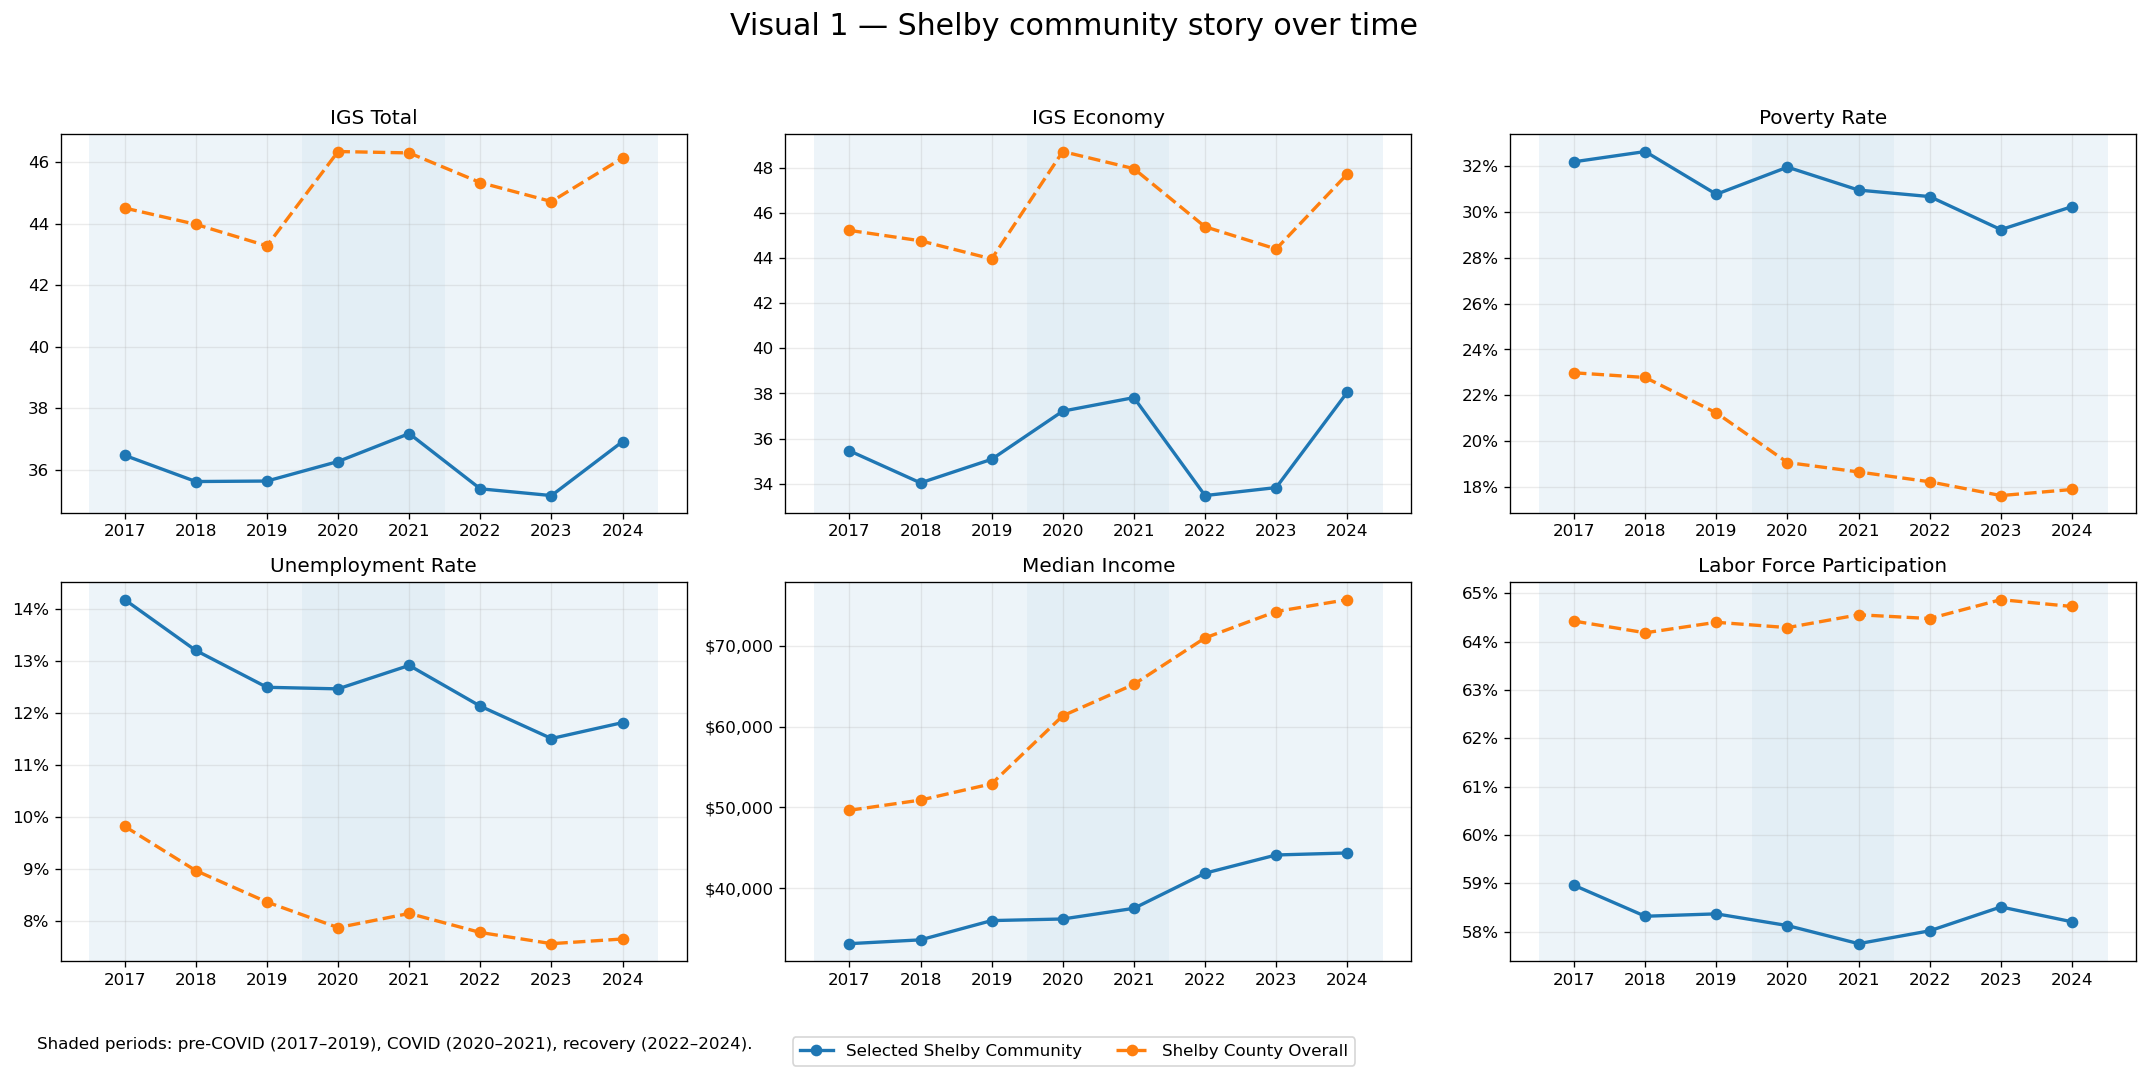

Saved: data\processed\presentation_ready\shelby_visual_1_story_over_time.png


In [209]:
# ============================================================
# VISUAL 1 — Shelby story over time
# Selected community vs Shelby County overall
# ============================================================

plot_metrics = [
    ("igs_total", "IGS Total"),
    ("igs_economy", "IGS Economy"),
    ("poverty_rate", "Poverty Rate"),
    ("unemp_rate", "Unemployment Rate"),
    ("median_household_income", "Median Income"),
    ("lfpr_16p", "Labor Force Participation"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

cluster_line = shelby_cluster_year.sort_values("year")
county_line = shelby_county_year.sort_values("year")

for ax, (col, title) in zip(axes, plot_metrics):
    ax.plot(cluster_line["year"], cluster_line[col], marker="o", linewidth=2, label="Selected Shelby Community")
    ax.plot(county_line["year"], county_line[col], marker="o", linewidth=2, linestyle="--", label="Shelby County Overall")

    # period shading
    ax.axvspan(2017 - 0.5, 2019 + 0.5, alpha=0.08)
    ax.axvspan(2020 - 0.5, 2021 + 0.5, alpha=0.12)
    ax.axvspan(2022 - 0.5, 2024 + 0.5, alpha=0.08)

    ax.set_title(title)
    ax.set_xticks(sorted(cluster_line["year"].unique()))
    ax.grid(alpha=0.25)

    if col in ["poverty_rate", "unemp_rate", "lfpr_16p"]:
        ax.ticklabel_format(style="plain", axis="y")
        vals = ax.get_yticks()
        ax.set_yticklabels([f"{v:.0%}" for v in vals])
    elif col == "median_household_income":
        vals = ax.get_yticks()
        ax.set_yticklabels([f"${v:,.0f}" for v in vals])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True)

fig.suptitle("Visual 1 — Shelby community story over time", fontsize=18, y=0.98)
fig.text(
    0.02, 0.02,
    "Shaded periods: pre-COVID (2017–2019), COVID (2020–2021), recovery (2022–2024).",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

fig.savefig(OUT_DIR / "shelby_visual_1_story_over_time.png", bbox_inches="tight")
print("Saved:", OUT_DIR / "shelby_visual_1_story_over_time.png")

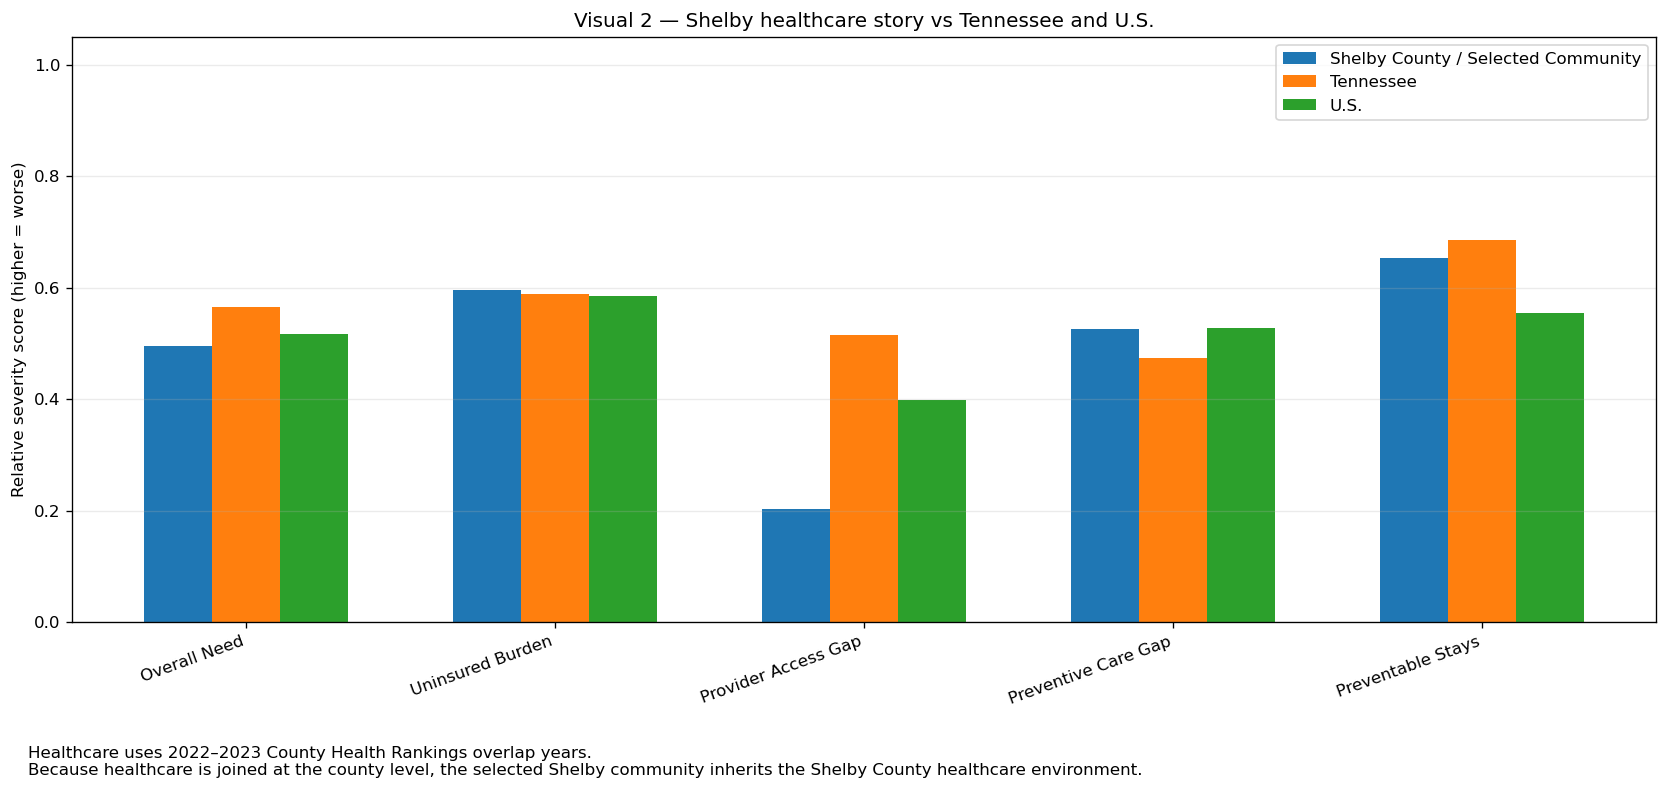

Saved: data\processed\presentation_ready\shelby_visual_2_health_story.png


In [210]:
# ============================================================
# VISUAL 2 — Shelby healthcare story
# NOTE: healthcare is county-level in this project, so the selected
# Shelby cluster inherits Shelby County's healthcare environment.
# ============================================================

health_plot = health_story_scores.set_index("group").loc[
    ["Shelby County / Selected Community", "Tennessee", "U.S."],
    ["Overall Need", "Uninsured Burden", "Provider Access Gap", "Preventive Care Gap", "Preventable Stays"]
]

x = np.arange(len(health_plot.columns))
bar_w = 0.22
groups = health_plot.index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

for i, g in enumerate(groups):
    ax.bar(x + (i - 1) * bar_w, health_plot.loc[g].values, width=bar_w, label=g)

ax.set_xticks(x)
ax.set_xticklabels(health_plot.columns, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Relative severity score (higher = worse)")
ax.set_title("Visual 2 — Shelby healthcare story vs Tennessee and U.S.")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True)

fig.text(
    0.02, 0.02,
    "Healthcare uses 2022–2023 County Health Rankings overlap years.\n"
    "Because healthcare is joined at the county level, the selected Shelby community inherits the Shelby County healthcare environment.",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

fig.savefig(OUT_DIR / "shelby_visual_2_health_story.png", bbox_inches="tight")
print("Saved:", OUT_DIR / "shelby_visual_2_health_story.png")

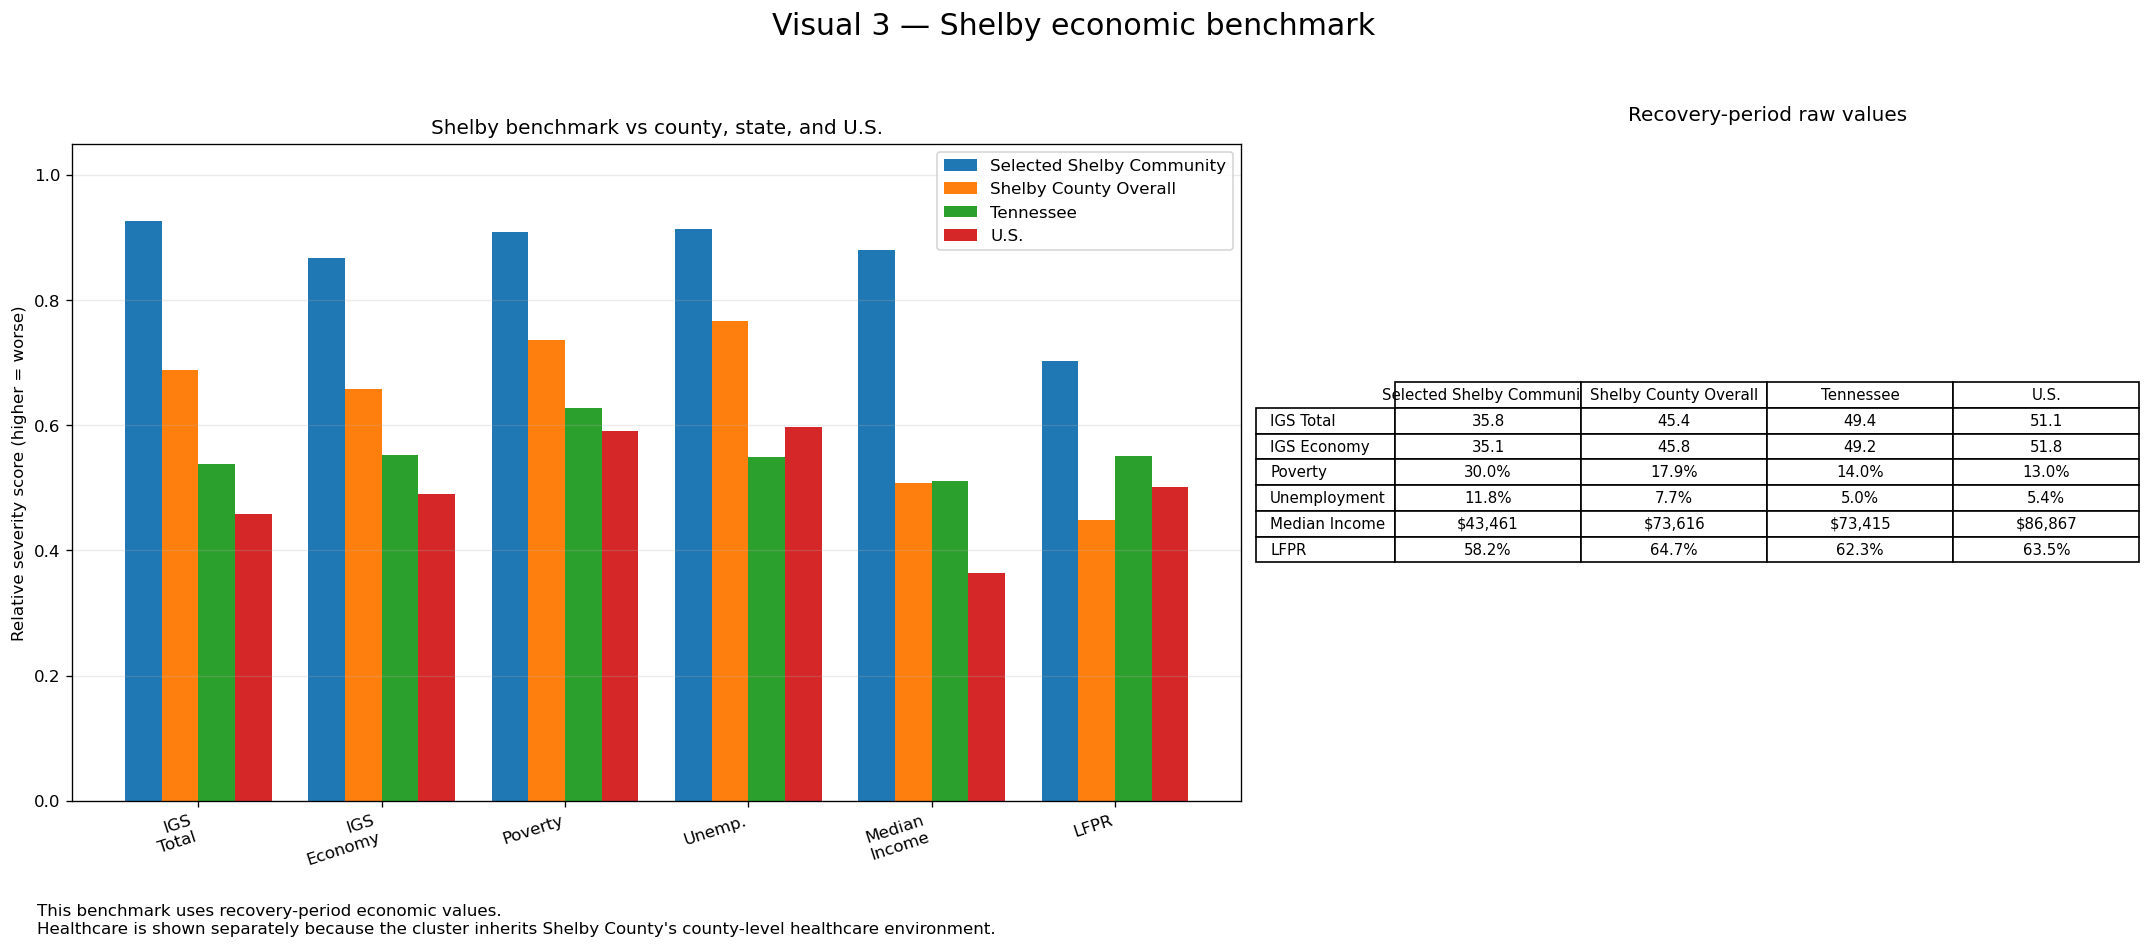

Saved: data\processed\presentation_ready\shelby_visual_3_benchmark.png


In [211]:
# ============================================================
# VISUAL 3 — Shelby benchmark
# Selected community vs Shelby County overall vs Tennessee vs U.S.
# ============================================================

benchmark_raw = econ_benchmark_raw.copy().set_index("group").T

def fmt_metric(metric, v):
    if pd.isna(v):
        return "NA"
    if metric in ["Poverty", "Unemployment", "LFPR"]:
        return f"{100*v:.1f}%"
    if metric == "Median Income":
        return f"${v:,.0f}"
    return f"{v:.1f}"

benchmark_fmt = benchmark_raw.copy()
for r in benchmark_fmt.index:
    for c in benchmark_fmt.columns:
        benchmark_fmt.loc[r, c] = fmt_metric(r, benchmark_fmt.loc[r, c])

# severity score view (higher = worse)
severity_df = pd.DataFrame(index=benchmark_raw.index)

for g in benchmark_raw.columns:
    raw = benchmark_raw[g]
    severity_df.loc["IGS Total", g] = percentile_of_value(
        analysis_panel_local.loc[analysis_panel_local["analysis_period"] == "recovery", "igs_total"],
        raw["IGS Total"],
        high_is_bad=False
    )
    severity_df.loc["IGS Economy", g] = percentile_of_value(
        analysis_panel_local.loc[analysis_panel_local["analysis_period"] == "recovery", "igs_economy"],
        raw["IGS Economy"],
        high_is_bad=False
    )
    severity_df.loc["Poverty", g] = percentile_of_value(
        analysis_panel_local.loc[analysis_panel_local["analysis_period"] == "recovery", "poverty_rate"],
        raw["Poverty"],
        high_is_bad=True
    )
    severity_df.loc["Unemployment", g] = percentile_of_value(
        analysis_panel_local.loc[analysis_panel_local["analysis_period"] == "recovery", "unemp_rate"],
        raw["Unemployment"],
        high_is_bad=True
    )
    severity_df.loc["Median Income", g] = percentile_of_value(
        analysis_panel_local.loc[analysis_panel_local["analysis_period"] == "recovery", "median_household_income"],
        raw["Median Income"],
        high_is_bad=False
    )
    severity_df.loc["LFPR", g] = percentile_of_value(
        analysis_panel_local.loc[analysis_panel_local["analysis_period"] == "recovery", "lfpr_16p"],
        raw["LFPR"],
        high_is_bad=False
    )

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(18, 8),
    gridspec_kw={"width_ratios": [1.65, 1.0]}
)

plot_df = severity_df.loc[
    ["IGS Total", "IGS Economy", "Poverty", "Unemployment", "Median Income", "LFPR"]
].copy()

plot_df = plot_df.rename(index={
    "IGS Total": "IGS\nTotal",
    "IGS Economy": "IGS\nEconomy",
    "Median Income": "Median\nIncome",
    "Unemployment": "Unemp.",
})

groups = plot_df.columns.tolist()
x = np.arange(len(plot_df.index))
bar_w = 0.20

for i, g in enumerate(groups):
    ax1.bar(x + (i - 1.5) * bar_w, plot_df[g].values, width=bar_w, label=g)

ax1.set_xticks(x)
ax1.set_xticklabels(plot_df.index, rotation=18, ha="right")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Relative severity score (higher = worse)")
ax1.set_title("Shelby benchmark vs county, state, and U.S.")
ax1.grid(axis="y", alpha=0.25)
ax1.legend(frameon=True)

ax2.axis("off")
tbl = ax2.table(
    cellText=benchmark_fmt.values,
    rowLabels=benchmark_fmt.index,
    colLabels=benchmark_fmt.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.05, 1.45)
ax2.set_title("Recovery-period raw values", pad=14)

fig.suptitle("Visual 3 — Shelby economic benchmark", fontsize=18, y=0.98)
fig.text(
    0.02, 0.02,
    "This benchmark uses recovery-period economic values.\n"
    "Healthcare is shown separately because the cluster inherits Shelby County's county-level healthcare environment.",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()

fig.savefig(OUT_DIR / "shelby_visual_3_benchmark.png", bbox_inches="tight")
print("Saved:", OUT_DIR / "shelby_visual_3_benchmark.png")